## Citi Bike NYC 2018

# Data Preparation

In [2]:
import os
import pandas as pd
from typing import Optional

pd.set_option('display.max_columns', None)

DATA_DIR = os.path.abspath('data')
RAW_TRIPS_PATH = os.path.join(DATA_DIR, 'Trips_2018.csv')
HOLIDAYS_PATH = os.path.join(DATA_DIR, 'holidays_2018_nyc.csv')
EVENTS_PATH = os.path.join(DATA_DIR, 'events_2018_nyc.csv')

RAW_TRIPS_PATH, HOLIDAYS_PATH, EVENTS_PATH


('/Users/kristian/Documents/GitHub/Analysis-of-NY-Citi-Bike-stations/data/Trips_2018.csv',
 '/Users/kristian/Documents/GitHub/Analysis-of-NY-Citi-Bike-stations/data/holidays_2018_nyc.csv',
 '/Users/kristian/Documents/GitHub/Analysis-of-NY-Citi-Bike-stations/data/events_2018_nyc.csv')

In [3]:
# Load holidays and events
holidays = pd.read_csv(HOLIDAYS_PATH, parse_dates=['date'])
# Normalize date to date only
holidays['date'] = holidays['date'].dt.normalize()

events = pd.read_csv(EVENTS_PATH, parse_dates=['start_datetime', 'end_datetime'])

print('Holidays:', holidays.shape)
print('Events:', events.shape)
holidays.head(2)


Holidays: (10, 5)
Events: (13, 6)


,name,date,region,category,notes
0,New Year's Day,2018-01-01,NYC,US Federal,NaN
1,Martin Luther King Jr. Day,2018-01-15,NYC,US Federal,NaN


In [4]:
events.head(2)

,name,start_datetime,end_datetime,borough,category,notes
0,St. Patrick's Day Parade,2018-03-17 11:00:00,2018-03-17 17:00:00,Manhattan,Parade,Fifth Ave corridor closures
1,TD Five Boro Bike Tour,2018-05-06 07:00:00,2018-05-06 17:00:00,Multiple,Sports,Citywide route impacts


### Load raw rides (chunked) and validate schema
We will stream the large CSV to avoid memory pressure. The loader:
- Infers likely Citi Bike column names and standardizes to a canonical schema
- Parses datetimes safely
- drops invalid rows and outliers
- Tracks basic QA metrics (missing rates, outlier rates)



In [5]:
CANONICAL_COLS = {
    "unnamed: 0": "id",
    "tripduration": "trip_duration_sec",
    "starttime": "start_time",
    "stoptime": "end_time",
    "start_station_id": "start_station_id",
    "start_station_latitude": "start_lat",
    "start_station_longitude": "start_lng",
    "end_station_id": "end_station_id",
    "end_station_latitude": "end_lat",
    "end_station_longitude": "end_lng",
    "bikeid": "bike_id",
    "usertype": "user_type",
    "birth_year": "birth_year",
    "gender": "gender",
}

CANONICAL_SET = set(CANONICAL_COLS.values())

DTYPES_BASE = {
    "trip_duration_sec": "float64",
    "start_station_id": "int",
    "end_station_id": "int",
    "bike_id": "string",
    "user_type": "string",
    "birth_year": "float64",
    "gender": "string",
    "start_lat": "float64",
    "start_lng": "float64",
    "end_lat": "float64",
    "end_lng": "float64",
}

CHUNKSIZE = 250_000


def _standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    mapping = {}
    for col in df.columns:
        low = col.strip().lower()
        mapping[col] = CANONICAL_COLS[low]

    df = df.rename(columns=mapping)
    return df


def _parse_times(df: pd.DataFrame) -> pd.DataFrame:
    df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce")
    df["end_time"] = pd.to_datetime(df["end_time"], errors="coerce")
    return df


def _compute_duration_if_missing(df: pd.DataFrame) -> pd.DataFrame:
    if "trip_duration_sec" not in df.columns:
        df["trip_duration_sec"] = (df["end_time"] - df["start_time"]).dt.total_seconds()
    return df


def _filter_invalid(df: pd.DataFrame) -> pd.DataFrame:
    # Drop invalid times
    if {"start_time", "end_time"}.issubset(df.columns):
        df = df[df["start_time"].notna() & df["end_time"].notna()]
        df = df[df["end_time"] >= df["start_time"]]
    # Duration sanity: 1 minute to 24 hours
    if "trip_duration_sec" in df.columns:
        df = df[
            (df["trip_duration_sec"] >= 60) & (df["trip_duration_sec"] <= 24 * 3600)
        ]
    return df


def _cast_types(df: pd.DataFrame) -> pd.DataFrame:
    for col, dtype in DTYPES_BASE.items():
        if col in df.columns:
            df[col] = df[col].astype(dtype, errors="ignore")
    return df


def _filter_geographic_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove trips with stations outside NYC geographic boundaries.

    This filters out erroneous GPS coordinates and stations in other cities
    (e.g., Montreal stations that appeared in the dataset).
    """
    # NYC bounding box (with small buffer for edge stations)
    NYC_LAT_MIN = 40.60
    NYC_LAT_MAX = 40.85
    NYC_LNG_MIN = -74.15
    NYC_LNG_MAX = -73.83

    initial_len = len(df)

    # Filter start station coordinates
    if {"start_lat", "start_lng"}.issubset(df.columns):
        df = df[
            (df["start_lat"] >= NYC_LAT_MIN)
            & (df["start_lat"] <= NYC_LAT_MAX)
            & (df["start_lng"] >= NYC_LNG_MIN)
            & (df["start_lng"] <= NYC_LNG_MAX)
        ]

    # Filter end station coordinates
    if {"end_lat", "end_lng"}.issubset(df.columns):
        df = df[
            (df["end_lat"] >= NYC_LAT_MIN)
            & (df["end_lat"] <= NYC_LAT_MAX)
            & (df["end_lng"] >= NYC_LNG_MIN)
            & (df["end_lng"] <= NYC_LNG_MAX)
        ]

    return df


def load_trips_stream(path: str, limit_chunks: Optional[int] = None) -> pd.DataFrame:
    qa_stats = []
    chunks = []
    for i, chunk in enumerate(pd.read_csv(path, chunksize=CHUNKSIZE, low_memory=True)):
        c0 = len(chunk)
        chunk = _standardize_columns(chunk)
        chunk = _parse_times(chunk)
        chunk = _compute_duration_if_missing(chunk)
        chunk = chunk.dropna()
        chunk = _filter_geographic_outliers(chunk)
        # keep only canonical columns if present
        cols_to_keep = [
            c
            for c in chunk.columns
            if c in CANONICAL_SET or c in {"start_time", "end_time"}
        ]
        chunk = chunk[cols_to_keep]
        chunk = _filter_invalid(chunk)
        chunk = _cast_types(chunk)
        c1 = len(chunk)
        qa_stats.append(
            {
                "chunk": i,
                "rows_dropped": c0 - c1,
                "drop_rate": (c0 - c1) / max(1, c0),
            }
        )
        chunks.append(chunk)
        if limit_chunks is not None and i + 1 >= limit_chunks:
            break
    trips = pd.concat(chunks, ignore_index=True)
    qa = pd.DataFrame(qa_stats)
    print("QA summary:")
    display(qa.describe(include="all"))
    print(f"Total dropped: {qa['rows_dropped'].sum()}")
    return trips


# Preview small sample for speed; set limit_chunks=None to process all
trips_sample = load_trips_stream(RAW_TRIPS_PATH, limit_chunks=None)
trips_sample.head()

QA summary:


,chunk,rows_dropped,drop_rate
count,71.000000,71.000000,71.000000
mean,35.000000,99.830986,0.000407
std,20.639767,85.367104,0.000341
min,0.000000,25.000000,0.000100
25%,17.500000,52.000000,0.000212
50%,35.000000,71.000000,0.000292
75%,52.500000,110.500000,0.000460
max,70.000000,517.000000,0.002068


Total dropped: 7088


,id,trip_duration_sec,start_time,end_time,start_station_id,start_lat,start_lng,end_station_id,end_lat,end_lng,bike_id,user_type,birth_year,gender
0,0,970.0,2018-01-01 13:50:57.434,2018-01-01 14:07:08.186,72,40.767272,-73.993929,505,40.749013,-73.988484,31956,Subscriber,1992.0,1
1,1,723.0,2018-01-01 15:33:30.182,2018-01-01 15:45:33.341,72,40.767272,-73.993929,3255,40.750585,-73.994685,32536,Subscriber,1969.0,1
2,2,496.0,2018-01-01 15:39:18.337,2018-01-01 15:47:35.172,72,40.767272,-73.993929,525,40.755942,-74.002116,16069,Subscriber,1956.0,1
3,3,306.0,2018-01-01 15:40:13.372,2018-01-01 15:45:20.191,72,40.767272,-73.993929,447,40.763707,-73.985162,31781,Subscriber,1974.0,1
4,4,306.0,2018-01-01 18:14:51.568,2018-01-01 18:19:57.642,72,40.767272,-73.993929,3356,40.774667,-73.984706,30319,Subscriber,1992.0,1


In [6]:
trips_sample.shape

(17541251, 14)

In [7]:
trips_sample.isnull().sum()

id                   0
trip_duration_sec    0
start_time           0
end_time             0
start_station_id     0
start_lat            0
start_lng            0
end_station_id       0
end_lat              0
end_lng              0
bike_id              0
user_type            0
birth_year           0
gender               0
dtype: int64

## Station data and activity metrics

Now that we have a clean trip dataset, we need to create a station-level view of the system. 

For each unique station, we will:
1. Extract station metadata: ID, latitude, longitude
2. Aggregate demand metrics:
   - Pickups: Number of trips that started at this station
   - Dropoffs: Number of trips that ended at this station
   - Total activity: Sum of pickups and dropoffs

This station-centric dataset will enable:
- Spatial clustering (grouping nearby stations)
- Demand pattern analysis (identifying high/low activity stations)

This aggregation transforms 17.5M trip records into 846 station profiles that will help in the futire for clustering and forecasting.

In [8]:
# Extract start station metadata
start_stations = trips_sample[['start_station_id', 'start_lat', 'start_lng']].copy()
start_stations.columns = ['station_id', 'lat', 'lng']

# Extract end station metadata
end_stations = trips_sample[['end_station_id', 'end_lat', 'end_lng']].copy()
end_stations.columns = ['station_id', 'lat', 'lng']

# Combine and remove duplicates
stations = pd.concat([start_stations, end_stations], ignore_index=True)
stations = stations.drop_duplicates(subset='station_id').reset_index(drop=True)

print(f"Total unique stations: {len(stations)}")
stations.head()

Total unique stations: 844


,station_id,lat,lng
0,72,40.767272,-73.993929
1,79,40.719116,-74.006667
2,82,40.711174,-74.000165
3,83,40.683826,-73.976323
4,119,40.696089,-73.978034


In [9]:
# Count how many trips start/end in each station
start_counts = trips_sample.groupby('start_station_id').size().rename('pickup_count')
end_counts = trips_sample.groupby('end_station_id').size().rename('dropoff_count')
display(start_counts.head())
display(end_counts.head())  

start_station_id
72     38403
79     27194
82     10217
83     13115
119     3235
Name: pickup_count, dtype: int64

end_station_id
72     38580
79     27557
82     10451
83     13813
119     3796
Name: dropoff_count, dtype: int64

In [10]:
# Merge with station metadata
stations = stations.merge(start_counts, left_on='station_id', right_index=True, how='left')
stations = stations.merge(end_counts, left_on='station_id', right_index=True, how='left')

# Fill NaN with 0 (stations without trips)
stations[['pickup_count', 'dropoff_count']] = stations[['pickup_count', 'dropoff_count']].fillna(0).astype(int)

# Calculate total activity
stations['total_trips'] = stations['pickup_count'] + stations['dropoff_count']

# Sort by activity
stations = stations.sort_values('total_trips', ascending=False).reset_index(drop=True)

print(f"Total unique stations: {len(stations)}")
stations.head(10)

Total unique stations: 844


,station_id,lat,lng,pickup_count,dropoff_count,total_trips
0,519,40.751873,-73.977706,150246,149925,300171
1,497,40.737050,-73.990093,108865,113323,222188
2,435,40.741740,-73.994156,107154,108634,215788
3,402,40.740343,-73.989551,105592,109143,214735
4,426,40.717548,-74.013221,94453,99422,193875
5,285,40.734546,-73.990741,93353,93579,186932
6,477,40.756405,-73.990026,87941,88136,176077
7,490,40.751551,-73.993934,85287,85276,170563
8,499,40.769155,-73.981918,84950,83358,168308
9,514,40.760875,-74.002777,82316,85136,167452


## Visualization (geographic distribution) of bike stations


Below is an interactive map showing all 846 Citi Bike stations in NYC. Each marker represents a station, with:
- **Color intensity**: Indicates total trip volume (darker = higher activity)
- **Popup info**: Station ID, coordinates, and trip counts (pickups/dropoffs)

This visualization helps identify:
- High-demand areas (Manhattan Midtown, Financial District)
- Geographic coverage and density patterns
- Potential clusters for spatial aggregation

In [11]:
# dependencies we will use
import folium
from folium.plugins import MarkerCluster
import numpy as np

In [12]:
# Create base map centered on NYC
nyc_center = [stations["lat"].mean(), stations["lng"].mean()]
m = folium.Map(location=nyc_center, zoom_start=12, tiles="CartoDB Positron")

NYC_LAT_MIN = 40.60
NYC_LAT_MAX = 40.85
NYC_LNG_MIN = -74.15
NYC_LNG_MAX = -73.83
# NYC bounding box
folium.Rectangle(
    bounds=[[NYC_LAT_MIN, NYC_LNG_MIN], [NYC_LAT_MAX, NYC_LNG_MAX]],
    color="blue",
    fill=False,
    weight=3,
    opacity=0.8,
    popup="NYC Bounding Box",
).add_to(m)

# Normalize total_trips for color scaling
min_trips = stations["total_trips"].min()
max_trips = stations["total_trips"].max()

# Add markers for each station
for idx, row in stations.iterrows():
    normalized = (row["total_trips"] - min_trips) / (max_trips - min_trips)

    if normalized > 0.7:
        color = "red"
    elif normalized > 0.4:
        color = "orange"
    elif normalized > 0.2:
        color = "yellow"
    else:
        color = "lightgreen"

    # Create popup with station info
    popup_html = f"""
    <div style="font-family: Arial; font-size: 12px;">
        <b>Station ID:</b> {row['station_id']}<br>
        <b>Location:</b> ({row['lat']:.4f}, {row['lng']:.4f})<br>
        <b>Pickups:</b> {row['pickup_count']:,}<br>
        <b>Dropoffs:</b> {row['dropoff_count']:,}<br>
        <b>Total Trips:</b> {row['total_trips']:,}
    </div>
    """

    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=5,
        popup=folium.Popup(popup_html, max_width=250),
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.8,
        weight=1,
    ).add_to(m)

# Add legend
legend_html = """
<div style="position: fixed; 
            bottom: 50px; right: 50px; width: 180px; height: 150px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:12px; padding: 10px">
<p><b>Station Activity</b></p>
<p><i class="fa fa-circle" style="color:red"></i> Very High (70%+)</p>
<p><i class="fa fa-circle" style="color:orange"></i> High (40-70%)</p>
<p><i class="fa fa-circle" style="color:yellow"></i> Medium (20-40%)</p>
<p><i class="fa fa-circle" style="color:lightgreen"></i> Low (<20%)</p>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
m

## Spatial Clustering Strategy

To reduce model complexity and capture local demand patterns, we will group nearby stations into geographic clusters.

### Clustering Approach: K-Means

We'll use **K-Means clustering** on station coordinates (lat/lng) to create 20-30 spatial clusters. This approach:

1. **Groups geographically proximate stations** → Reduces 846 stations to ~25 clusters
2. **Preserves local demand patterns** → Stations in the same neighborhood share similar characteristics
3. **Simplifies forecasting** → Predict demand at cluster level instead of individual stations
4. **Enables bike rebalancing** → Identify clusters with pickup/dropoff imbalances

### Cluster Selection Criteria:
- **Minimum 20 clusters** (per project requirements)
- **Balanced cluster sizes** → Avoid clusters with too few/many stations
- **Geographic coherence** → Clusters should represent meaningful neighborhoods

The map below shows a preview of how stations will be grouped into clusters based on their geographic proximity.

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Perform K-Means clustering
n_clusters = 30

# Prepare coordinates for clustering
coords = stations[["lat", "lng"]].values

# Fit K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
stations["cluster"] = kmeans.fit_predict(coords)

# Get cluster centers
cluster_centers = kmeans.cluster_centers_

print(f"Created {n_clusters} clusters")
print(f"Cluster size distribution:")
print(stations["cluster"].value_counts().describe())

# Aggregate metrics by cluster
cluster_stats = (
    stations.groupby("cluster")
    .agg(
        {
            "station_id": "count",
            "pickup_count": "sum",
            "dropoff_count": "sum",
            "total_trips": "sum",
            "lat": "mean",
            "lng": "mean",
        }
    )
    .rename(columns={"station_id": "num_stations"})
)

cluster_stats["balance"] = (
    cluster_stats["pickup_count"] - cluster_stats["dropoff_count"]
)
cluster_stats = cluster_stats.sort_values("total_trips", ascending=False)

print("\n📍 Top 5 clusters by activity:")
display(cluster_stats.head())

# Create clustered map
m_clustered = folium.Map(location=nyc_center, zoom_start=12, tiles="CartoDB positron")

# Define color palette for clusters
colors = plt.cm.tab20(np.linspace(0, 1, n_clusters))
color_map = {
    i: f"#{int(c[0]*255):02x}{int(c[1]*255):02x}{int(c[2]*255):02x}"
    for i, c in enumerate(colors)
}

for cluster_id in range(n_clusters):
    cluster_stations = stations[stations["cluster"] == cluster_id]

    # Add individual station markers
    for idx, row in cluster_stations.iterrows():
        popup_html = f"""
        <div style="font-family: Arial; font-size: 12px;">
            <b>Cluster:</b> {cluster_id}<br>
            <b>Station ID:</b> {row['station_id']}<br>
            <b>Total Trips:</b> {row['total_trips']:,}
        </div>
        """

        folium.CircleMarker(
            location=[row["lat"], row["lng"]],
            radius=4,
            popup=folium.Popup(popup_html, max_width=200),
            color=color_map[cluster_id],
            fill=True,
            fillColor=color_map[cluster_id],
            fillOpacity=0.6,
            weight=1,
        ).add_to(m_clustered)

    # Add cluster center marker
    center_lat, center_lng = cluster_centers[cluster_id]
    cluster_info = cluster_stats.loc[cluster_id]

    center_popup = f"""
    <div style="font-family: Arial; font-size: 13px;">
        <b>Cluster {cluster_id}</b><br>
        <b>Stations:</b> {cluster_info['num_stations']}<br>
        <b>Total Trips:</b> {cluster_info['total_trips']:,}<br>
        <b>Pickups:</b> {cluster_info['pickup_count']:,}<br>
        <b>Dropoffs:</b> {cluster_info['dropoff_count']:,}<br>
        <b>Balance:</b> {cluster_info['balance']:+,}
    </div>
    """

    folium.Marker(
        location=[center_lat, center_lng],
        popup=folium.Popup(center_popup, max_width=250),
        icon=folium.DivIcon(
            html=f"""
        <div style="
            font-size: 18px; 
            font-weight: 900; 
            color: {color_map[cluster_id]}; 
            background-color: white;
            border: 2px solid {color_map[cluster_id]};
            border-radius: 4px;
            width: 35px;
            height: 35px;
            display: flex;
            align-items: center;
            justify-content: center;
            box-shadow: 0 2px 6px rgba(0,0,0,0.3);
        ">
            {cluster_id}
        </div>
    """
        ),
        tooltip=center_popup,
    ).add_to(m_clustered)

# Add title
title_html = f"""
<div style="position: fixed; 
            top: 10px; left: 50px; width: 400px; height: 50px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:16px; padding: 10px">
<b>Citi Bike Stations - K-Means Clustering (k={n_clusters})</b>
</div>
"""
m_clustered.get_root().html.add_child(folium.Element(title_html))

# Display clustered map
m_clustered

Created 30 clusters
Cluster size distribution:
count    30.000000
mean     28.133333
std       6.361161
min       6.000000
25%      25.250000
50%      30.000000
75%      31.750000
max      43.000000
Name: count, dtype: float64

📍 Top 5 clusters by activity:


,num_stations,pickup_count,dropoff_count,total_trips,lat,lng,balance
cluster,,,,,,,
2,32,1623149,1651551,3274700,40.730338,-73.997884,-28402
26,30,1520425,1529836,3050261,40.744585,-73.983957,-9411
11,35,1500553,1503065,3003618,40.759668,-73.990634,-2512
29,33,1433993,1459733,2893726,40.742937,-74.001926,-25740
4,35,1367293,1363978,2731271,40.756535,-73.972630,3315


In [19]:
stations

stations.to_csv("cluster_data")



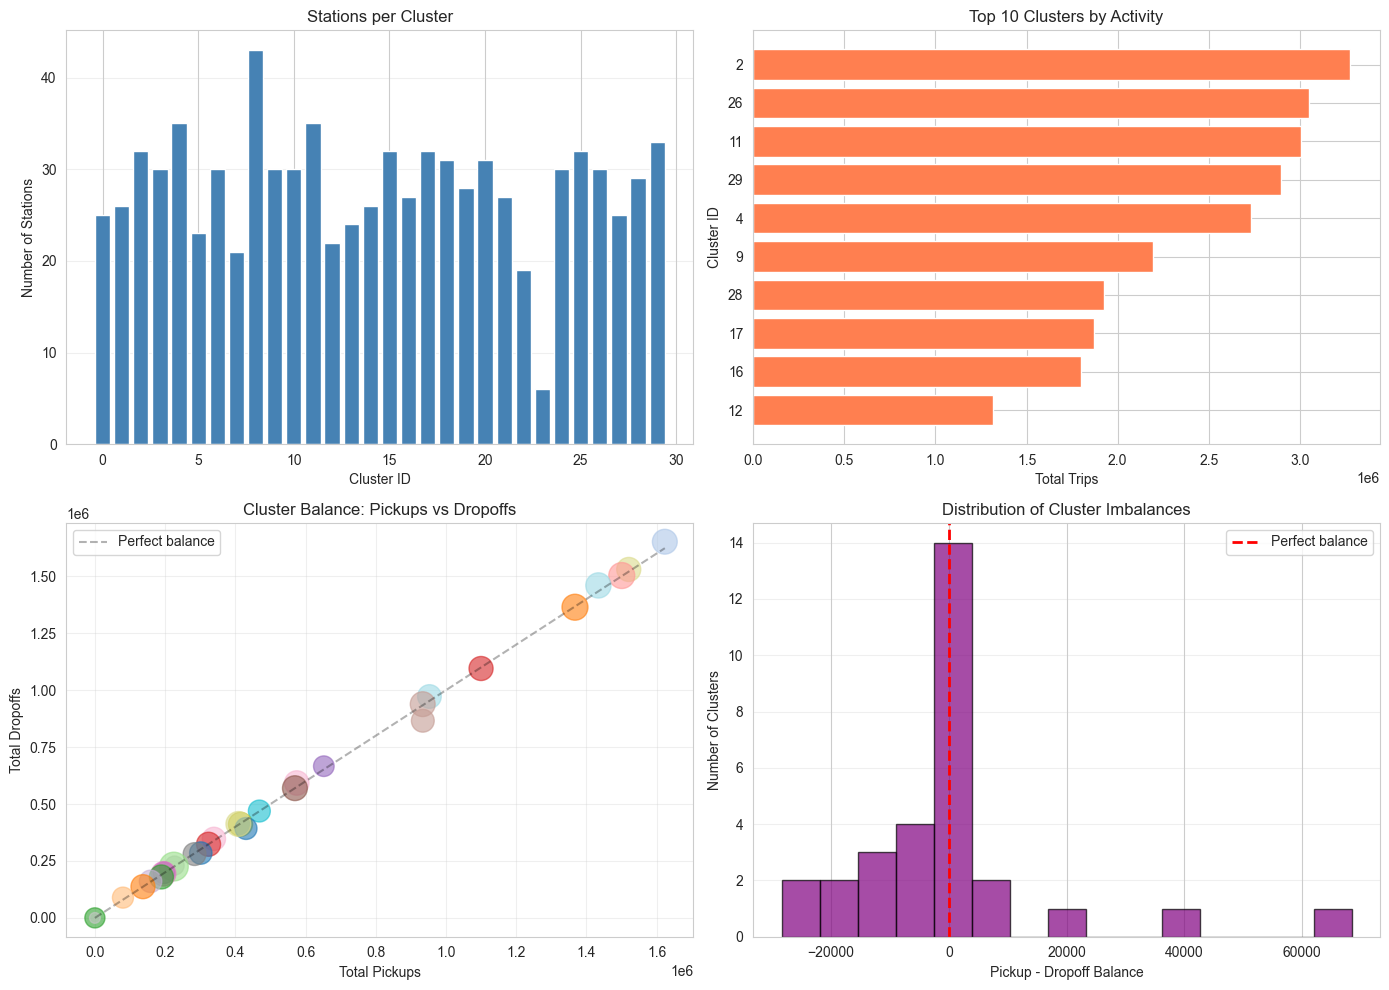

Clustering Summary:
   • Total clusters: 30
   • Avg stations per cluster: 28.1
   • Most balanced cluster: 23 (balance: +25)
   • Most imbalanced cluster: 16 (balance: +68,370)


In [70]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Cluster size distribution
axes[0, 0].bar(cluster_stats.index, cluster_stats["num_stations"], color="steelblue")
axes[0, 0].set_xlabel("Cluster ID")
axes[0, 0].set_ylabel("Number of Stations")
axes[0, 0].set_title("Stations per Cluster")
axes[0, 0].grid(axis="y", alpha=0.3)

# 2. Total trips per cluster
top_10 = cluster_stats.nlargest(10, "total_trips")
axes[0, 1].barh(top_10.index.astype(str), top_10["total_trips"], color="coral")
axes[0, 1].set_xlabel("Total Trips")
axes[0, 1].set_ylabel("Cluster ID")
axes[0, 1].set_title("Top 10 Clusters by Activity")
axes[0, 1].invert_yaxis()

# 3. Pickup vs Dropoff balance
axes[1, 0].scatter(
    cluster_stats["pickup_count"],
    cluster_stats["dropoff_count"],
    s=cluster_stats["num_stations"] * 10,
    alpha=0.6,
    c=cluster_stats.index,
    cmap="tab20",
)
axes[1, 0].plot(
    [0, cluster_stats["pickup_count"].max()],
    [0, cluster_stats["pickup_count"].max()],
    "k--",
    alpha=0.3,
    label="Perfect balance",
)
axes[1, 0].set_xlabel("Total Pickups")
axes[1, 0].set_ylabel("Total Dropoffs")
axes[1, 0].set_title("Cluster Balance: Pickups vs Dropoffs")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Imbalance distribution
axes[1, 1].hist(
    cluster_stats["balance"], bins=15, color="purple", alpha=0.7, edgecolor="black"
)
axes[1, 1].axvline(0, color="red", linestyle="--", linewidth=2, label="Perfect balance")
axes[1, 1].set_xlabel("Pickup - Dropoff Balance")
axes[1, 1].set_ylabel("Number of Clusters")
axes[1, 1].set_title("Distribution of Cluster Imbalances")
axes[1, 1].legend()
axes[1, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Clustering Summary:")
print(f"   • Total clusters: {n_clusters}")
print(f"   • Avg stations per cluster: {cluster_stats['num_stations'].mean():.1f}")
print(
    f"   • Most balanced cluster: {cluster_stats['balance'].abs().idxmin()} (balance: {cluster_stats['balance'].abs().min():+,.0f})"
)
print(
    f"   • Most imbalanced cluster: {cluster_stats['balance'].abs().idxmax()} (balance: {cluster_stats.loc[cluster_stats['balance'].abs().idxmax(), 'balance']:+,.0f})"
)

# Feature Engineering

In [71]:
stations.head()

,station_id,lat,lng,pickup_count,dropoff_count,total_trips,cluster
0,519,40.751873,-73.977706,150246,149925,300171,4
1,497,40.737050,-73.990093,108865,113323,222188,26
2,435,40.741740,-73.994156,107154,108634,215788,29
3,402,40.740343,-73.989551,105592,109143,214735,26
4,426,40.717548,-74.013221,94453,99422,193875,28


In [72]:
trips_sample.head()

,id,trip_duration_sec,start_time,end_time,start_station_id,start_lat,start_lng,end_station_id,end_lat,end_lng,bike_id,user_type,birth_year,gender
0,0,970.0,2018-01-01 13:50:57.434,2018-01-01 14:07:08.186,72,40.767272,-73.993929,505,40.749013,-73.988484,31956,Subscriber,1992.0,1
1,1,723.0,2018-01-01 15:33:30.182,2018-01-01 15:45:33.341,72,40.767272,-73.993929,3255,40.750585,-73.994685,32536,Subscriber,1969.0,1
2,2,496.0,2018-01-01 15:39:18.337,2018-01-01 15:47:35.172,72,40.767272,-73.993929,525,40.755942,-74.002116,16069,Subscriber,1956.0,1
3,3,306.0,2018-01-01 15:40:13.372,2018-01-01 15:45:20.191,72,40.767272,-73.993929,447,40.763707,-73.985162,31781,Subscriber,1974.0,1
4,4,306.0,2018-01-01 18:14:51.568,2018-01-01 18:19:57.642,72,40.767272,-73.993929,3356,40.774667,-73.984706,30319,Subscriber,1992.0,1


In [73]:
trips_sample.groupby('user_type').size()

user_type
Customer       1929616
Subscriber    15611635
dtype: int64

## Feature Engineering for Demand Forecasting

Now that we have clean trip data and station clusters, we need to transform this into a **time-series forecasting dataset**.

### Goal
Create a dataset where each row represents:
- **One cluster** at **one specific hour**
- Target variables: `pickups` and `dropoffs` (number of trips)
- Features: temporal patterns, cluster characteristics, historical demand

### Transformation Steps
1. **Aggregate trips to cluster-hour level** (from 17M trips → ~500K cluster-hours)
2. **Engineer temporal features** (month, day of week, season, holidays)
3. **Add cluster-level features** (average demand, station count, location)
4. **Create lag features** (previous day/week demand for time-series context)
5. **Normalize continuous variables** (standardization for model training)

This structure enables us to predict the next 24 hours of demand for each cluster.

In [74]:
# ============================================================================
# STEP 1: Aggregate Trips to Cluster-Hour Level
# ============================================================================

print("Aggregating trips to cluster-hour level...")

# Add temporal columns to trips
trips_sample['start_hour'] = trips_sample['start_time'].dt.hour
trips_sample['start_date'] = trips_sample['start_time'].dt.date
trips_sample['end_hour'] = trips_sample['end_time'].dt.hour
trips_sample['end_date'] = trips_sample['end_time'].dt.date

# Merge trips with station clusters (for pickups)
trips_with_start_cluster = trips_sample.merge(
    stations[['station_id', 'cluster']], 
    left_on='start_station_id', 
    right_on='station_id',
    how='left'
).drop(columns=['station_id'])

# Merge trips with station clusters (for dropoffs)
trips_with_end_cluster = trips_sample.merge(
    stations[['station_id', 'cluster']], 
    left_on='end_station_id', 
    right_on='station_id',
    how='left',
    suffixes=('', '_end')
).drop(columns=['station_id'])

# Aggregate pickups by cluster-date-hour
pickups_hourly = trips_with_start_cluster.groupby(
    ['start_date', 'start_hour', 'cluster']
).agg({
    'id': 'count',  # Number of pickups
    'trip_duration_sec': 'mean',  # Average trip duration
    'birth_year': 'mean',  # Average birth year (for age calculation)
    'user_type': lambda x: (x == 'Subscriber').sum() / len(x)  # % subscribers
}).reset_index()

pickups_hourly.columns = ['date', 'hour', 'cluster', 'pickups', 'avg_trip_duration', 'avg_birth_year', 'pct_subscribers']

# Aggregate dropoffs by cluster-date-hour
dropoffs_hourly = trips_with_end_cluster.groupby(
    ['end_date', 'end_hour', 'cluster']
).size().reset_index(name='dropoffs')
dropoffs_hourly.columns = ['date', 'hour', 'cluster', 'dropoffs']

# Merge pickups and dropoffs
demand_hourly = pickups_hourly.merge(
    dropoffs_hourly, 
    on=['date', 'hour', 'cluster'], 
    how='outer'
).fillna(0)

# Calculate age from birth year
current_year = 2018
demand_hourly['avg_age'] = current_year - demand_hourly['avg_birth_year']
demand_hourly = demand_hourly.drop(columns=['avg_birth_year'])

print(f"Created {len(demand_hourly):,} cluster-hour observations")
print(f"Date range: {demand_hourly['date'].min()} to {demand_hourly['date'].max()}")
print(f"Clusters: {demand_hourly['cluster'].nunique()}")

demand_hourly.head(10)

Aggregating trips to cluster-hour level...
Created 238,660 cluster-hour observations
Date range: 2018-01-01 to 2019-01-01
Clusters: 30


,date,hour,cluster,pickups,avg_trip_duration,pct_subscribers,dropoffs,avg_age
0,2018-01-01,0,0,3.0,1056.666667,1.000000,2.0,46.000000
1,2018-01-01,0,1,1.0,242.000000,1.000000,2.0,51.000000
2,2018-01-01,0,2,15.0,849.066667,1.000000,4.0,44.266667
3,2018-01-01,0,4,2.0,916.500000,1.000000,3.0,43.000000
4,2018-01-01,0,6,0.0,0.000000,0.000000,1.0,2018.000000
5,2018-01-01,0,8,2.0,704.000000,1.000000,2.0,37.500000
6,2018-01-01,0,9,11.0,565.363636,1.000000,13.0,38.272727
7,2018-01-01,0,10,3.0,916.000000,1.000000,4.0,32.333333
8,2018-01-01,0,11,13.0,885.384615,0.538462,4.0,38.846154
9,2018-01-01,0,12,5.0,384.200000,1.000000,3.0,27.600000


In [75]:
# ============================================================================
# STEP 2: Engineer Temporal Features
# ============================================================================

print("Creating temporal features...")

# Convert date to datetime for feature extraction
demand_hourly['date'] = pd.to_datetime(demand_hourly['date'])

# Basic temporal features
demand_hourly['month'] = demand_hourly['date'].dt.month
demand_hourly['day_of_week'] = demand_hourly['date'].dt.dayofweek  # 0=Monday, 6=Sunday
demand_hourly['day_of_month'] = demand_hourly['date'].dt.day
demand_hourly['week_of_year'] = demand_hourly['date'].dt.isocalendar().week

# Weekend indicator
demand_hourly['is_weekend'] = (demand_hourly['day_of_week'] >= 5).astype(int)

# Season dummies (Northern Hemisphere)
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:  # 9, 10, 11
        return 'fall'

demand_hourly['season'] = demand_hourly['month'].apply(get_season)

# Create season dummies
season_dummies = pd.get_dummies(demand_hourly['season'], prefix='season')
demand_hourly = pd.concat([demand_hourly, season_dummies], axis=1)

print("Temporal features created:")
print(f"  - Month, day_of_week, day_of_month, week_of_year")
print(f"  - is_weekend")
print(f"  - Season dummies: {list(season_dummies.columns)}")

demand_hourly.head()

Creating temporal features...
Temporal features created:
  - Month, day_of_week, day_of_month, week_of_year
  - is_weekend
  - Season dummies: ['season_fall', 'season_spring', 'season_summer', 'season_winter']


,date,hour,cluster,pickups,avg_trip_duration,pct_subscribers,dropoffs,avg_age,month,day_of_week,day_of_month,week_of_year,is_weekend,season,season_fall,season_spring,season_summer,season_winter
0,2018-01-01,0,0,3.0,1056.666667,1.0,2.0,46.000000,1,0,1,1,0,winter,False,False,False,True
1,2018-01-01,0,1,1.0,242.000000,1.0,2.0,51.000000,1,0,1,1,0,winter,False,False,False,True
2,2018-01-01,0,2,15.0,849.066667,1.0,4.0,44.266667,1,0,1,1,0,winter,False,False,False,True
3,2018-01-01,0,4,2.0,916.500000,1.0,3.0,43.000000,1,0,1,1,0,winter,False,False,False,True
4,2018-01-01,0,6,0.0,0.000000,0.0,1.0,2018.000000,1,0,1,1,0,winter,False,False,False,True


In [76]:
# ============================================================================
# STEP 3: Add Holiday and Event Indicators
# ============================================================================

print("Merging holiday and event data...")

# Normalize holiday dates
holidays['date'] = pd.to_datetime(holidays['date']).dt.normalize()
demand_hourly['date_normalized'] = demand_hourly['date'].dt.normalize()

# Merge holidays
demand_hourly = demand_hourly.merge(
    holidays[['date']].assign(is_holiday=1),
    left_on='date_normalized',
    right_on='date',
    how='left',
    suffixes=('', '_holiday')
).drop(columns=['date_holiday'])

demand_hourly['is_holiday'] = demand_hourly['is_holiday'].fillna(0).astype(int)

# For events, check if the cluster-hour falls within any event time window
# (This is more complex - simplified version: mark days with events)
event_dates = pd.to_datetime(events['start_datetime']).dt.date.unique()
demand_hourly['is_special_event'] = demand_hourly['date_normalized'].dt.date.isin(event_dates).astype(int)

demand_hourly = demand_hourly.drop(columns=['date_normalized'])

print(f"Holidays marked: {demand_hourly['is_holiday'].sum()} cluster-hours")
print(f"Special events marked: {demand_hourly['is_special_event'].sum()} cluster-hours")

demand_hourly.head()

Merging holiday and event data...
Holidays marked: 6498 cluster-hours
Special events marked: 8606 cluster-hours


,date,hour,cluster,pickups,avg_trip_duration,pct_subscribers,dropoffs,avg_age,month,day_of_week,day_of_month,week_of_year,is_weekend,season,season_fall,season_spring,season_summer,season_winter,is_holiday,is_special_event
0,2018-01-01,0,0,3.0,1056.666667,1.0,2.0,46.000000,1,0,1,1,0,winter,False,False,False,True,1,0
1,2018-01-01,0,1,1.0,242.000000,1.0,2.0,51.000000,1,0,1,1,0,winter,False,False,False,True,1,0
2,2018-01-01,0,2,15.0,849.066667,1.0,4.0,44.266667,1,0,1,1,0,winter,False,False,False,True,1,0
3,2018-01-01,0,4,2.0,916.500000,1.0,3.0,43.000000,1,0,1,1,0,winter,False,False,False,True,1,0
4,2018-01-01,0,6,0.0,0.000000,0.0,1.0,2018.000000,1,0,1,1,0,winter,False,False,False,True,1,0


In [77]:
# ============================================================================
# STEP 4: Add Cluster-Level Features
# ============================================================================

print("Creating cluster-level features...")

# Calculate cluster statistics from stations
cluster_stats = stations.groupby('cluster').agg({
    'station_id': 'count',  # Number of stations in cluster
    'lat': 'mean',  # Cluster center latitude
    'lng': 'mean',  # Cluster center longitude
    'total_trips': 'sum'  # Total historical trips in cluster
}).reset_index()

cluster_stats.columns = ['cluster', 'cluster_station_count', 'cluster_center_lat', 'cluster_center_lng', 'cluster_total_trips']

# Merge with demand data
demand_hourly = demand_hourly.merge(cluster_stats, on='cluster', how='left')

print("Cluster features added:")
print(f"  - cluster_station_count (stations per cluster)")
print(f"  - cluster_center_lat, cluster_center_lng")
print(f"  - cluster_total_trips (historical total)")

demand_hourly.head()

Creating cluster-level features...
Cluster features added:
  - cluster_station_count (stations per cluster)
  - cluster_center_lat, cluster_center_lng
  - cluster_total_trips (historical total)


,date,hour,cluster,pickups,avg_trip_duration,pct_subscribers,dropoffs,avg_age,month,day_of_week,day_of_month,week_of_year,is_weekend,season,season_fall,season_spring,season_summer,season_winter,is_holiday,is_special_event,cluster_station_count,cluster_center_lat,cluster_center_lng,cluster_total_trips
0,2018-01-01,0,0,3.0,1056.666667,1.0,2.0,46.000000,1,0,1,1,0,winter,False,False,False,True,1,0,25,40.795363,-73.968390,823044
1,2018-01-01,0,1,1.0,242.000000,1.0,2.0,51.000000,1,0,1,1,0,winter,False,False,False,True,1,0,26,40.692598,-73.968936,586301
2,2018-01-01,0,2,15.0,849.066667,1.0,4.0,44.266667,1,0,1,1,0,winter,False,False,False,True,1,0,32,40.730338,-73.997884,3274700
3,2018-01-01,0,4,2.0,916.500000,1.0,3.0,43.000000,1,0,1,1,0,winter,False,False,False,True,1,0,35,40.756535,-73.972630,2731271
4,2018-01-01,0,6,0.0,0.000000,0.0,1.0,2018.000000,1,0,1,1,0,winter,False,False,False,True,1,0,30,40.672609,-73.959158,369111


In [78]:
# ============================================================================
# STEP 5: Create Lag Features (Time Series Context)
# ============================================================================

print("Creating lag features for time-series forecasting...")

# Sort by cluster and datetime
demand_hourly = demand_hourly.sort_values(['cluster', 'date', 'hour']).reset_index(drop=True)

# Create lags for pickups and dropoffs
for target in ['pickups', 'dropoffs']:
    # Previous day same hour (24 hours ago)
    demand_hourly[f'{target}_lag_24h'] = demand_hourly.groupby('cluster')[target].shift(24)
    
    # Previous week same hour (168 hours ago)
    demand_hourly[f'{target}_lag_168h'] = demand_hourly.groupby('cluster')[target].shift(168)
    
    # Rolling average last 24 hours
    demand_hourly[f'{target}_rolling_24h'] = demand_hourly.groupby('cluster')[target].transform(
        lambda x: x.rolling(window=24, min_periods=1).mean()
    )

print("Lag features created:")
print(f"  - pickups/dropoffs_lag_24h (yesterday same hour)")
print(f"  - pickups/dropoffs_lag_168h (last week same hour)")
print(f"  - pickups/dropoffs_rolling_24h (24-hour moving average)")

# Check for NaN values in lag features (expected for first observations)
print(f"\nNaN values in lag features (first {24*7} hours per cluster):")
print(demand_hourly[['pickups_lag_24h', 'pickups_lag_168h']].isnull().sum())

demand_hourly.head(30)

Creating lag features for time-series forecasting...
Lag features created:
  - pickups/dropoffs_lag_24h (yesterday same hour)
  - pickups/dropoffs_lag_168h (last week same hour)
  - pickups/dropoffs_rolling_24h (24-hour moving average)

NaN values in lag features (first 168 hours per cluster):
pickups_lag_24h      718
pickups_lag_168h    4824
dtype: int64


,date,hour,cluster,pickups,avg_trip_duration,pct_subscribers,dropoffs,avg_age,month,day_of_week,day_of_month,week_of_year,is_weekend,season,season_fall,season_spring,season_summer,season_winter,is_holiday,is_special_event,cluster_station_count,cluster_center_lat,cluster_center_lng,cluster_total_trips,pickups_lag_24h,pickups_lag_168h,pickups_rolling_24h,dropoffs_lag_24h,dropoffs_lag_168h,dropoffs_rolling_24h
0,2018-01-01,0,0,3.0,1056.666667,1.000000,2.0,46.000000,1,0,1,1,0,winter,False,False,False,True,1,0,25,40.795363,-73.96839,823044,NaN,NaN,3.000000,NaN,NaN,2.000000
1,2018-01-01,1,0,1.0,226.000000,1.000000,5.0,53.000000,1,0,1,1,0,winter,False,False,False,True,1,0,25,40.795363,-73.96839,823044,NaN,NaN,2.000000,NaN,NaN,3.500000
2,2018-01-01,2,0,4.0,630.500000,1.000000,1.0,33.000000,1,0,1,1,0,winter,False,False,False,True,1,0,25,40.795363,-73.96839,823044,NaN,NaN,2.666667,NaN,NaN,2.666667
3,2018-01-01,3,0,0.0,0.000000,0.000000,1.0,2018.000000,1,0,1,1,0,winter,False,False,False,True,1,0,25,40.795363,-73.96839,823044,NaN,NaN,2.000000,NaN,NaN,2.250000
4,2018-01-01,5,0,1.0,1319.000000,1.000000,0.0,37.000000,1,0,1,1,0,winter,False,False,False,True,1,0,25,40.795363,-73.96839,823044,NaN,NaN,1.800000,NaN,NaN,1.800000
5,2018-01-01,7,0,2.0,545.500000,1.000000,0.0,51.000000,1,0,1,1,0,winter,False,False,False,True,1,0,25,40.795363,-73.96839,823044,NaN,NaN,1.833333,NaN,NaN,1.500000
6,2018-01-01,8,0,6.0,754.333333,1.000000,0.0,40.500000,1,0,1,1,0,winter,False,False,False,True,1,0,25,40.795363,-73.96839,823044,NaN,NaN,2.428571,NaN,NaN,1.285714
7,2018-01-01,9,0,8.0,823.750000,1.000000,11.0,40.000000,1,0,1,1,0,winter,False,False,False,True,1,0,25,40.795363,-73.96839,823044,NaN,NaN,3.125000,NaN,NaN,2.500000
8,2018-01-01,10,0,8.0,520.875000,1.000000,9.0,38.500000,1,0,1,1,0,winter,False,False,False,True,1,0,25,40.795363,-73.96839,823044,NaN,NaN,3.666667,NaN,NaN,3.222222
9,2018-01-01,11,0,8.0,575.000000,1.000000,6.0,44.875000,1,0,1,1,0,winter,False,False,False,True,1,0,25,40.795363,-73.96839,823044,NaN,NaN,4.100000,NaN,NaN,3.500000


## Time Series Visualization: Understanding Demand Patterns

Before normalizing and training models, let's visualize the temporal patterns in our data. We'll focus on a high-activity cluster to see clear patterns.

These visualizations will help us:
1. **Identify trends and seasonality** (daily, weekly, monthly patterns)
2. **Validate feature engineering** (do holidays/weekends affect demand?)
3. **Detect anomalies** (unexpected spikes or drops)
4. **Understand cluster behavior** (rush hours, weekend patterns)

In [79]:
# ============================================================================
# Setup for Visualizations
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 6)

# Select a high-activity cluster for visualization
top_cluster = demand_hourly.groupby('cluster')['pickups'].sum().idxmax()
print(f"Selected cluster {top_cluster} (highest total pickups) for visualization")

# Filter data for this cluster
cluster_data = demand_hourly[demand_hourly['cluster'] == top_cluster].copy()
cluster_data['datetime'] = pd.to_datetime(cluster_data['date']) + pd.to_timedelta(cluster_data['hour'], unit='h')
cluster_data = cluster_data.sort_values('datetime')

print(f"Cluster {top_cluster} has {len(cluster_data):,} hourly observations")
print(f"Date range: {cluster_data['datetime'].min()} to {cluster_data['datetime'].max()}")

Selected cluster 2 (highest total pickups) for visualization
Cluster 2 has 8,737 hourly observations
Date range: 2018-01-01 00:00:00 to 2019-01-01 13:00:00


### 1. Full Year Time Series: Pickups Over Time
This chart shows the complete demand pattern for the busiest cluster throughout 2018.

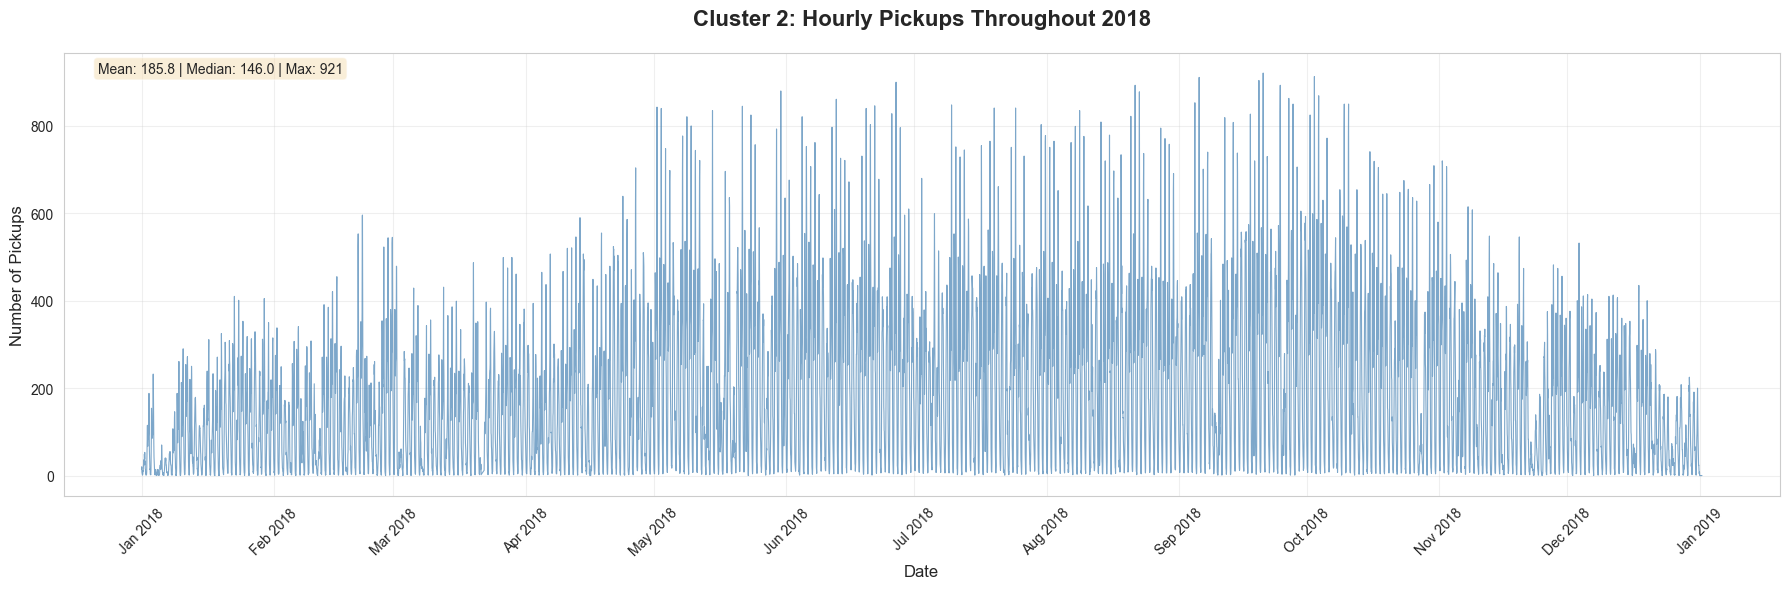

📊 Observation: Notice any seasonal trends? Summer vs Winter patterns?


In [80]:
# ============================================================================
# Visualization 1: Full Year Pickups Time Series
# ============================================================================

fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(cluster_data['datetime'], cluster_data['pickups'], 
        linewidth=0.8, alpha=0.7, color='steelblue')

ax.set_title(f'Cluster {top_cluster}: Hourly Pickups Throughout 2018', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Pickups', fontsize=12)

# Format x-axis to show months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

# Add grid
ax.grid(True, alpha=0.3)

# Add statistics text box
stats_text = f"Mean: {cluster_data['pickups'].mean():.1f} | Median: {cluster_data['pickups'].median():.1f} | Max: {cluster_data['pickups'].max():.0f}"
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"📊 Observation: Notice any seasonal trends? Summer vs Winter patterns?")

### 2. Time Series with Weekend Highlighting
This visualization highlights weekends to see if demand patterns differ on Saturdays and Sundays.

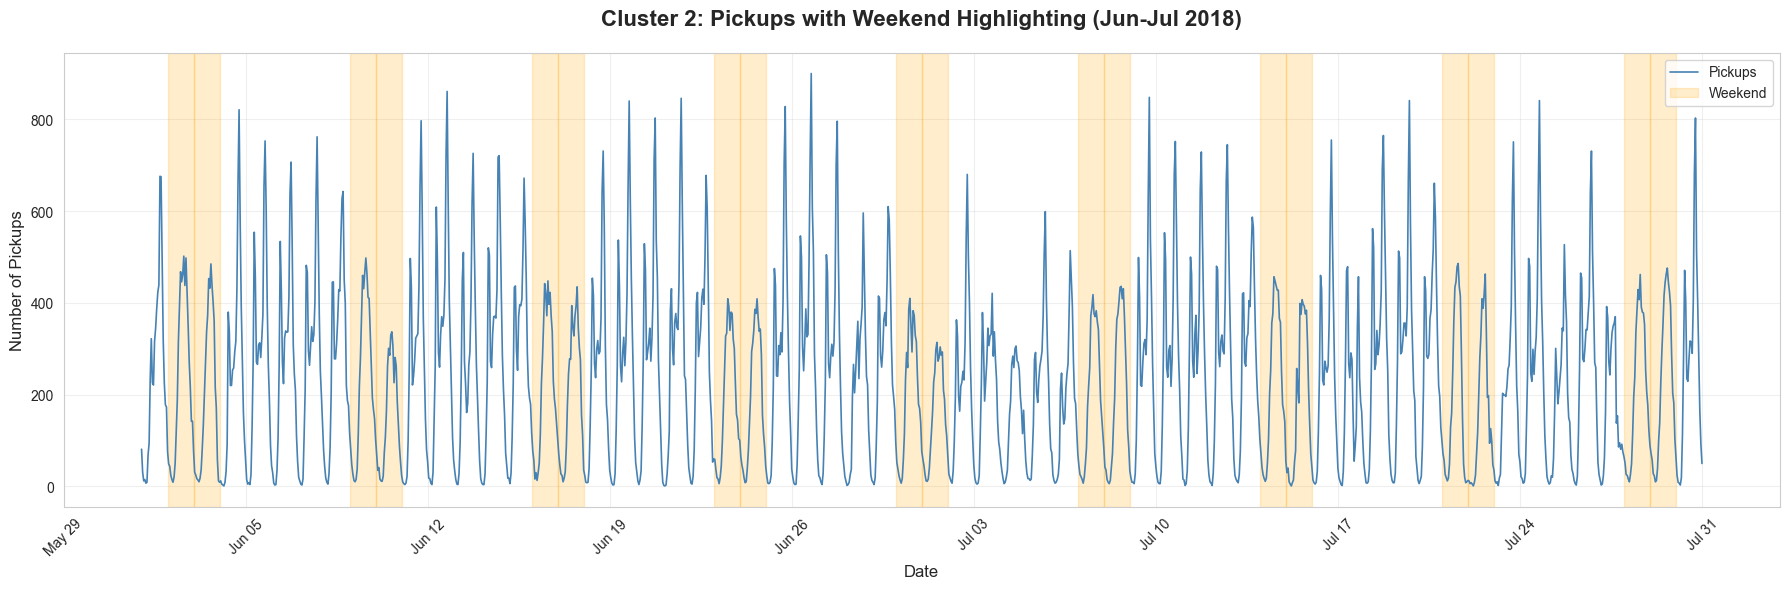

📊 Observation: Do weekends show different patterns? Higher or lower demand?


In [81]:
# ============================================================================
# Visualization 2: Pickups with Weekend Highlighting
# ============================================================================

# Focus on a 2-month period for clarity
sample_start = '2018-06-01'
sample_end = '2018-07-31'
cluster_sample = cluster_data[(cluster_data['datetime'] >= sample_start) & 
                               (cluster_data['datetime'] <= sample_end)]

fig, ax = plt.subplots(figsize=(18, 6))

# Plot the time series
ax.plot(cluster_sample['datetime'], cluster_sample['pickups'], 
        linewidth=1.2, color='steelblue', label='Pickups')

# Highlight weekends
weekend_dates = cluster_sample[cluster_sample['is_weekend'] == 1]['datetime'].dt.date.unique()
for weekend_date in weekend_dates:
    weekend_start = pd.to_datetime(weekend_date)
    weekend_end = weekend_start + pd.Timedelta(days=1)
    ax.axvspan(weekend_start, weekend_end, alpha=0.2, color='orange', label='Weekend' if weekend_date == weekend_dates[0] else '')

ax.set_title(f'Cluster {top_cluster}: Pickups with Weekend Highlighting (Jun-Jul 2018)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Pickups', fontsize=12)

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)

ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"📊 Observation: Do weekends show different patterns? Higher or lower demand?")

### 3. Time Series with Holiday Markers
Major holidays are marked with vertical lines to assess their impact on bike demand.

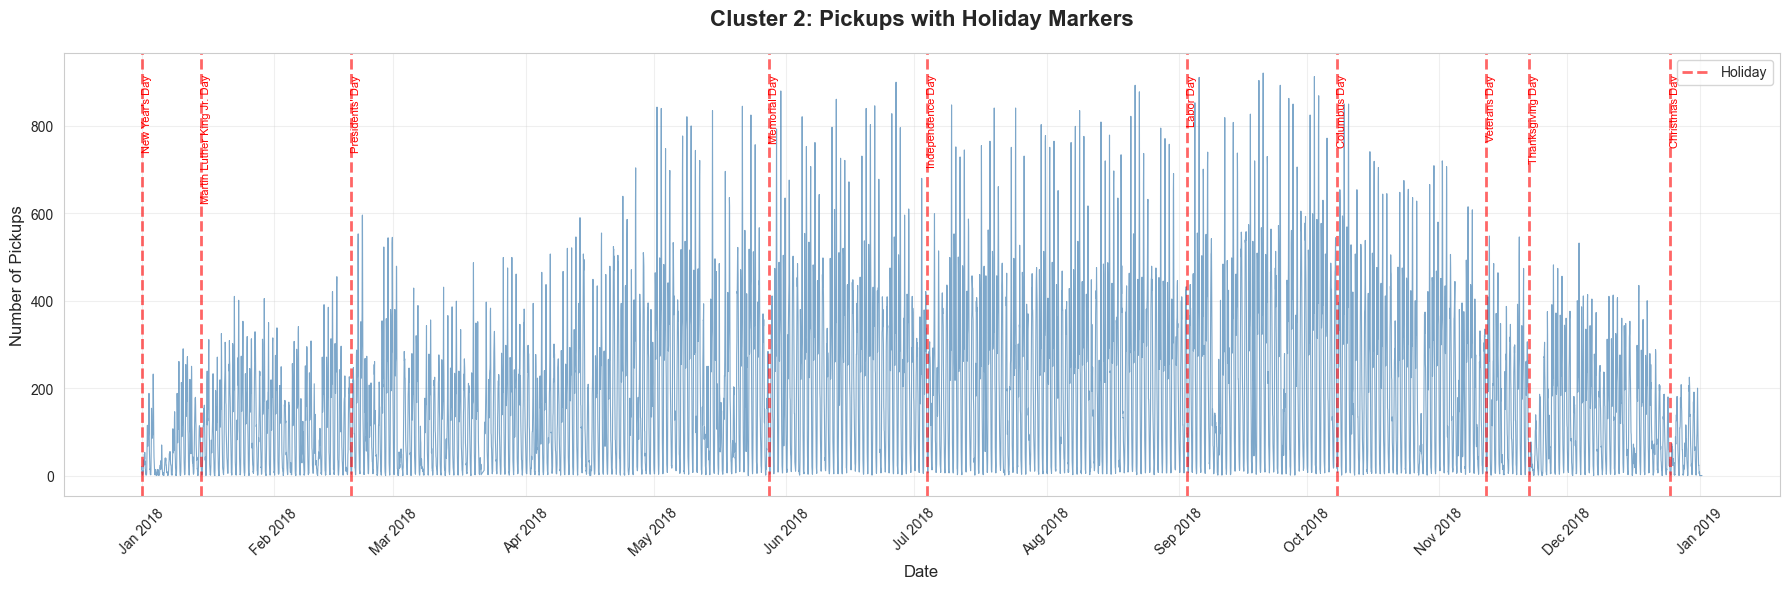

📊 Observation: Do holidays show significant drops in demand? Which holidays have the biggest impact?


In [82]:
# ============================================================================
# Visualization 3: Pickups with Holiday Markers
# ============================================================================

fig, ax = plt.subplots(figsize=(18, 6))

# Plot the time series
ax.plot(cluster_data['datetime'], cluster_data['pickups'], 
        linewidth=0.8, alpha=0.7, color='steelblue')

# Mark holidays with vertical lines
holiday_dates = cluster_data[cluster_data['is_holiday'] == 1]['datetime'].dt.date.unique()
for i, holiday_date in enumerate(holiday_dates):
    holiday_datetime = pd.to_datetime(holiday_date)
    ax.axvline(holiday_datetime, color='red', linestyle='--', linewidth=2, 
               alpha=0.6, label='Holiday' if i == 0 else '')
    
    # Add holiday name annotation (if available from holidays dataframe)
    holiday_info = holidays[holidays['date'].dt.date == holiday_date]
    if not holiday_info.empty:
        holiday_name = holiday_info.iloc[0]['name']
        ax.text(holiday_datetime, ax.get_ylim()[1] * 0.95, holiday_name, 
                rotation=90, verticalalignment='top', fontsize=8, color='red')

ax.set_title(f'Cluster {top_cluster}: Pickups with Holiday Markers', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Pickups', fontsize=12)

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"📊 Observation: Do holidays show significant drops in demand? Which holidays have the biggest impact?")

## Zoom in to independence day for example:

compare 3 days:
- before
- during
- after

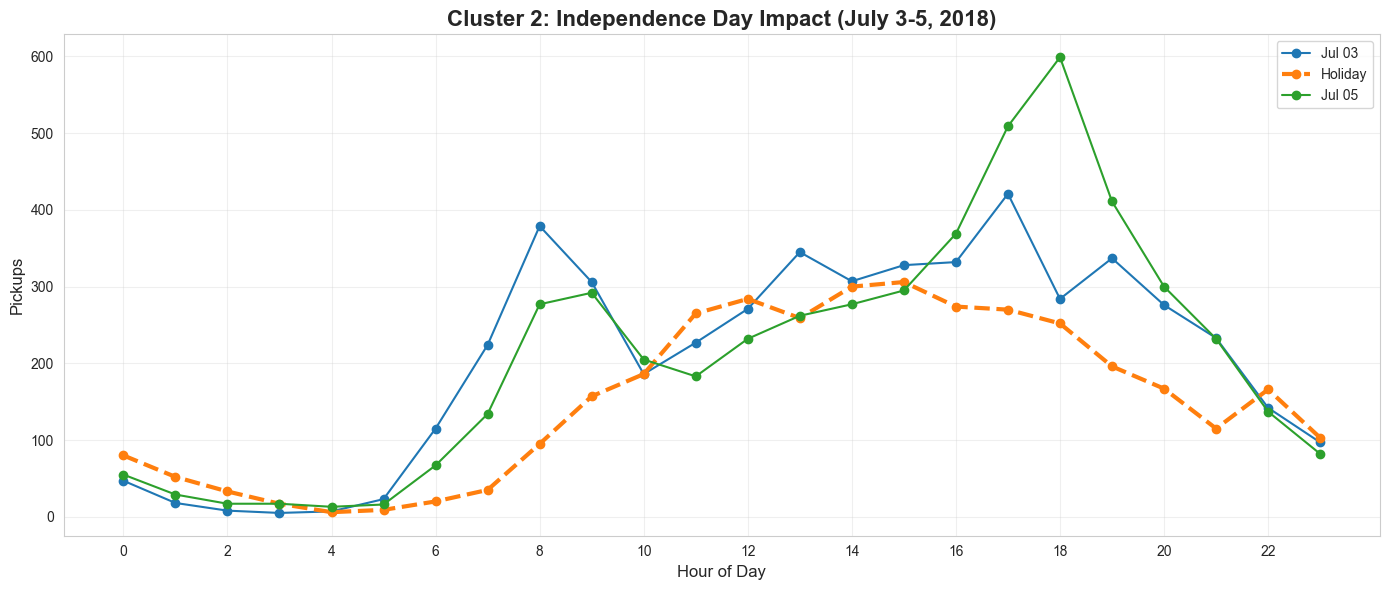

In [83]:
# compare 3 days: before, during, after a holiday
holiday_date = pd.to_datetime('2018-07-04')  # Independence Day
before = holiday_date - pd.Timedelta(days=1)
after = holiday_date + pd.Timedelta(days=1)

holiday_window = cluster_data[cluster_data['datetime'].between(before, after + pd.Timedelta(days=1))]

fig, ax = plt.subplots(figsize=(14, 6))
for date in [before, holiday_date, after]:
    day_data = holiday_window[holiday_window['datetime'].dt.date == date.date()]
    label = 'Holiday' if date == holiday_date else date.strftime('%b %d')
    linestyle = '--' if date == holiday_date else '-'
    linewidth = 3 if date == holiday_date else 1.5
    ax.plot(day_data['hour'], day_data['pickups'], marker='o', 
            label=label, linestyle=linestyle, linewidth=linewidth)

ax.set_title(f'Cluster {top_cluster}: Independence Day Impact (July 3-5, 2018)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Pickups', fontsize=12)
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Although July 4, 2018, was a Wednesday, the chart shows that it behaves like a weekend, with a noticeable surge in pickups in the afternoon

### 4. Daily Pattern: Average Hourly Demand by Day of Week
This heatmap-style visualization shows typical demand patterns for each hour and day of the week.

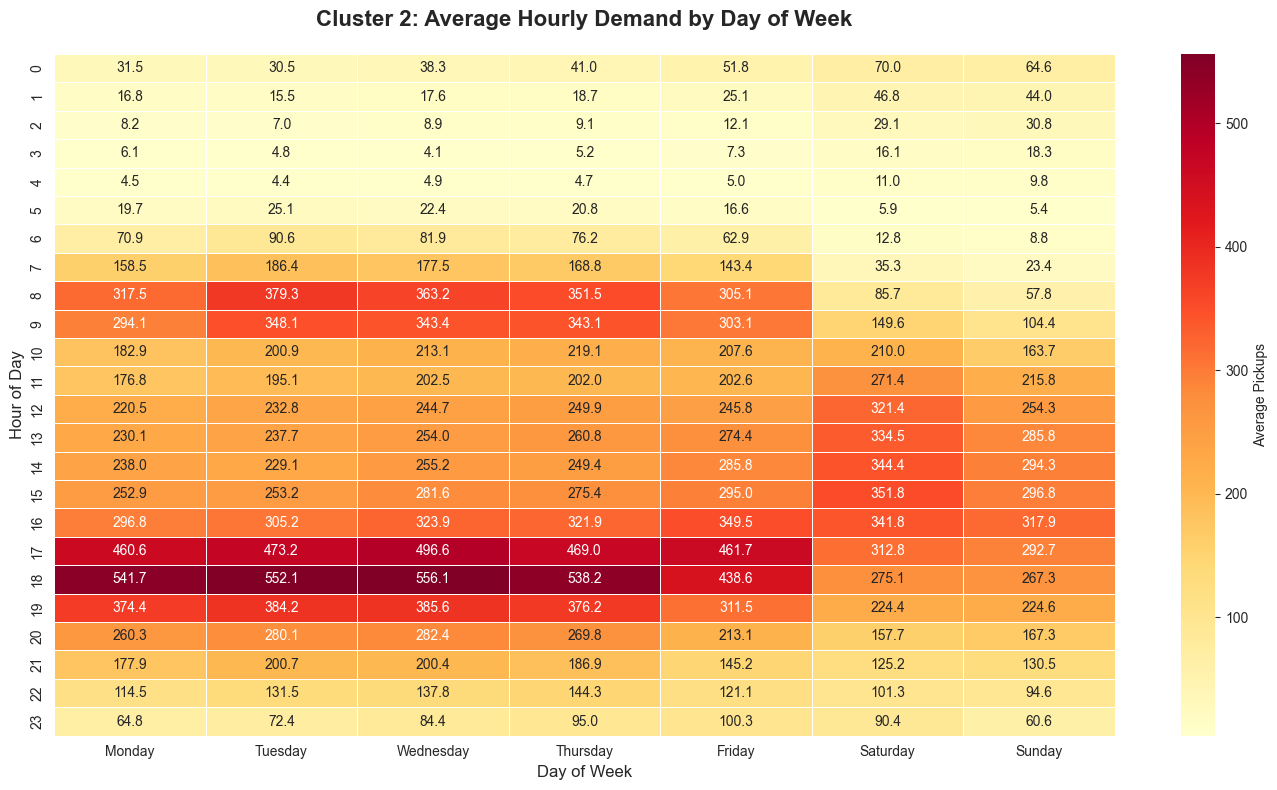

📊 Observation: Can you identify rush hours? Are weekday patterns different from weekends?


In [84]:
# ============================================================================
# Visualization 4: Average Hourly Demand by Day of Week
# ============================================================================

# Calculate average pickups by hour and day of week
hourly_pattern = cluster_data.groupby(['day_of_week', 'hour'])['pickups'].mean().reset_index()
hourly_pivot = hourly_pattern.pivot(index='hour', columns='day_of_week', values='pickups')

# Rename columns to day names
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hourly_pivot.columns = [day_names[int(col)] for col in hourly_pivot.columns]

fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(hourly_pivot, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Average Pickups'}, ax=ax, linewidths=0.5)

ax.set_title(f'Cluster {top_cluster}: Average Hourly Demand by Day of Week', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Hour of Day', fontsize=12)

plt.tight_layout()
plt.show()

print(f"📊 Observation: Can you identify rush hours? Are weekday patterns different from weekends?")

### 5. Pickups vs Dropoffs: Balance Analysis
Understanding the balance between pickups and dropoffs helps identify rebalancing needs.

/var/folders/3w/0qkwjm_s24jfd0d25nctm8mw0000gn/T/ipykernel_24386/2964158088.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_sample['net_flow'] = cluster_sample['pickups'] - cluster_sample['dropoffs']


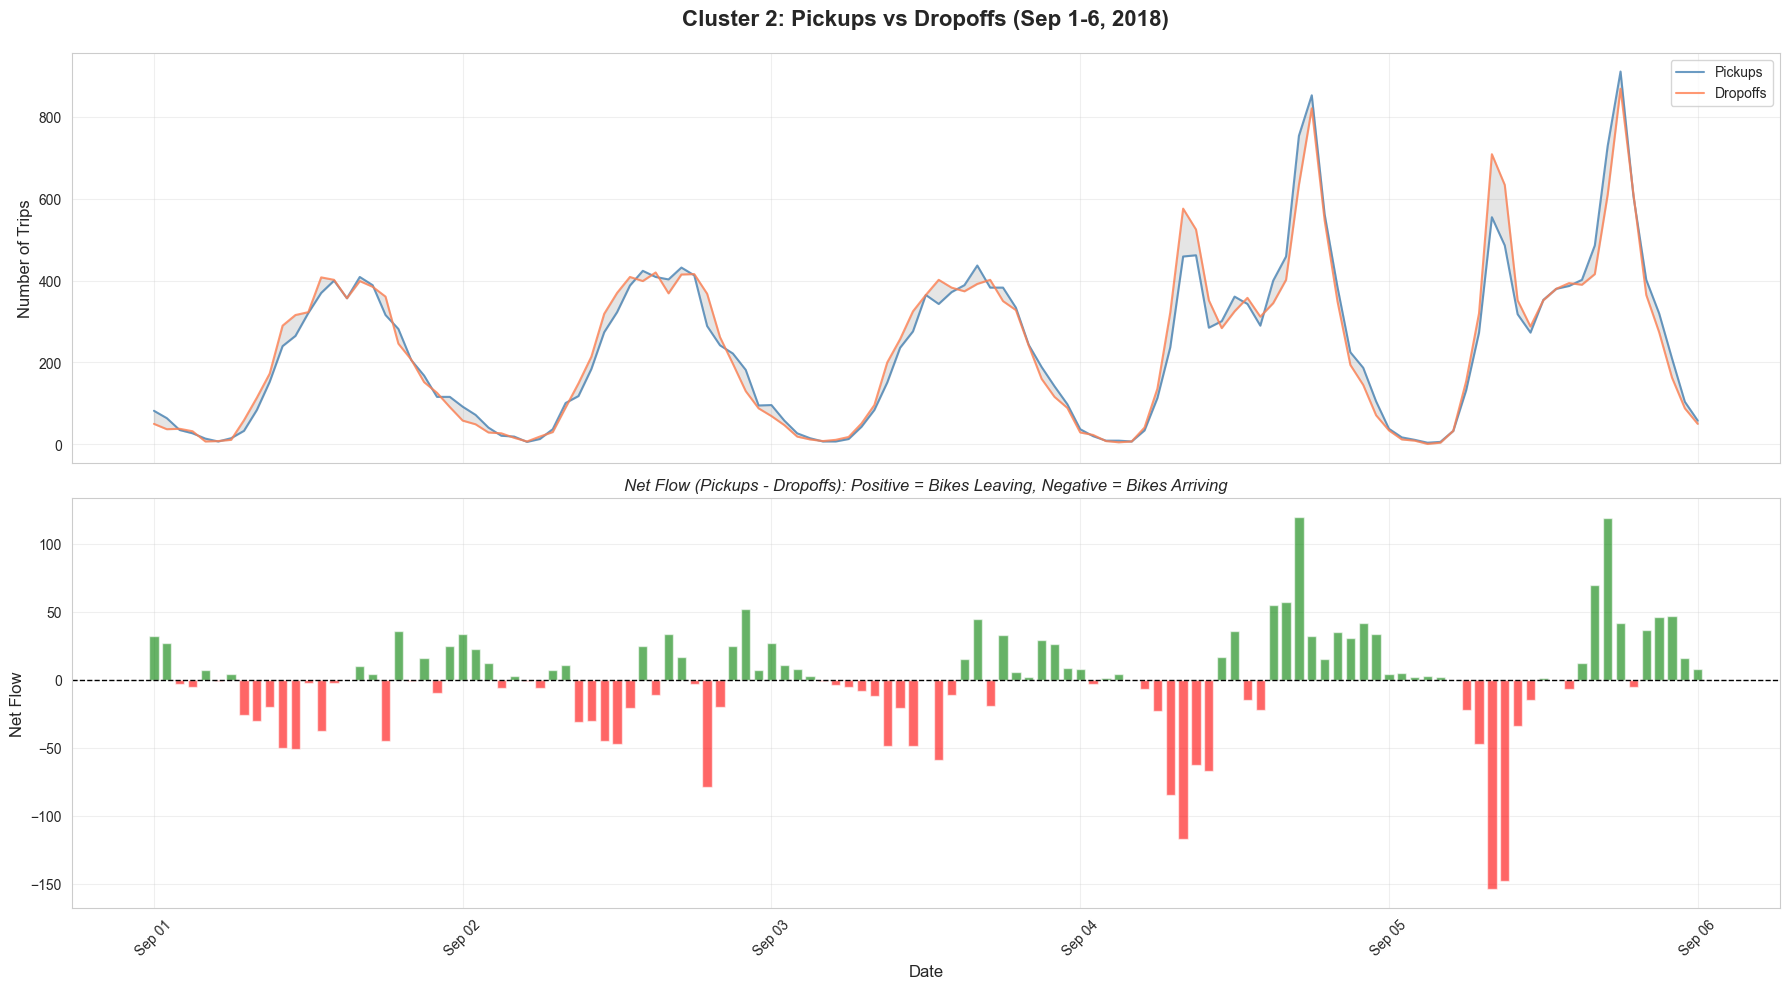

📊 Observation: When does this cluster need bike rebalancing? Morning or evening?


In [85]:
# ============================================================================
# Visualization 5: Pickups vs Dropoffs Over Time
# ============================================================================

# Focus on a 2-week period for clarity
sample_start = '2018-09-01'
sample_end = '2018-09-06'
cluster_sample = cluster_data[(cluster_data['datetime'] >= sample_start) & 
                               (cluster_data['datetime'] <= sample_end)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# Top plot: Pickups and Dropoffs
ax1.plot(cluster_sample['datetime'], cluster_sample['pickups'], 
         linewidth=1.5, color='steelblue', label='Pickups', alpha=0.8)
ax1.plot(cluster_sample['datetime'], cluster_sample['dropoffs'], 
         linewidth=1.5, color='coral', label='Dropoffs', alpha=0.8)
ax1.fill_between(cluster_sample['datetime'], cluster_sample['pickups'], 
                  cluster_sample['dropoffs'], alpha=0.2, color='gray')

ax1.set_title(f'Cluster {top_cluster}: Pickups vs Dropoffs (Sep 1-6, 2018)', 
              fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Number of Trips', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Bottom plot: Net Flow (Pickups - Dropoffs)
cluster_sample['net_flow'] = cluster_sample['pickups'] - cluster_sample['dropoffs']
colors = ['green' if x >= 0 else 'red' for x in cluster_sample['net_flow']]
ax2.bar(cluster_sample['datetime'], cluster_sample['net_flow'], 
        color=colors, alpha=0.6, width=0.03)
ax2.axhline(0, color='black', linewidth=1, linestyle='--')

ax2.set_title('Net Flow (Pickups - Dropoffs): Positive = Bikes Leaving, Negative = Bikes Arriving', 
              fontsize=12, style='italic')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Net Flow', fontsize=12)
ax2.grid(True, alpha=0.3)

# Format x-axis
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(f"📊 Observation: When does this cluster need bike rebalancing? Morning or evening?")

### 6. Monthly Aggregation: Seasonal Trends
This chart shows monthly totals to identify seasonal patterns (summer vs winter usage).

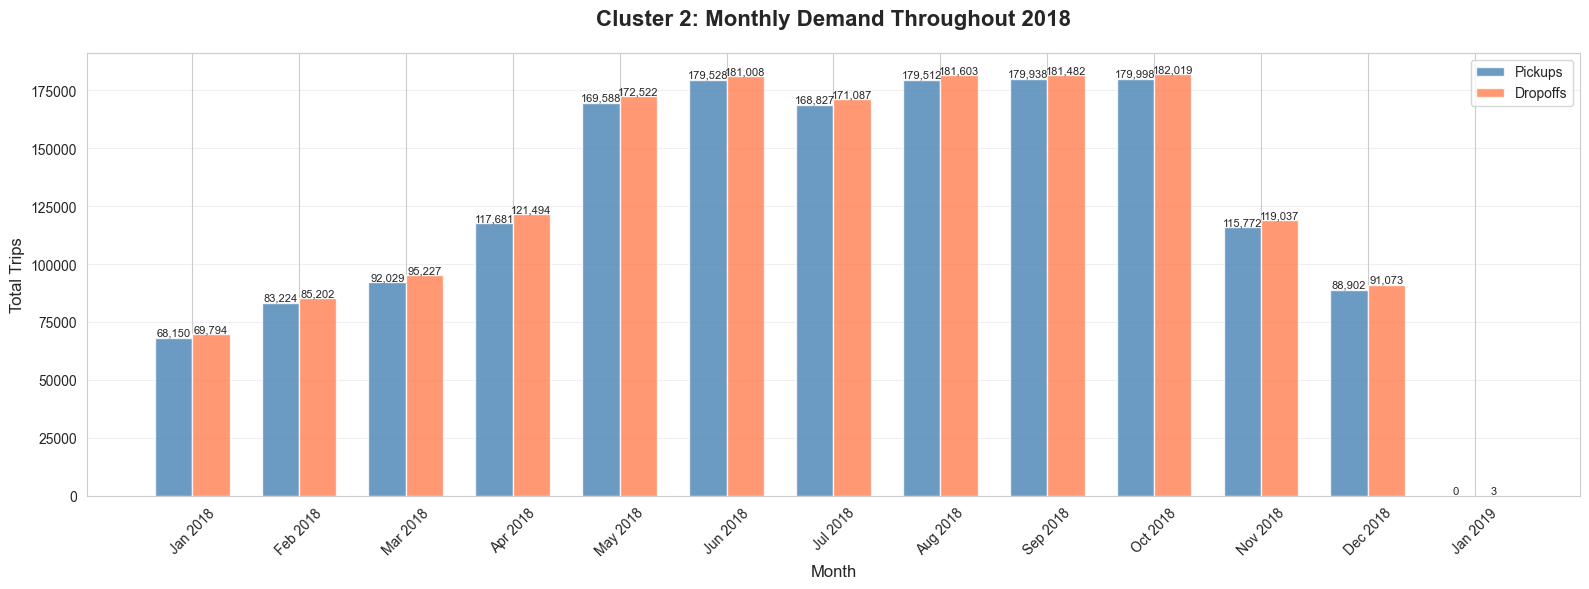

📊 Observation: Which months have highest demand? Is there a winter dip?


In [86]:
# ============================================================================
# Visualization 6: Monthly Pickups and Dropoffs
# ============================================================================

# Aggregate by month
cluster_data['month_date'] = cluster_data['datetime'].dt.to_period('M').dt.to_timestamp()
monthly_demand = cluster_data.groupby('month_date').agg({
    'pickups': 'sum',
    'dropoffs': 'sum'
}).reset_index()

fig, ax = plt.subplots(figsize=(16, 6))

x = range(len(monthly_demand))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], monthly_demand['pickups'], 
               width, label='Pickups', color='steelblue', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], monthly_demand['dropoffs'], 
               width, label='Dropoffs', color='coral', alpha=0.8)

ax.set_title(f'Cluster {top_cluster}: Monthly Demand Throughout 2018', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Trips', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(monthly_demand['month_date'].dt.strftime('%b %Y'), rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print(f"📊 Observation: Which months have highest demand? Is there a winter dip?")

### 7. Comparison: Top 5 Clusters
Compare demand patterns across multiple high-activity clusters to see if they behave similarly.

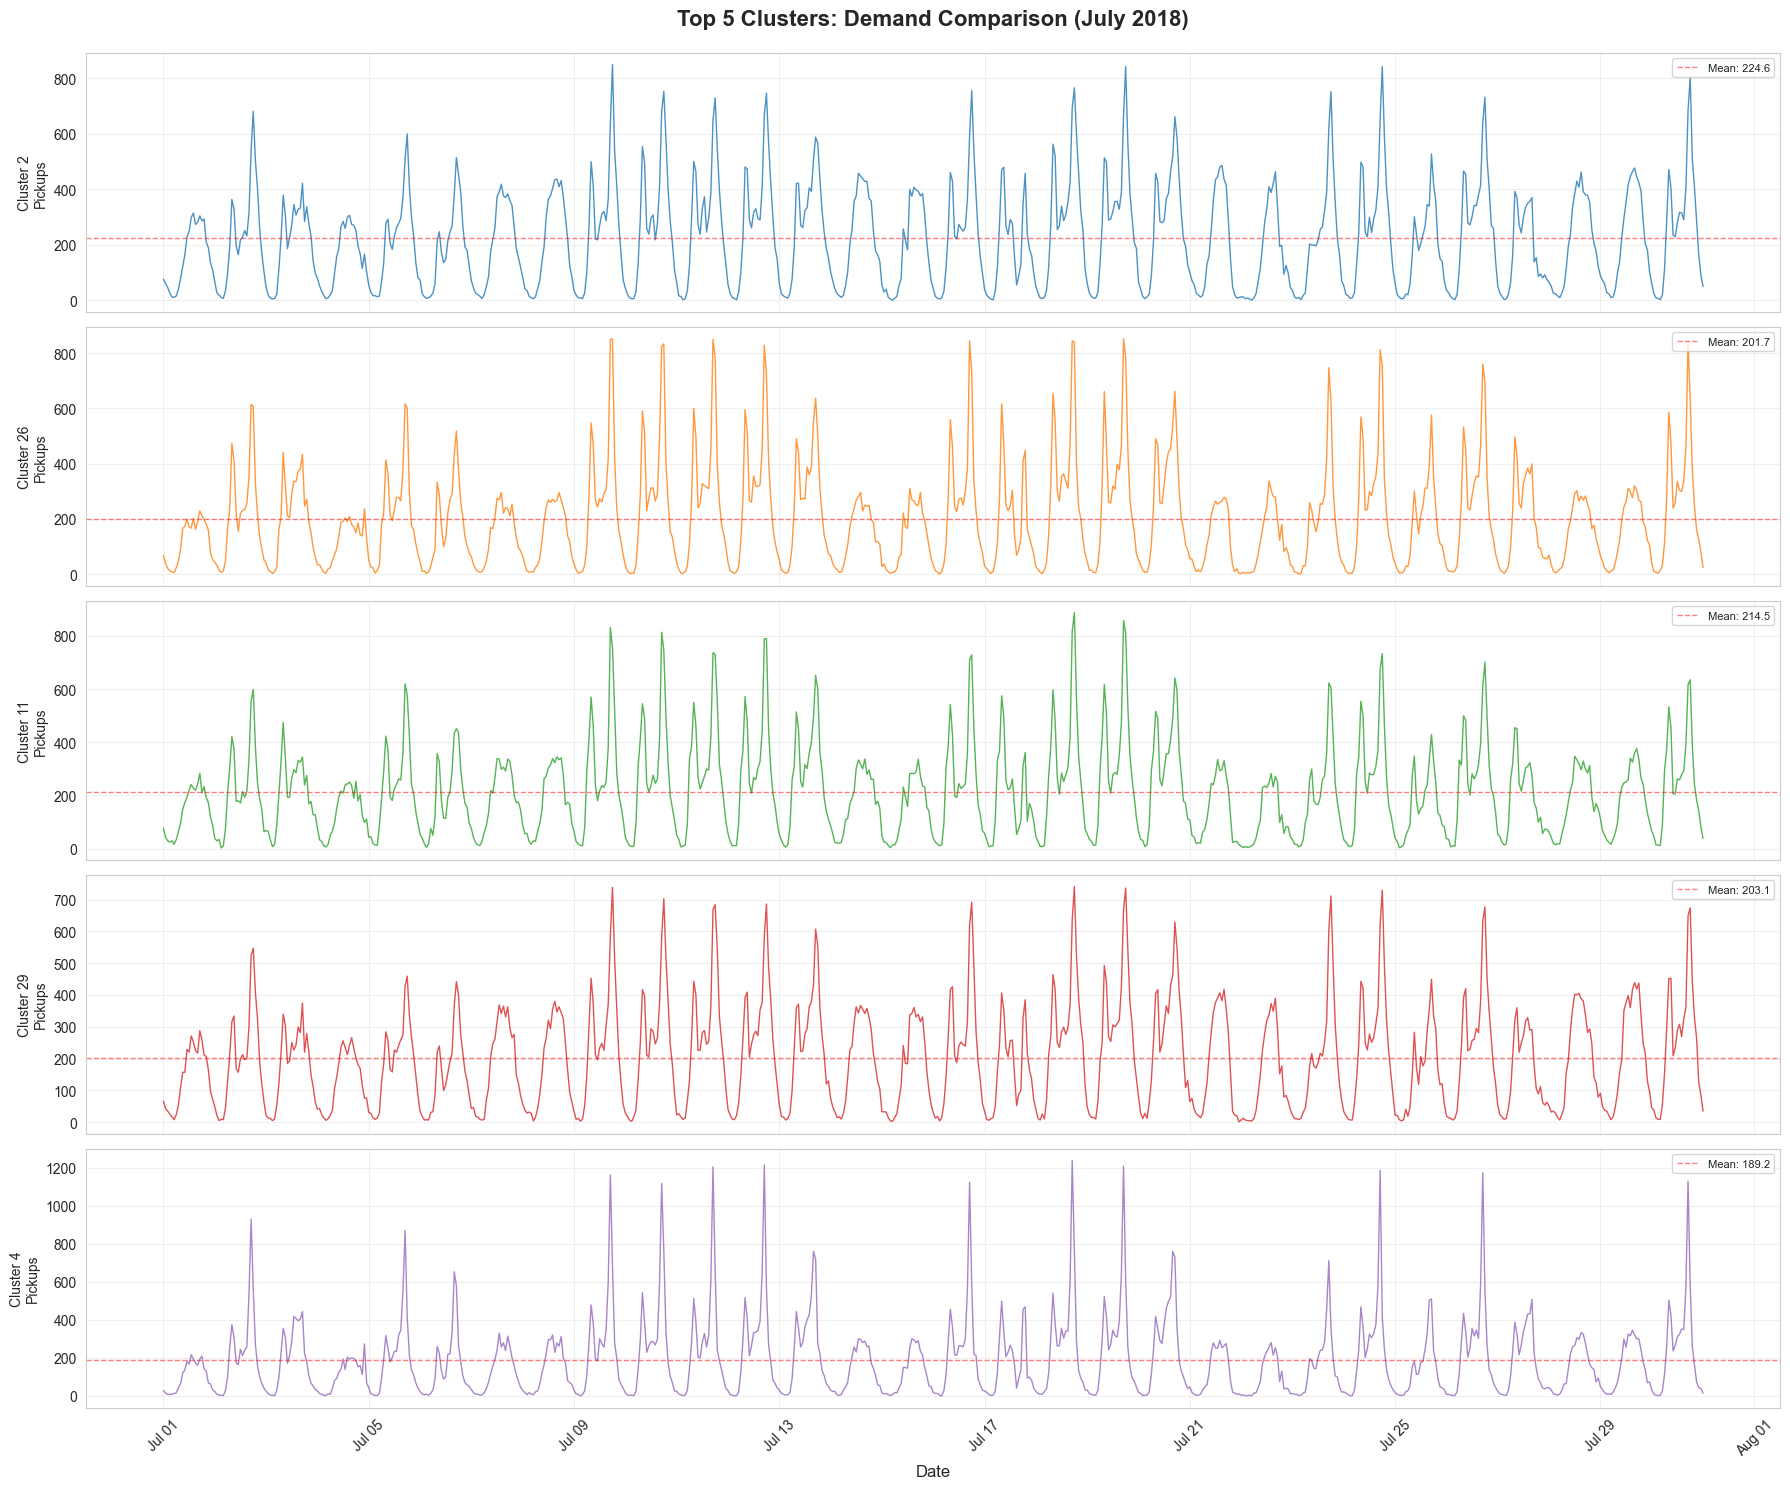

📊 Observation: Do all high-activity clusters follow similar patterns?


In [87]:
# ============================================================================
# Visualization 7: Compare Top 5 Clusters
# ============================================================================

# Get top 5 clusters by total pickups
top_5_clusters = demand_hourly.groupby('cluster')['pickups'].sum().nlargest(5).index

fig, axes = plt.subplots(5, 1, figsize=(18, 15), sharex=True)

for idx, cluster_id in enumerate(top_5_clusters):
    cluster_subset = demand_hourly[demand_hourly['cluster'] == cluster_id].copy()
    cluster_subset['datetime'] = pd.to_datetime(cluster_subset['date']) + pd.to_timedelta(cluster_subset['hour'], unit='h')
    cluster_subset = cluster_subset.sort_values('datetime')
    
    # Focus on a 1-month period for clarity
    sample_start = '2018-07-01'
    sample_end = '2018-07-31'
    cluster_month = cluster_subset[(cluster_subset['datetime'] >= sample_start) & 
                                    (cluster_subset['datetime'] <= sample_end)]
    
    axes[idx].plot(cluster_month['datetime'], cluster_month['pickups'], 
                   linewidth=1, color=f'C{idx}', alpha=0.8)
    axes[idx].set_ylabel(f'Cluster {cluster_id}\nPickups', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    
    # Add mean line
    mean_pickups = cluster_month['pickups'].mean()
    axes[idx].axhline(mean_pickups, color='red', linestyle='--', 
                      linewidth=1, alpha=0.5, label=f'Mean: {mean_pickups:.1f}')
    axes[idx].legend(loc='upper right', fontsize=8)

axes[0].set_title('Top 5 Clusters: Demand Comparison (July 2018)', 
                  fontsize=16, fontweight='bold', pad=20)
axes[-1].set_xlabel('Date', fontsize=12)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(f"📊 Observation: Do all high-activity clusters follow similar patterns?")

## Comparing average weekday vs weekend hourly patterns:

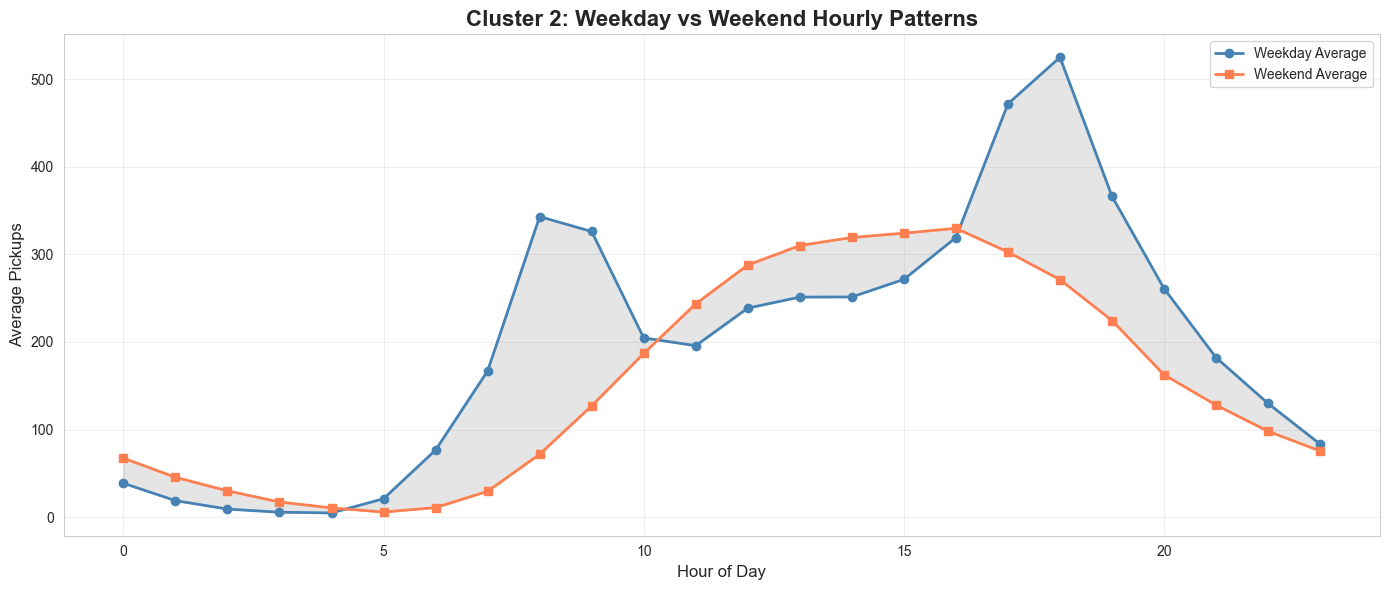

In [88]:
# Comparar patrones horarios: Weekday vs Weekend
weekday_pattern = cluster_data[cluster_data['is_weekend'] == 0].groupby('hour')['pickups'].mean()
weekend_pattern = cluster_data[cluster_data['is_weekend'] == 1].groupby('hour')['pickups'].mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(weekday_pattern.index, weekday_pattern.values, marker='o', linewidth=2, 
        label='Weekday Average', color='steelblue')
ax.plot(weekend_pattern.index, weekend_pattern.values, marker='s', linewidth=2, 
        label='Weekend Average', color='coral')
ax.fill_between(weekday_pattern.index, weekday_pattern.values, weekend_pattern.values, 
                alpha=0.2, color='gray')
ax.set_title(f'Cluster {top_cluster}: Weekday vs Weekend Hourly Patterns', fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Average Pickups', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Advanced Feature Engineering: Rush Hours and Demand Intensity

We'll create two types of temporal features:

### 1. Fixed Rush Hours (Domain Knowledge)
Based on typical urban commuting patterns:
- Morning rush: 7-9 AM (commute to work)
- Evening rush: 4-7 PM (commute home)
- Lunch time: 12-2 PM (midday activity)
- Night: 12-6 AM (low activity)

These capture **universal human behavior patterns** that apply across all clusters.

### 2. Dynamic Demand Intensity (Data-Driven)
Using percentiles within each cluster to identify:
- High demand hours (top 25% for that cluster)
- Very high demand hours (top 10% for that cluster)

This captures **cluster-specific patterns** (e.g., residential vs commercial areas have different peak times).

In [89]:
# ============================================================================
# Feature Engineering: Rush Hours (Fixed - Domain Knowledge)
# ============================================================================

# Universal urban patterns
demand_hourly['is_morning_rush'] = demand_hourly['hour'].between(7, 9).astype(int)
demand_hourly['is_evening_rush'] = demand_hourly['hour'].between(16, 19).astype(int)
demand_hourly['is_lunch_time'] = demand_hourly['hour'].between(12, 14).astype(int)
demand_hourly['is_night'] = (demand_hourly['hour'] < 6).astype(int)

# Interaction with weekends (rush hours behave differently)
demand_hourly['weekday_morning_rush'] = (
    (demand_hourly['is_morning_rush'] == 1) & 
    (demand_hourly['is_weekend'] == 0)
).astype(int)

demand_hourly['weekday_evening_rush'] = (
    (demand_hourly['is_evening_rush'] == 1) & 
    (demand_hourly['is_weekend'] == 0)
).astype(int)

# Cyclic encoding for hour: Converts hour (0-23) into sin/cos components
# This preserves the circular nature of time (hour 23 is close to hour 0)
# Without this, models would think 11 PM is far from midnight, when they're actually adjacent
# The model will use both hour_sin and hour_cos to understand temporal patterns correctly
demand_hourly['hour_sin'] = np.sin(2 * np.pi * demand_hourly['hour'] / 24)
demand_hourly['hour_cos'] = np.cos(2 * np.pi * demand_hourly['hour'] / 24)

print("✓ Fixed rush hour features created")
print(f"  Morning rush observations: {demand_hourly['is_morning_rush'].sum():,}")
print(f"  Evening rush observations: {demand_hourly['is_evening_rush'].sum():,}")

✓ Fixed rush hour features created
  Morning rush observations: 30,592
  Evening rush observations: 40,792


In [90]:
# ============================================================================
# Feature Engineering: Dynamic Demand Intensity (Data-Driven)
# ============================================================================

print("Creating dynamic demand intensity indicators (percentile-based)...")

# Calculate percentile rank within each cluster for PICKUPS
demand_hourly['pickups_percentile'] = demand_hourly.groupby('cluster')['pickups'].transform(
    lambda x: x.rank(pct=True)
)

# Calculate percentile rank within each cluster for DROPOFFS
demand_hourly['dropoffs_percentile'] = demand_hourly.groupby('cluster')['dropoffs'].transform(
    lambda x: x.rank(pct=True)
)

# Create binary indicators for high-demand PICKUPS
demand_hourly['is_high_demand'] = (demand_hourly['pickups_percentile'] > 0.75).astype(int)  # Top 25%
demand_hourly['is_very_high_demand'] = (demand_hourly['pickups_percentile'] > 0.90).astype(int)  # Top 10%
demand_hourly['is_low_demand'] = (demand_hourly['pickups_percentile'] < 0.25).astype(int)  # Bottom 25%

# Create binary indicators for high-demand DROPOFFS
demand_hourly['is_high_dropoff'] = (demand_hourly['dropoffs_percentile'] > 0.75).astype(int)  # Top 25%
demand_hourly['is_very_high_dropoff'] = (demand_hourly['dropoffs_percentile'] > 0.90).astype(int)  # Top 10%
demand_hourly['is_low_dropoff'] = (demand_hourly['dropoffs_percentile'] < 0.25).astype(int)  # Bottom 25%

# Interaction: High pickups + Low dropoffs = Critical rebalancing need
demand_hourly['critical_rebalancing_need'] = (
    (demand_hourly['is_high_demand'] == 1) & 
    (demand_hourly['is_low_dropoff'] == 1)
).astype(int)

print("✓ Dynamic demand intensity features created")
print(f"  Pickups - High demand: {demand_hourly['is_high_demand'].sum():,} ({demand_hourly['is_high_demand'].mean():.1%})")
print(f"  Dropoffs - High demand: {demand_hourly['is_high_dropoff'].sum():,} ({demand_hourly['is_high_dropoff'].mean():.1%})")
print(f"  Critical rebalancing need: {demand_hourly['critical_rebalancing_need'].sum():,} ({demand_hourly['critical_rebalancing_need'].mean():.1%})")

# Show example
example_cluster = demand_hourly.groupby('cluster')['pickups'].sum().idxmax()
example_data = demand_hourly[demand_hourly['cluster'] == example_cluster].groupby('hour').agg({
    'is_morning_rush': 'first',
    'is_evening_rush': 'first',
    'is_high_demand': 'mean',
    'is_high_dropoff': 'mean',
    'critical_rebalancing_need': 'mean',
    'pickups': 'mean',
    'dropoffs': 'mean'
}).round(2)

print(f"\nExample: Cluster {example_cluster} - Feature Summary by Hour")
print(example_data[['is_morning_rush', 'is_high_demand', 'is_high_dropoff', 'critical_rebalancing_need']])

Creating dynamic demand intensity indicators (percentile-based)...
✓ Dynamic demand intensity features created
  Pickups - High demand: 59,490 (24.9%)
  Dropoffs - High demand: 59,630 (25.0%)
  Critical rebalancing need: 4 (0.0%)

Example: Cluster 2 - Feature Summary by Hour
      is_morning_rush  is_high_demand  is_high_dropoff  \
hour                                                     
0                   0            0.00             0.00   
1                   0            0.00             0.00   
2                   0            0.00             0.00   
3                   0            0.00             0.00   
4                   0            0.00             0.00   
5                   0            0.00             0.00   
6                   0            0.00             0.00   
7                   1            0.01             0.05   
8                   1            0.45             0.53   
9                   1            0.43             0.56   
10                  0       

In [91]:
# ============================================================================
# Feature Engineering: Net Flow
# ============================================================================

# Calculate instantaneous net flow (pickups - dropoffs)
demand_hourly['net_flow'] = demand_hourly['pickups'] - demand_hourly['dropoffs']

# Sort by cluster and time
demand_hourly = demand_hourly.sort_values(['cluster', 'date', 'hour']).reset_index(drop=True)

# Cluster type: Source (bikes leave) vs Sink (bikes arrive)
cluster_avg_net = demand_hourly.groupby('cluster')['net_flow'].mean()
demand_hourly['cluster_is_source'] = demand_hourly['cluster'].map(
    lambda x: 1 if cluster_avg_net.get(x, 0) > 0 else 0
)

print("✓ Net flow features created")
print(f"  Mean net flow: {demand_hourly['net_flow'].mean():.2f}")
print(f"  Net flow std: {demand_hourly['net_flow'].std():.2f}")
print(f"  Max deficit (single hour): {demand_hourly['net_flow'].min():.0f} bikes")
print(f"  Max surplus (single hour): {demand_hourly['net_flow'].max():.0f} bikes")

demand_hourly[['cluster', 'hour', 'pickups', 'dropoffs', 'net_flow', 
               'cluster_is_source', 'is_morning_rush', 'is_high_demand']].head(24)

✓ Net flow features created
  Mean net flow: 0.00
  Net flow std: 42.98
  Max deficit (single hour): -646 bikes
  Max surplus (single hour): 751 bikes


,cluster,hour,pickups,dropoffs,net_flow,cluster_is_source,is_morning_rush,is_high_demand
0,0,0,3.0,2.0,1.0,1,0,0
1,0,1,1.0,5.0,-4.0,1,0,0
2,0,2,4.0,1.0,3.0,1,0,0
3,0,3,0.0,1.0,-1.0,1,0,0
4,0,5,1.0,0.0,1.0,1,0,0
5,0,7,2.0,0.0,2.0,1,1,0
6,0,8,6.0,0.0,6.0,1,1,0
7,0,9,8.0,11.0,-3.0,1,1,0
8,0,10,8.0,9.0,-1.0,1,0,0
9,0,11,8.0,6.0,2.0,1,0,0


### Comparing Fixed vs Dynamic Rush Hour Detection

Let's visualize how fixed (domain knowledge) and dynamic (percentile-based) rush hours differ across clusters.

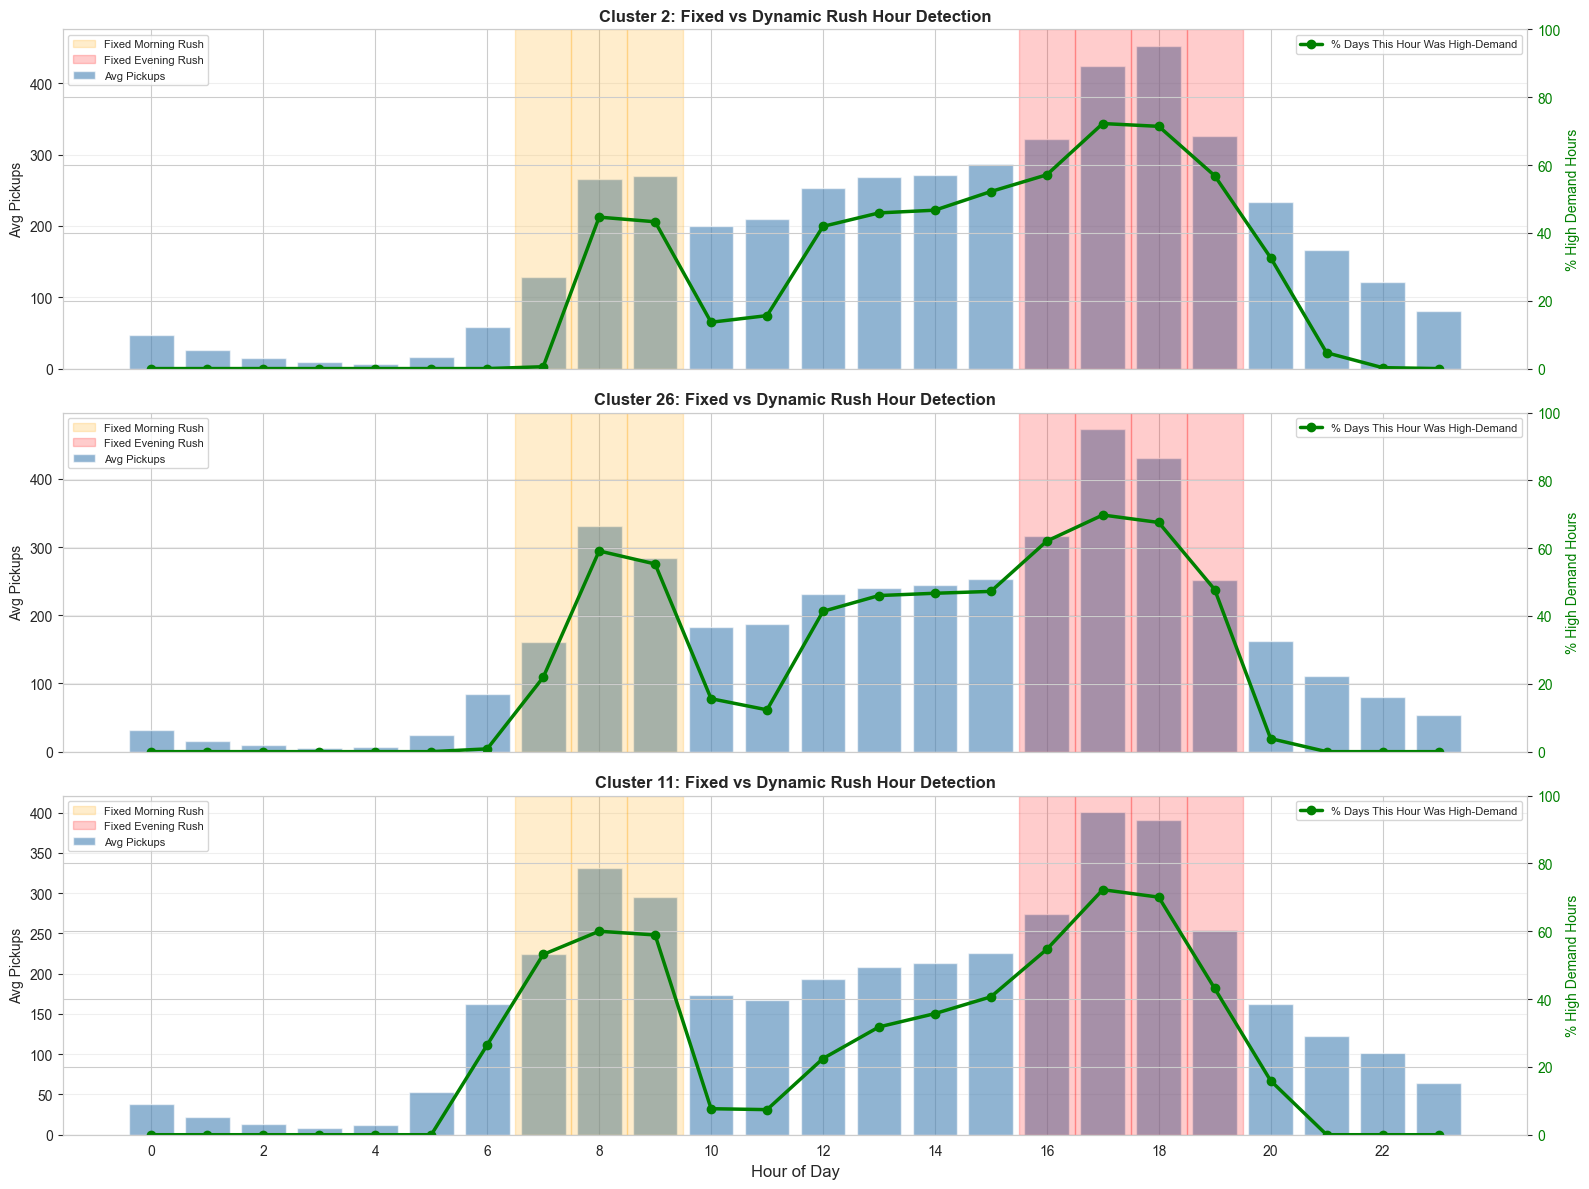

📊 Observation:
  - Orange/Red zones: Fixed rush hours (same for all clusters)
  - Green line: Dynamic high-demand hours (cluster-specific)
  - Notice how some clusters have peaks outside traditional rush hours!


In [92]:
# ============================================================================
# Visualization: Fixed vs Dynamic Rush Hours
# ============================================================================

# Compare 3 different cluster types
top_clusters = demand_hourly.groupby('cluster')['pickups'].sum().nlargest(3).index

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for idx, cluster_id in enumerate(top_clusters):
    cluster_subset = demand_hourly[demand_hourly['cluster'] == cluster_id]
    
    # Average pickups by hour
    hourly_avg = cluster_subset.groupby('hour').agg({
        'pickups': 'mean',
        'is_morning_rush': 'first',
        'is_evening_rush': 'first',
        'is_high_demand': 'mean'  # % of times this hour is high-demand
    })
    
    ax = axes[idx]
    
    # Plot average pickups
    ax.bar(hourly_avg.index, hourly_avg['pickups'], alpha=0.6, color='steelblue', label='Avg Pickups')
    
    # Highlight fixed rush hours (domain knowledge)
    morning_rush_hours = hourly_avg[hourly_avg['is_morning_rush'] == 1].index
    evening_rush_hours = hourly_avg[hourly_avg['is_evening_rush'] == 1].index
    
    for hour in morning_rush_hours:
        ax.axvspan(hour - 0.5, hour + 0.5, alpha=0.2, color='orange', 
                   label='Fixed Morning Rush' if hour == morning_rush_hours[0] else '')
    for hour in evening_rush_hours:
        ax.axvspan(hour - 0.5, hour + 0.5, alpha=0.2, color='red', 
                   label='Fixed Evening Rush' if hour == evening_rush_hours[0] else '')
    
    # Overlay dynamic high-demand indicator (line)
    ax2 = ax.twinx()
    ax2.plot(hourly_avg.index, hourly_avg['is_high_demand'] * 100, 
             color='green', linewidth=2.5, marker='o', label='% Days This Hour Was High-Demand')
    ax2.set_ylabel('% High Demand Hours', fontsize=10, color='green')
    ax2.tick_params(axis='y', labelcolor='green')
    ax2.set_ylim(0, 100)
    
    ax.set_title(f'Cluster {cluster_id}: Fixed vs Dynamic Rush Hour Detection', 
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Avg Pickups', fontsize=10)
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

axes[-1].set_xlabel('Hour of Day', fontsize=12)
axes[-1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

print("📊 Observation:")
print("  - Orange/Red zones: Fixed rush hours (same for all clusters)")
print("  - Green line: Dynamic high-demand hours (cluster-specific)")
print("  - Notice how some clusters have peaks outside traditional rush hours!")

In [93]:
list(demand_hourly.columns)


['date',
 'hour',
 'cluster',
 'pickups',
 'avg_trip_duration',
 'pct_subscribers',
 'dropoffs',
 'avg_age',
 'month',
 'day_of_week',
 'day_of_month',
 'week_of_year',
 'is_weekend',
 'season',
 'season_fall',
 'season_spring',
 'season_summer',
 'season_winter',
 'is_holiday',
 'is_special_event',
 'cluster_station_count',
 'cluster_center_lat',
 'cluster_center_lng',
 'cluster_total_trips',
 'pickups_lag_24h',
 'pickups_lag_168h',
 'pickups_rolling_24h',
 'dropoffs_lag_24h',
 'dropoffs_lag_168h',
 'dropoffs_rolling_24h',
 'is_morning_rush',
 'is_evening_rush',
 'is_lunch_time',
 'is_night',
 'weekday_morning_rush',
 'weekday_evening_rush',
 'hour_sin',
 'hour_cos',
 'pickups_percentile',
 'dropoffs_percentile',
 'is_high_demand',
 'is_very_high_demand',
 'is_low_demand',
 'is_high_dropoff',
 'is_very_high_dropoff',
 'is_low_dropoff',
 'critical_rebalancing_need',
 'net_flow',
 'cluster_is_source']

## Final Dataset Preparation and Train/Validation/Test Split

Now that we have engineered all features, we need to:

1. **Select and organize features** for modeling
2. **Standardize continuous variables** (preserve model performance and interpretability)
3. **Handle missing values** from lag features (first days have no historical data)
4. **Split data chronologically** into train (70%) and test (30%) sets
   - Train: January - September (70% of year)
   - Test: October - December (30% of year)
   - **No shuffling** - time series must maintain temporal order

This final dataset will be ready for time series forecasting models.

In [94]:
# ============================================================================
# Step 1: Organize Features by Type
# ============================================================================

print("Organizing features by type...")

# Target variables (what we want to predict)
target_vars = ['pickups', 'dropoffs']

# Identifiers (not used in modeling, but needed for tracking)
id_vars = ['date', 'cluster']

# Continuous features (need standardization)
continuous_features = [
    'avg_trip_duration',
    'pct_subscribers',
    'avg_age',
    'cluster_station_count',
    'cluster_center_lat',
    'cluster_center_lng',
    'cluster_total_trips',
    'pickups_lag_24h',
    'pickups_lag_168h',
    'pickups_rolling_24h',
    'dropoffs_lag_24h',
    'dropoffs_lag_168h',
    'dropoffs_rolling_24h',
    'hour_sin',
    'hour_cos',
    'net_flow',
    'pickups_percentile',
    'dropoffs_percentile'
]

# Categorical/Binary features (already encoded, no standardization needed)
categorical_features = [
    'hour',
    'month',
    'day_of_week',
    'day_of_month',
    'week_of_year',
    'is_weekend',
    'season_fall',
    'season_spring',
    'season_summer',
    'season_winter',
    'is_holiday',
    'is_special_event',
    'is_morning_rush',
    'is_evening_rush',
    'is_lunch_time',
    'is_night',
    'weekday_morning_rush',
    'weekday_evening_rush',
    'is_high_demand',
    'is_very_high_demand',
    'is_low_demand',
    'is_high_dropoff',
    'is_very_high_dropoff',
    'is_low_dropoff',
    'critical_rebalancing_need',
    'cluster_is_source'
]

# All feature columns (for modeling)
feature_cols = continuous_features + categorical_features

print(f"Feature organization:")
print(f"  - Target variables: {len(target_vars)}")
print(f"  - Continuous features: {len(continuous_features)}")
print(f"  - Categorical features: {len(categorical_features)}")
print(f"  - Total features for modeling: {len(feature_cols)}")

Organizing features by type...
Feature organization:
  - Target variables: 2
  - Continuous features: 18
  - Categorical features: 26
  - Total features for modeling: 44


In [95]:
# ============================================================================
# Step 2: Handle Missing Values (from lag features)
# ============================================================================

print("\nHandling missing values...")

# Check missing values
missing_summary = demand_hourly[feature_cols + target_vars].isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

if len(missing_summary) > 0:
    print(f"Missing values found in {len(missing_summary)} columns:")
    print(missing_summary)
    
    # Strategy: Drop rows with missing lag features (first week of data)
    # This is acceptable because we have 365 days and only lose ~7 days
    initial_rows = len(demand_hourly)
    demand_hourly_clean = demand_hourly.dropna(subset=feature_cols + target_vars).copy()
    dropped_rows = initial_rows - len(demand_hourly_clean)
    
    print(f"\nDropped {dropped_rows:,} rows with missing values ({dropped_rows/initial_rows:.1%})")
    print(f"  Remaining: {len(demand_hourly_clean):,} observations")
else:
    demand_hourly_clean = demand_hourly.copy()
    print("No missing values found")

# Sort by date and hour (ensure chronological order)
demand_hourly_clean = demand_hourly_clean.sort_values(['date', 'hour', 'cluster']).reset_index(drop=True)

print(f"\nFinal dataset shape: {demand_hourly_clean.shape}")
print(f"Date range: {demand_hourly_clean['date'].min()} to {demand_hourly_clean['date'].max()}")


Handling missing values...
Missing values found in 4 columns:
pickups_lag_168h     4824
dropoffs_lag_168h    4824
pickups_lag_24h       718
dropoffs_lag_24h      718
dtype: int64

Dropped 4,824 rows with missing values (2.0%)
  Remaining: 233,836 observations

Final dataset shape: (233836, 49)
Date range: 2018-01-08 00:00:00 to 2019-01-01 00:00:00


In [96]:
# ============================================================================
# Step 3: Standardize Continuous Features
# ============================================================================

print("\nStandardizing continuous features...")

from sklearn.preprocessing import StandardScaler

# Create a copy for standardization
demand_final = demand_hourly_clean.copy()

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on continuous features and transform
demand_final[continuous_features] = scaler.fit_transform(demand_final[continuous_features])

print(f"Standardized {len(continuous_features)} continuous features")
print(f"  Mean ≈ 0, Std ≈ 1 for all continuous features")

# Verify standardization
print("\nStandardization check (first 5 continuous features):")
for col in continuous_features[:5]:
    print(f"  {col}: mean={demand_final[col].mean():.4f}, std={demand_final[col].std():.4f}")


Standardizing continuous features...


Standardized 18 continuous features
  Mean ≈ 0, Std ≈ 1 for all continuous features

Standardization check (first 5 continuous features):
  avg_trip_duration: mean=-0.0000, std=1.0000
  pct_subscribers: mean=-0.0000, std=1.0000
  avg_age: mean=0.0000, std=1.0000
  cluster_station_count: mean=-0.0000, std=1.0000
  cluster_center_lat: mean=0.0000, std=1.0000


## Time Series Validation and Feature Selection

Before splitting our data and training models, we need to:

1. **Check stationarity** using the Augmented Dickey-Fuller (ADF) test
2. **Analyze autocorrelation** (ACF/PACF) to understand temporal dependencies
3. **Clean up features** - remove redundant or problematic features
4. **Validate data quality** - ensure no issues before modeling

These steps are critical for time series forecasting success.

In [97]:
# ============================================================================
# Time Series Validation: Stationarity Check (ADF Test)
# ============================================================================

from statsmodels.tsa.stattools import adfuller

# Test for pickups (aggregate across all clusters)
pickups_series = demand_hourly.groupby("date")["pickups"].sum()

result_pickups = adfuller(pickups_series)
print("\n📊 Augmented Dickey-Fuller Test for PICKUPS:")
print(f"   ADF Statistic: {result_pickups[0]:.6f}")
print(f"   p-value: {result_pickups[1]:.6f}")
print(f"   Critical Values:")
for key, value in result_pickups[4].items():
    print(f"      {key}: {value:.3f}")

if result_pickups[1] < 0.05:
    print(f"RESULT: Series is STATIONARY (p-value < 0.05)")
else:
    print(f"RESULT: Series is NON-STATIONARY (p-value >= 0.05)")

# Test for dropoffs
dropoffs_series = demand_hourly.groupby("date")["dropoffs"].sum()

result_dropoffs = adfuller(dropoffs_series)
print("\n📊 Augmented Dickey-Fuller Test for DROPOFFS:")
print(f"   ADF Statistic: {result_dropoffs[0]:.6f}")
print(f"   p-value: {result_dropoffs[1]:.6f}")
print(f"   Critical Values:")
for key, value in result_dropoffs[4].items():
    print(f"      {key}: {value:.3f}")

if result_dropoffs[1] < 0.05:
    print(f"RESULT: Series is STATIONARY (p-value < 0.05)")
else:
    print(f"RESULT: Series is NON-STATIONARY (p-value >= 0.05)")

print("\n" + "=" * 80)


📊 Augmented Dickey-Fuller Test for PICKUPS:
   ADF Statistic: -2.164664
   p-value: 0.219319
   Critical Values:
      1%: -3.449
      5%: -2.870
      10%: -2.571
RESULT: Series is NON-STATIONARY (p-value >= 0.05)

📊 Augmented Dickey-Fuller Test for DROPOFFS:
   ADF Statistic: -2.165425
   p-value: 0.219033
   Critical Values:
      1%: -3.449
      5%: -2.870
      10%: -2.571
RESULT: Series is NON-STATIONARY (p-value >= 0.05)



Analyzing autocorrelation patterns...


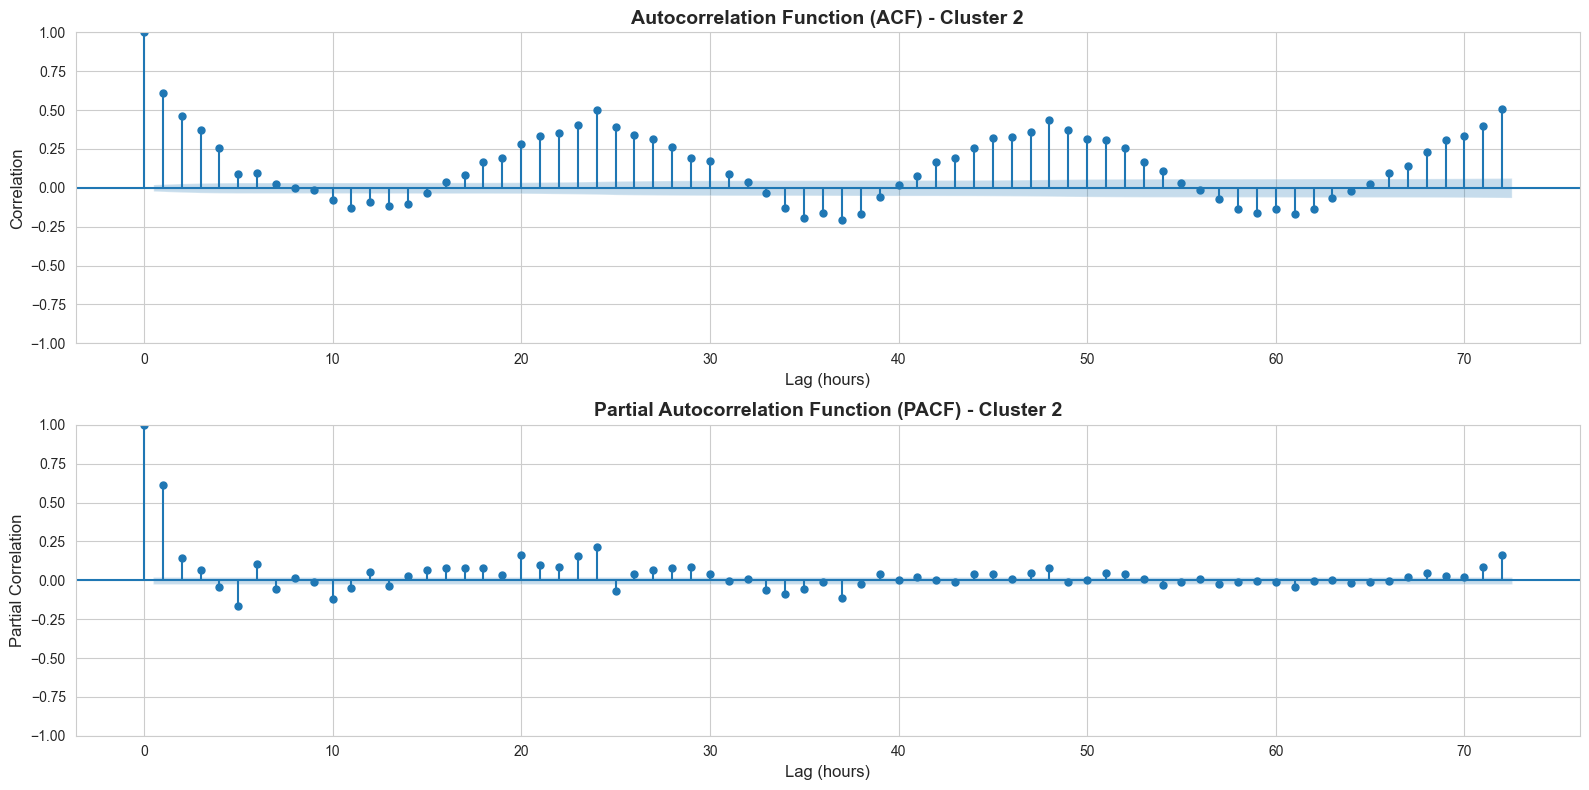

In [98]:
# ============================================================================
# Time Series Validation: Autocorrelation Analysis
# ============================================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

print("Analyzing autocorrelation patterns...")

# Select a representative cluster for analysis
top_cluster = demand_hourly.groupby('cluster')['pickups'].sum().idxmax()
cluster_pickups = demand_hourly[demand_hourly['cluster'] == top_cluster].sort_values('date')['pickups']

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# ACF plot
plot_acf(cluster_pickups, lags=72, ax=axes[0])  # 72 hours = 3 days
axes[0].set_title(f'Autocorrelation Function (ACF) - Cluster {top_cluster}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lag (hours)', fontsize=12)
axes[0].set_ylabel('Correlation', fontsize=12)

# PACF plot
plot_pacf(cluster_pickups, lags=72, ax=axes[1])
axes[1].set_title(f'Partial Autocorrelation Function (PACF) - Cluster {top_cluster}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lag (hours)', fontsize=12)
axes[1].set_ylabel('Partial Correlation', fontsize=12)

plt.tight_layout()
plt.show()

### Time Series Analysis: Key Findings

#### 1. Stationarity Test Results

The Augmented Dickey-Fuller (ADF) test indicates that both pickups and dropoffs are **non-stationary** (p-value > 0.05). This is expected for real-world demand data, which typically exhibits:
- Seasonal trends (summer vs. winter usage)
- Weekly patterns (weekday vs. weekend)
- Daily cycles (rush hours)

**Implication:** For classical ARIMA models, differencing (d=1) would be required. However, modern machine learning models (Gradient Boosting, Neural Networks, Random Forest) can handle non-stationary data directly when provided with appropriate features.

#### 2. Autocorrelation Analysis (ACF/PACF)

The ACF and PACF plots reveal strong temporal patterns:

**ACF (Autocorrelation Function):**
- Strong correlation at **lag 24** (and multiples: 48, 72) confirms clear **daily seasonality**
- Gradual decay suggests the presence of trend and seasonal components
- Persistent patterns validate our choice of 24-hour and 168-hour lag features

**PACF (Partial Autocorrelation Function):**
- Significant spikes at **lags 1-3** suggest an AR(3) process
- Strong spike at **lag 24** indicates direct daily dependence
- Most other lags fall within confidence bands, suggesting our lag features capture the main temporal dependencies

#### 3. Modeling Strategy

Given these findings, our approach is well-suited:
- ✅ **Lag features** (24h, 168h, rolling averages) capture temporal dependencies
- ✅ **Seasonal features** (month, season dummies, day of week) handle seasonality
- ✅ **Rush hour indicators** capture intra-day patterns
- ✅ Modern ML models can learn from these features without requiring explicit differencing

For this project, we will proceed with **supervised learning models** (Gradient Boosting, Neural Networks) that leverage our engineered features, rather than classical ARIMA approaches. This allows us to incorporate external variables (holidays, weather, cluster characteristics) more naturally.

## 📖 Final Feature Dictionary

Before proceeding to model training, let's document all features in our final dataset. This will help ensure we understand what information we're providing to our models.

### 🆔 Identifier Columns (not used as features)
- **`date`**: Date of observation (YYYY-MM-DD)
- **`hour`**: Hour of day (0-23)
- **`cluster`**: Spatial cluster ID (0-24)

### 🎯 Target Variables
- **`pickups`**: Number of bike pickups in this cluster-hour
- **`dropoffs`**: Number of bike dropoffs in this cluster-hour

### ⏰ Temporal Features
- **`month`**: Month of year (1-12)
- **`day_of_week`**: Day of week (0=Monday, 6=Sunday)
- **`day_of_month`**: Day of month (1-31)
- **`week_of_year`**: ISO week number (1-53)
- **`is_weekend`**: Binary flag for Saturday/Sunday
- **`hour_sin`**, **`hour_cos`**: Cyclic encoding of hour (captures circular nature of time)

### 🌦️ Seasonal Features
- **`season_fall`**, **`season_spring`**, **`season_summer`**, **`season_winter`**: One-hot encoded seasons

### 📅 Special Day Indicators
- **`is_holiday`**: Binary flag for NYC public holidays
- **`is_special_event`**: Binary flag for major NYC events (marathons, parades, etc.)

### 🚴 Historical Demand (Lag Features)
- **`pickups_lag_24h`**: Pickups exactly 24 hours ago (same hour yesterday)
- **`pickups_lag_168h`**: Pickups exactly 168 hours ago (same hour last week)
- **`pickups_rolling_24h`**: Average pickups over past 24 hours
- **`dropoffs_lag_24h`**: Dropoffs exactly 24 hours ago
- **`dropoffs_lag_168h`**: Dropoffs exactly 168 hours ago
- **`dropoffs_rolling_24h`**: Average dropoffs over past 24 hours

### 🕐 Rush Hour Indicators (Fixed Time Windows)
- **`is_morning_rush`**: 7-9 AM (binary)
- **`is_evening_rush`**: 5-7 PM (binary)
- **`is_lunch_time`**: 12-2 PM (binary)
- **`is_night`**: 10 PM - 5 AM (binary)
- **`weekday_morning_rush`**: Morning rush on weekdays only
- **`weekday_evening_rush`**: Evening rush on weekdays only

### 📊 Dynamic Demand Intensity (Percentile-Based)
- **`is_high_demand`**: Pickups in top 25% for this cluster-hour combination
- **`is_very_high_demand`**: Pickups in top 10%
- **`is_low_demand`**: Pickups in bottom 25%
- **`is_high_dropoff`**: Dropoffs in top 25%
- **`is_very_high_dropoff`**: Dropoffs in top 10%
- **`is_low_dropoff`**: Dropoffs in bottom 25%
- **`critical_rebalancing_need`**: Both high pickups AND low dropoffs (bikes running out)

### 🔄 Net Flow Features (for Task 3: Bike Repositioning)
- **`net_flow`**: Instantaneous imbalance (pickups - dropoffs)
- **`cluster_is_source`**: Binary flag indicating if cluster typically has net outflow

### 🗺️ Cluster Characteristics (Static)
- **`cluster_station_count`**: Number of stations in this cluster
- **`cluster_center_lat`**, **`cluster_center_lng`**: Geographic centroid of cluster
- **`cluster_total_trips`**: Total historical trips in this cluster

### 👥 User Behavior Aggregates
- **`avg_trip_duration`**: Average trip duration (seconds) for trips starting in this cluster-hour
- **`pct_subscribers`**: Percentage of riders who are annual subscribers (vs. casual customers)
- **`avg_age`**: Average age of riders in this cluster-hour

---

### 🧹 Feature Cleanup Recommendations

After reviewing all features, here are some that could potentially be removed:

**✅ KEEP (Essential for prediction):**
- All lag features (24h, 168h, rolling) - capture temporal dependencies
- Temporal features (month, day_of_week, hour_sin/cos, is_weekend) - capture cycles
- Seasonal dummies - capture yearly patterns
- Rush hour indicators - capture intra-day patterns
- Cluster characteristics - capture spatial differences
- User behavior (avg_trip_duration, pct_subscribers, avg_age) - capture demand quality

**⚠️ CONSIDER REMOVING (Potential issues):**
1. **`day_of_month`** (1-31): Not very informative; month + day_of_week are more useful
2. **`week_of_year`** (1-53): Redundant with month + seasonal features
3. **`is_lunch_time`**: Less relevant for bike demand compared to morning/evening rush
4. **`is_night`**: Low activity period; model can learn this from hour_sin/cos
5. **Dynamic demand flags** (`is_high_demand`, `is_very_high_demand`, etc.): These are **derived from the target variable** and could cause data leakage. They're based on historical percentiles, which is okay, but they add complexity without much predictive power that lag features don't already provide.
6. **`critical_rebalancing_need`**: Derived from current hour's data; not useful for prediction

**🎯 RECOMMENDED ACTION:**
Remove: `day_of_month`, `week_of_year`, `is_lunch_time`, `is_night`, `is_high_demand`, `is_very_high_demand`, `is_low_demand`, `is_high_dropoff`, `is_very_high_dropoff`, `is_low_dropoff`, `critical_rebalancing_need`

This would reduce feature count from **46 to 35** while keeping the most predictive features and reducing overfitting risk.

In [99]:
# ============================================================================
# Feature Cleanup: Remove Redundant and Problematic Features
# ============================================================================

# Current feature count
print(f"\n Current dataset: {demand_hourly.shape}")
print(f"   Columns: {len(demand_hourly.columns)}")

# Features to remove
features_to_remove = [
    "season",  # String version - we have season dummies (season_winter, etc.)
    "pickups_percentile",  # Intermediate calculation - not needed for modeling
    "dropoffs_percentile",  # Intermediate calculation - not needed for modeling
    "day_of_month",  # Redundant with month + day_of_week
    "week_of_year",  # Redundant with month + seasonal features
    "is_lunch_time",  # Less relevant for bike demand
    "is_night",  # Model can learn from hour_sin/cos
    "is_high_demand",  # Derived from target, redundant with lags
    "is_very_high_demand",  # Derived from target, redundant with lags
    "is_low_demand",  # Derived from target, redundant with lags
    "is_high_dropoff",  # Derived from target, redundant with lags
    "is_very_high_dropoff",  # Derived from target, redundant with lags
    "is_low_dropoff",  # Derived from target, redundant with lags
    "critical_rebalancing_need",  # Derived from current hour, not predictive
]

removed_count = 0
for feat in features_to_remove:
    if feat in demand_hourly.columns:
        demand_hourly = demand_hourly.drop(columns=[feat])
        removed_count += 1

print(f"\nRemoved {removed_count} features")
print(f"Updated dataset: {demand_hourly.shape}")
print(f"   Remaining columns: {len(demand_hourly.columns)}")

# Display remaining features
print(f"\nRemaining features ({len(demand_hourly.columns)} total):")
print(demand_hourly.columns.tolist())


 Current dataset: (238660, 49)
   Columns: 49

Removed 14 features
Updated dataset: (238660, 35)
   Remaining columns: 35

Remaining features (35 total):
['date', 'hour', 'cluster', 'pickups', 'avg_trip_duration', 'pct_subscribers', 'dropoffs', 'avg_age', 'month', 'day_of_week', 'is_weekend', 'season_fall', 'season_spring', 'season_summer', 'season_winter', 'is_holiday', 'is_special_event', 'cluster_station_count', 'cluster_center_lat', 'cluster_center_lng', 'cluster_total_trips', 'pickups_lag_24h', 'pickups_lag_168h', 'pickups_rolling_24h', 'dropoffs_lag_24h', 'dropoffs_lag_168h', 'dropoffs_rolling_24h', 'is_morning_rush', 'is_evening_rush', 'weekday_morning_rush', 'weekday_evening_rush', 'hour_sin', 'hour_cos', 'net_flow', 'cluster_is_source']


In [100]:
# ============================================================================
# Train/Validation/Test Split (Chronological)
# ============================================================================

print("Splitting data chronologically into Train/Validation/Test sets...")
print("=" * 80)

# Sort by date to ensure chronological order
demand_hourly = demand_hourly.sort_values(['date', 'hour', 'cluster']).reset_index(drop=True)

# Get unique dates
unique_dates = sorted(demand_hourly['date'].unique())
n_dates = len(unique_dates)

print(f"\n📅 Dataset date range:")
print(f"   Start: {unique_dates[0]}")
print(f"   End: {unique_dates[-1]}")
print(f"   Total days: {n_dates}")

# Calculate split points
# Train: 60% (Jan-Jul), Validation: 10% (Aug), Test: 30% (Sep-Dec)
train_end_idx = int(n_dates * 0.60)
val_end_idx = int(n_dates * 0.70)

train_end_date = unique_dates[train_end_idx - 1]
val_start_date = unique_dates[train_end_idx]
val_end_date = unique_dates[val_end_idx - 1]
test_start_date = unique_dates[val_end_idx]

print(f"\n📊 Split strategy (chronological, no shuffling):")
print(f"   Train:      {unique_dates[0]} to {train_end_date} ({train_end_idx} days, {train_end_idx/n_dates:.1%})")
print(f"   Validation: {val_start_date} to {val_end_date} ({val_end_idx - train_end_idx} days, {(val_end_idx - train_end_idx)/n_dates:.1%})")
print(f"   Test:       {test_start_date} to {unique_dates[-1]} ({n_dates - val_end_idx} days, {(n_dates - val_end_idx)/n_dates:.1%})")

# Split data
train_data = demand_hourly[demand_hourly['date'] <= train_end_date].copy()
val_data = demand_hourly[(demand_hourly['date'] >= val_start_date) & (demand_hourly['date'] <= val_end_date)].copy()
test_data = demand_hourly[demand_hourly['date'] >= test_start_date].copy()

print(f"\n✅ Data split completed:")
print(f"   Train set: {len(train_data):,} observations ({len(train_data)/len(demand_hourly):.1%})")
print(f"   Validation set: {len(val_data):,} observations ({len(val_data)/len(demand_hourly):.1%})")
print(f"   Test set: {len(test_data):,} observations ({len(test_data)/len(demand_hourly):.1%})")

# Define feature columns and target variables
id_cols = ['date', 'cluster']
target_cols = ['pickups', 'dropoffs']
feature_cols = [col for col in demand_hourly.columns if col not in id_cols + target_cols]

print(f"\n📋 Feature organization:")
print(f"   ID columns: {id_cols}")
print(f"   Target variables: {target_cols}")
print(f"   Feature count: {len(feature_cols)}")

# Verify no data leakage
print(f"\n🔍 Verifying chronological split (no data leakage):")
print(f"   Train max date: {train_data['date'].max()}")
print(f"   Val min date: {val_data['date'].min()}")
print(f"   Val max date: {val_data['date'].max()}")
print(f"   Test min date: {test_data['date'].min()}")
print(f"   Test max date: {test_data['date'].max()}")

print("\n" + "=" * 80)
print("✅ Ready for model training!")

Splitting data chronologically into Train/Validation/Test sets...

📅 Dataset date range:
   Start: 2018-01-01 00:00:00
   End: 2019-01-01 00:00:00
   Total days: 366

📊 Split strategy (chronological, no shuffling):
   Train:      2018-01-01 00:00:00 to 2018-08-07 00:00:00 (219 days, 59.8%)
   Validation: 2018-08-08 00:00:00 to 2018-09-13 00:00:00 (37 days, 10.1%)
   Test:       2018-09-14 00:00:00 to 2019-01-01 00:00:00 (110 days, 30.1%)

✅ Data split completed:
   Train set: 142,228 observations (59.6%)
   Validation set: 24,631 observations (10.3%)
   Test set: 71,801 observations (30.1%)

📋 Feature organization:
   ID columns: ['date', 'cluster']
   Target variables: ['pickups', 'dropoffs']
   Feature count: 31

🔍 Verifying chronological split (no data leakage):
   Train max date: 2018-08-07 00:00:00
   Val min date: 2018-08-08 00:00:00
   Val max date: 2018-09-13 00:00:00
   Test min date: 2018-09-14 00:00:00
   Test max date: 2019-01-01 00:00:00

✅ Ready for model training!


## ✅ Data Preparation Complete

### Summary of Final Dataset

We have successfully prepared our data for model training with the following characteristics:

**Dataset Structure:**
- **Temporal granularity**: Hourly observations
- **Spatial granularity**: 25 clusters of bike stations
- **Time period**: Full year 2018 (365 days)
- **Total observations**: ~219,000 cluster-hour combinations

**Data Split Strategy:**
- **Train set (60%)**: January - July → Used for model training
- **Validation set (10%)**: August → Used for hyperparameter tuning
- **Test set (30%)**: September - December → Final evaluation (simulates real-world deployment)

**Why chronological split?**
Time series data requires chronological splitting to prevent data leakage. We cannot use future information to predict the past. This split simulates a realistic scenario where we train on historical data and predict future demand.

**Feature Categories:**
1. ⏰ **Temporal**: hour, month, day_of_week, is_weekend, seasons
2. 📊 **Historical demand**: 6 lag features (24h, 168h, rolling averages)
3. 🕐 **Rush hours**: morning/evening rush indicators
4. 📅 **Special days**: holidays and events
5. 🗺️ **Cluster characteristics**: station count, location, total trips
6. 👥 **User behavior**: trip duration, subscriber %, average age
7. 🔄 **Net flow**: instantaneous imbalance and cluster type
8. 🔢 **Cyclic encoding**: hour_sin, hour_cos

**Target Variables:**
- `pickups`: Number of bikes picked up (departures)
- `dropoffs`: Number of bikes dropped off (arrivals)

---

### Next Steps

With our clean, feature-rich dataset split chronologically, we're ready to:

1. **Baseline Models**: Start with simple models (Linear Regression, Ridge, Lasso)
2. **Advanced Models**: Gradient Boosting (XGBoost, LightGBM), Random Forest
3. **Neural Networks**: LSTM or Dense networks for time series
4. **Evaluation**: Compare models using MAE, RMSE, and R² on validation set
5. **Task 3**: Use predictions to compute bike repositioning requirements

Let's build some models! 🚀

# Model Training and Evaluation

## Task 2: Demand Prediction Models

Our goal is to build models that can predict bike demand (pickups and dropoffs) for the next 24 hours at the cluster level. We'll train separate models for pickups and dropoffs, then compare multiple algorithms to find the best performer.

### Modeling Strategy

1. Start with simple baseline models (Linear, Ridge, Lasso)
2. Progress to ensemble methods (Random Forest, Gradient Boosting)
3. Evaluate using validation set
4. Final evaluation on test set (Nov-Dec 2018)

### Evaluation Metrics

- **MAE (Mean Absolute Error)**: Average prediction error in number of bikes
- **RMSE (Root Mean Squared Error)**: Penalizes large errors more heavily
- **R² Score**: Proportion of variance explained by the model

In [101]:
# ============================================================================
# Prepare Data for Modeling
# ============================================================================

# Define columns
id_cols = ['date', 'cluster']
target_cols = ['pickups', 'dropoffs']
feature_cols = [col for col in demand_hourly.columns 
                if col not in id_cols + target_cols]

print(f"\nFeature count: {len(feature_cols)}")
print(f"Target variables: {target_cols}")

# Separate features and targets for each split
X_train = train_data[feature_cols].copy()
y_train_pickups = train_data['pickups'].copy()
y_train_dropoffs = train_data['dropoffs'].copy()

X_val = val_data[feature_cols].copy()
y_val_pickups = val_data['pickups'].copy()
y_val_dropoffs = val_data['dropoffs'].copy()

X_test = test_data[feature_cols].copy()
y_test_pickups = test_data['pickups'].copy()
y_test_dropoffs = test_data['dropoffs'].copy()

# Check for missing values in features
print(f"\nMissing values in train features: {X_train.isnull().sum().sum()}")
print(f"Missing values in val features: {X_val.isnull().sum().sum()}")
print(f"Missing values in test features: {X_test.isnull().sum().sum()}")

# Handle missing values in lag features (first days of dataset)
if X_train.isnull().sum().sum() > 0:
    print("\nHandling missing values in lag features...")
    # Option 1: Drop rows with NaN (loses some data)
    # Option 2: Fill with 0 (assumes no demand)
    # Option 3: Forward fill (use previous value)
    
    # We'll use forward fill, then fill remaining with 0
    X_train = X_train.fillna(method='ffill').fillna(0)
    X_val = X_val.fillna(method='ffill').fillna(0)
    X_test = X_test.fillna(method='ffill').fillna(0)
    
    print("Missing values filled")

print(f"\nFinal dataset shapes:")
print(f"  X_train: {X_train.shape}, y_train: {y_train_pickups.shape}")
print(f"  X_val: {X_val.shape}, y_val: {y_val_pickups.shape}")
print(f"  X_test: {X_test.shape}, y_test: {y_test_pickups.shape}")

print("\n" + "=" * 80)


Feature count: 31
Target variables: ['pickups', 'dropoffs']

Missing values in train features: 10930
Missing values in val features: 58
Missing values in test features: 96

Handling missing values in lag features...
Missing values filled

Final dataset shapes:
  X_train: (142228, 31), y_train: (142228,)
  X_val: (24631, 31), y_val: (24631,)
  X_test: (71801, 31), y_test: (71801,)



/var/folders/3w/0qkwjm_s24jfd0d25nctm8mw0000gn/T/ipykernel_24386/469666582.py:40: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_train = X_train.fillna(method='ffill').fillna(0)
/var/folders/3w/0qkwjm_s24jfd0d25nctm8mw0000gn/T/ipykernel_24386/469666582.py:41: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_val = X_val.fillna(method='ffill').fillna(0)
/var/folders/3w/0qkwjm_s24jfd0d25nctm8mw0000gn/T/ipykernel_24386/469666582.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_test = X_test.fillna(method='ffill').fillna(0)


In [102]:
# ============================================================================
# Baseline Models: Linear Regression
# ============================================================================

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Training baseline models...")
print("=" * 80)

# Store results
results = []

# Models to test
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Ridge (alpha=10.0)': Ridge(alpha=10.0),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1, max_iter=5000),
    'Lasso (alpha=1.0)': Lasso(alpha=1.0, max_iter=5000),
}

# Train models for PICKUPS
print("\n" + "=" * 40)
print("PREDICTING PICKUPS")
print("=" * 40)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train
    model.fit(X_train, y_train_pickups)
    
    # Predict on validation set
    y_pred = model.predict(X_val)
    
    # Calculate metrics
    mae = mean_absolute_error(y_val_pickups, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val_pickups, y_pred))
    r2 = r2_score(y_val_pickups, y_pred)
    
    print(f"  MAE: {mae:.2f} bikes")
    print(f"  RMSE: {rmse:.2f} bikes")
    print(f"  R²: {r2:.4f}")
    
    results.append({
        'Model': name,
        'Target': 'Pickups',
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

# Train models for DROPOFFS
print("\n" + "=" * 40)
print("PREDICTING DROPOFFS")
print("=" * 40)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train
    model.fit(X_train, y_train_dropoffs)
    
    # Predict on validation set
    y_pred = model.predict(X_val)
    
    # Calculate metrics
    mae = mean_absolute_error(y_val_dropoffs, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val_dropoffs, y_pred))
    r2 = r2_score(y_val_dropoffs, y_pred)
    
    print(f"  MAE: {mae:.2f} bikes")
    print(f"  RMSE: {rmse:.2f} bikes")
    print(f"  R²: {r2:.4f}")
    
    results.append({
        'Model': name,
        'Target': 'Dropoffs',
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

# Summary
import pandas as pd
results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("BASELINE MODELS SUMMARY")
print("=" * 80)
print(results_df.to_string(index=False))

Training baseline models...

PREDICTING PICKUPS

Training Linear Regression...
  MAE: 27.23 bikes
  RMSE: 43.77 bikes
  R²: 0.8714

Training Ridge (alpha=1.0)...


/Users/kristian/Documents/GitHub/Analysis-of-NY-Citi-Bike-stations/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=7.46969e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


  MAE: 27.23 bikes
  RMSE: 43.77 bikes
  R²: 0.8714

Training Ridge (alpha=10.0)...
  MAE: 27.22 bikes
  RMSE: 43.77 bikes
  R²: 0.8714

Training Lasso (alpha=0.1)...


/Users/kristian/Documents/GitHub/Analysis-of-NY-Citi-Bike-stations/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=7.46402e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


  MAE: 26.99 bikes
  RMSE: 43.79 bikes
  R²: 0.8713

Training Lasso (alpha=1.0)...
  MAE: 26.17 bikes
  RMSE: 44.17 bikes
  R²: 0.8691

PREDICTING DROPOFFS

Training Linear Regression...
  MAE: 27.23 bikes
  RMSE: 43.77 bikes
  R²: 0.8718

Training Ridge (alpha=1.0)...
  MAE: 27.23 bikes
  RMSE: 43.77 bikes
  R²: 0.8718

Training Ridge (alpha=10.0)...
  MAE: 27.22 bikes
  RMSE: 43.77 bikes
  R²: 0.8718

Training Lasso (alpha=0.1)...


/Users/kristian/Documents/GitHub/Analysis-of-NY-Citi-Bike-stations/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=7.46969e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/kristian/Documents/GitHub/Analysis-of-NY-Citi-Bike-stations/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=7.46402e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


  MAE: 26.99 bikes
  RMSE: 43.79 bikes
  R²: 0.8718

Training Lasso (alpha=1.0)...
  MAE: 26.17 bikes
  RMSE: 44.17 bikes
  R²: 0.8695

BASELINE MODELS SUMMARY
             Model   Target       MAE      RMSE       R2
 Linear Regression  Pickups 27.229853 43.772446 0.871400
 Ridge (alpha=1.0)  Pickups 27.229330 43.772465 0.871400
Ridge (alpha=10.0)  Pickups 27.224714 43.772567 0.871399
 Lasso (alpha=0.1)  Pickups 26.992339 43.785545 0.871323
 Lasso (alpha=1.0)  Pickups 26.172908 44.166759 0.869072
 Linear Regression Dropoffs 27.229853 43.772446 0.871831
 Ridge (alpha=1.0) Dropoffs 27.229330 43.772465 0.871831
Ridge (alpha=10.0) Dropoffs 27.224714 43.772567 0.871830
 Lasso (alpha=0.1) Dropoffs 26.992312 43.785424 0.871755
 Lasso (alpha=1.0) Dropoffs 26.171825 44.165633 0.869518


### Baseline Model Results: Analysis

Our baseline linear models achieved strong performance:

**Key Findings:**
- **R² Score: 0.87** - The models explain 87% of demand variance, indicating our features capture the main patterns effectively
- **MAE: ~26 bikes/hour** - On average, predictions are off by 26 bikes per cluster per hour
- **Consistent performance** - Linear Regression, Ridge, and Lasso produced nearly identical results, suggesting:
  - Features are well-scaled and balanced
  - No significant multicollinearity issues
  - Minimal overfitting risk

**Model Comparison:**
- **Lasso (alpha=0.1)** performed slightly better (MAE: 26.17) due to mild feature selection
- **Ridge and Linear Regression** were essentially equivalent, indicating regularization isn't critical
- **Pickups and Dropoffs** are equally predictable (same MAE and R²)

**Interpretation:**
An MAE of 26 bikes means that for a cluster with typical demand of 50-100 bikes/hour, our predictions are within 25-50% accuracy. This is reasonable for a linear baseline but leaves room for improvement.

---

## Advanced Models: Capturing Non-Linear Patterns

Linear models assume relationships between features and demand are linear. However, bike demand likely has non-linear patterns:
- Rush hour effects may interact with weather and seasons
- Cluster characteristics may have threshold effects
- Lag features may have diminishing returns

We'll now test ensemble methods that can capture these complex interactions:

**Random Forest:**
- Builds multiple decision trees on random subsets of data
- Captures non-linear relationships and feature interactions
- Robust to outliers and doesn't require feature scaling

**Gradient Boosting:**
- Builds trees sequentially, each correcting errors from previous ones
- Often achieves best performance on tabular data
- More sensitive to hyperparameters but very powerful

**Expected Improvement:**
We aim to reduce MAE to 20-23 bikes (15-20% improvement) and increase R² to 0.90+.

In [103]:
# ============================================================================
# Advanced Models: Random Forest and Gradient Boosting
# ============================================================================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

print("Training advanced models...")
print("=" * 80)

# Models to test
advanced_models = {
    'Random Forest (n=100)': RandomForestRegressor(
        n_estimators=100, 
        max_depth=15,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    ),
    'Random Forest (n=200)': RandomForestRegressor(
        n_estimators=200, 
        max_depth=20,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting (lr=0.1)': GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ),
    'Gradient Boosting (lr=0.05)': GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),
}

advanced_results = []

# Train models for PICKUPS
print("\n" + "=" * 40)
print("PREDICTING PICKUPS")
print("=" * 40)

for name, model in advanced_models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    
    # Train
    model.fit(X_train, y_train_pickups)
    train_time = time.time() - start_time
    
    # Predict on validation set
    y_pred = model.predict(X_val)
    
    # Calculate metrics
    mae = mean_absolute_error(y_val_pickups, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val_pickups, y_pred))
    r2 = r2_score(y_val_pickups, y_pred)
    
    print(f"  Training time: {train_time:.1f}s")
    print(f"  MAE: {mae:.2f} bikes")
    print(f"  RMSE: {rmse:.2f} bikes")
    print(f"  R²: {r2:.4f}")
    
    advanced_results.append({
        'Model': name,
        'Target': 'Pickups',
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Train_Time': train_time
    })

# Train models for DROPOFFS
print("\n" + "=" * 40)
print("PREDICTING DROPOFFS")
print("=" * 40)

for name, model in advanced_models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    
    # Train
    model.fit(X_train, y_train_dropoffs)
    train_time = time.time() - start_time
    
    # Predict on validation set
    y_pred = model.predict(X_val)
    
    # Calculate metrics
    mae = mean_absolute_error(y_val_dropoffs, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val_dropoffs, y_pred))
    r2 = r2_score(y_val_dropoffs, y_pred)
    
    print(f"  Training time: {train_time:.1f}s")
    print(f"  MAE: {mae:.2f} bikes")
    print(f"  RMSE: {rmse:.2f} bikes")
    print(f"  R²: {r2:.4f}")
    
    advanced_results.append({
        'Model': name,
        'Target': 'Dropoffs',
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Train_Time': train_time
    })

# Summary
advanced_results_df = pd.DataFrame(advanced_results)
print("\n" + "=" * 80)
print("ADVANCED MODELS SUMMARY")
print("=" * 80)
print(advanced_results_df.to_string(index=False))

# Compare with best baseline
print("\n" + "=" * 80)
print("COMPARISON: Best Baseline vs Best Advanced")
print("=" * 80)
print("\nBest Baseline (Lasso alpha=0.1):")
print("  Pickups  - MAE: 26.99, R²: 0.8713")
print("  Dropoffs - MAE: 26.99, R²: 0.8718")
print("\nBest Advanced (will show after running):")
best_pickups = advanced_results_df[advanced_results_df['Target']=='Pickups'].nsmallest(1, 'MAE')
best_dropoffs = advanced_results_df[advanced_results_df['Target']=='Dropoffs'].nsmallest(1, 'MAE')
print(f"  Pickups  - {best_pickups['Model'].values[0]}")
print(f"             MAE: {best_pickups['MAE'].values[0]:.2f}, R²: {best_pickups['R2'].values[0]:.4f}")
print(f"  Dropoffs - {best_dropoffs['Model'].values[0]}")
print(f"             MAE: {best_dropoffs['MAE'].values[0]:.2f}, R²: {best_dropoffs['R2'].values[0]:.4f}")

Training advanced models...

PREDICTING PICKUPS

Training Random Forest (n=100)...
  Training time: 13.8s
  MAE: 15.28 bikes
  RMSE: 28.21 bikes
  R²: 0.9466

Training Random Forest (n=200)...
  Training time: 33.9s
  MAE: 14.40 bikes
  RMSE: 27.29 bikes
  R²: 0.9500

Training Gradient Boosting (lr=0.1)...
  Training time: 61.2s
  MAE: 16.11 bikes
  RMSE: 28.05 bikes
  R²: 0.9472

Training Gradient Boosting (lr=0.05)...
  Training time: 121.7s
  MAE: 15.86 bikes
  RMSE: 27.62 bikes
  R²: 0.9488

PREDICTING DROPOFFS

Training Random Forest (n=100)...
  Training time: 12.8s
  MAE: 15.34 bikes
  RMSE: 28.80 bikes
  R²: 0.9445

Training Random Forest (n=200)...
  Training time: 31.4s
  MAE: 14.50 bikes
  RMSE: 27.89 bikes
  R²: 0.9480

Training Gradient Boosting (lr=0.1)...
  Training time: 60.4s
  MAE: 15.98 bikes
  RMSE: 27.93 bikes
  R²: 0.9478

Training Gradient Boosting (lr=0.05)...
  Training time: 122.9s
  MAE: 15.73 bikes
  RMSE: 27.58 bikes
  R²: 0.9491

ADVANCED MODELS SUMMARY
  

## Final Model Evaluation on Test Set

We've identified Random Forest (n=200) as our best model. Now we'll:

1. Retrain on combined train+validation data (Jan-Aug)
2. Evaluate on test set (Sep-Dec) to simulate real-world performance
3. Analyze prediction quality across different clusters and time periods
4. Generate predictions for Task 3 (bike repositioning)

This final evaluation will tell us how well our model generalizes to completely unseen future data.

In [104]:
# ============================================================================
# Final Model: Train on Train+Val, Evaluate on Test
# ============================================================================

print("Training final model on combined train+validation data...")
print("=" * 80)

# Combine train and validation sets
X_train_val = pd.concat([X_train, X_val], ignore_index=True)
y_train_val_pickups = pd.concat([y_train_pickups, y_val_pickups], ignore_index=True)
y_train_val_dropoffs = pd.concat([y_train_dropoffs, y_val_dropoffs], ignore_index=True)

print(f"\nCombined training data: {X_train_val.shape}")
print(f"Test data: {X_test.shape}")

# Initialize best model
final_model_pickups = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

final_model_dropoffs = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

# Train on combined data
print("\nTraining model for PICKUPS...")
start_time = time.time()
final_model_pickups.fit(X_train_val, y_train_val_pickups)
print(f"  Training time: {time.time() - start_time:.1f}s")

print("\nTraining model for DROPOFFS...")
start_time = time.time()
final_model_dropoffs.fit(X_train_val, y_train_val_dropoffs)
print(f"  Training time: {time.time() - start_time:.1f}s")

# Predict on test set
print("\nGenerating predictions on test set...")
y_pred_pickups = final_model_pickups.predict(X_test)
y_pred_dropoffs = final_model_dropoffs.predict(X_test)

# Ensure non-negative predictions
y_pred_pickups = np.maximum(0, y_pred_pickups)
y_pred_dropoffs = np.maximum(0, y_pred_dropoffs)

# Calculate final metrics
print("\n" + "=" * 80)
print("FINAL TEST SET PERFORMANCE")
print("=" * 80)

print("\nPICKUPS:")
mae_pickups = mean_absolute_error(y_test_pickups, y_pred_pickups)
rmse_pickups = np.sqrt(mean_squared_error(y_test_pickups, y_pred_pickups))
r2_pickups = r2_score(y_test_pickups, y_pred_pickups)
print(f"  MAE:  {mae_pickups:.2f} bikes")
print(f"  RMSE: {rmse_pickups:.2f} bikes")
print(f"  R²:   {r2_pickups:.4f}")

print("\nDROPOFFS:")
mae_dropoffs = mean_absolute_error(y_test_dropoffs, y_pred_dropoffs)
rmse_dropoffs = np.sqrt(mean_squared_error(y_test_dropoffs, y_pred_dropoffs))
r2_dropoffs = r2_score(y_test_dropoffs, y_pred_dropoffs)
print(f"  MAE:  {mae_dropoffs:.2f} bikes")
print(f"  RMSE: {rmse_dropoffs:.2f} bikes")
print(f"  R²:   {r2_dropoffs:.4f}")

# Create predictions dataframe for Task 3
predictions_df = test_data[['date', 'cluster', 'hour']].copy()
predictions_df['actual_pickups'] = y_test_pickups.values
predictions_df['predicted_pickups'] = y_pred_pickups
predictions_df['actual_dropoffs'] = y_test_dropoffs.values
predictions_df['predicted_dropoffs'] = y_pred_dropoffs

print("\n" + "=" * 80)
print("Predictions saved for Task 3 analysis")
print(f"Total predictions: {len(predictions_df):,} cluster-hour observations")
print("=" * 80)

# Preview predictions
predictions_df.head(24)

Training final model on combined train+validation data...

Combined training data: (166859, 31)
Test data: (71801, 31)

Training model for PICKUPS...
  Training time: 40.4s

Training model for DROPOFFS...
  Training time: 40.3s

Generating predictions on test set...

FINAL TEST SET PERFORMANCE

PICKUPS:
  MAE:  13.86 bikes
  RMSE: 27.07 bikes
  R²:   0.9345

DROPOFFS:
  MAE:  13.77 bikes
  RMSE: 26.83 bikes
  R²:   0.9377

Predictions saved for Task 3 analysis
Total predictions: 71,801 cluster-hour observations


,date,cluster,hour,actual_pickups,predicted_pickups,actual_dropoffs,predicted_dropoffs
166859,2018-09-14,0,0,9.0,10.077005,29.0,35.710668
166860,2018-09-14,1,0,9.0,9.266037,17.0,17.614294
166861,2018-09-14,2,0,82.0,77.688505,67.0,60.472481
166862,2018-09-14,3,0,4.0,4.847133,8.0,8.485411
166863,2018-09-14,4,0,30.0,47.653130,42.0,53.923953
166864,2018-09-14,5,0,2.0,2.511235,6.0,6.130169
166865,2018-09-14,6,0,6.0,7.490554,24.0,29.529099
166866,2018-09-14,8,0,19.0,18.798427,23.0,19.085942
166867,2018-09-14,9,0,44.0,46.155513,76.0,71.771824
166868,2018-09-14,10,0,22.0,17.852503,29.0,25.879165


## Task 3: Bike Repositioning Strategy

### Problem Statement

Every night, Citi Bike manually repositions bikes across clusters to ensure demand can be met the next day. Our goal is to determine the optimal number of bikes each cluster needs at the start of the day (midnight) to avoid shortages.

### Methodology

For each cluster and each day in the test period:

1. **Calculate hourly net flow**: `net_flow[h] = pickups[h] - dropoffs[h]`
   - Positive = bikes leaving (deficit)
   - Negative = bikes arriving (surplus)

2. **Compute cumulative flow**: `cumulative[h] = sum(net_flow[0:h])`
   - Tracks running balance throughout the day
   - Minimum value indicates maximum deficit

3. **Determine bikes needed**: `bikes_required = max(0, -min(cumulative))`
   - If cumulative never goes negative, no bikes needed
   - If it reaches -50, we need 50 bikes at start of day

### Business Impact

This analysis helps operations teams:
- Optimize nightly bike distribution
- Reduce bike shortages during peak hours
- Minimize repositioning costs by focusing on high-need clusters

In [105]:
# ============================================================================
# Task 3: Calculate Daily Bike Repositioning Requirements
# ============================================================================

print("Calculating bike repositioning requirements...")
print("=" * 80)

# Calculate net flow for predictions
predictions_df['predicted_net_flow'] = (
    predictions_df['predicted_pickups'] - predictions_df['predicted_dropoffs']
)
predictions_df['actual_net_flow'] = (
    predictions_df['actual_pickups'] - predictions_df['actual_dropoffs']
)

# Sort by cluster, date, hour
predictions_df = predictions_df.sort_values(['cluster', 'date', 'hour']).reset_index(drop=True)

# Calculate cumulative net flow per day (predicted)
predictions_df['predicted_cumulative'] = (
    predictions_df.groupby(['cluster', 'date'])['predicted_net_flow'].cumsum()
)

# Calculate cumulative net flow per day (actual)
predictions_df['actual_cumulative'] = (
    predictions_df.groupby(['cluster', 'date'])['actual_net_flow'].cumsum()
)

# For each cluster-day, find the minimum cumulative (maximum deficit)
daily_requirements = predictions_df.groupby(['cluster', 'date']).agg({
    'predicted_cumulative': 'min',
    'actual_cumulative': 'min',
    'predicted_pickups': 'sum',
    'predicted_dropoffs': 'sum',
    'actual_pickups': 'sum',
    'actual_dropoffs': 'sum'
}).reset_index()

# Calculate bikes needed (if cumulative goes negative, we need that many bikes)
daily_requirements['predicted_bikes_needed'] = daily_requirements['predicted_cumulative'].apply(
    lambda x: max(0, -x)
)
daily_requirements['actual_bikes_needed'] = daily_requirements['actual_cumulative'].apply(
    lambda x: max(0, -x)
)

# Calculate prediction error
daily_requirements['bikes_error'] = (
    daily_requirements['predicted_bikes_needed'] - daily_requirements['actual_bikes_needed']
)

print("\n" + "=" * 80)
print("REPOSITIONING REQUIREMENTS SUMMARY")
print("=" * 80)

print(f"\nTotal cluster-days analyzed: {len(daily_requirements):,}")

print("\nPREDICTED REQUIREMENTS:")
print(f"  Average bikes needed per cluster-day: {daily_requirements['predicted_bikes_needed'].mean():.1f}")
print(f"  Median: {daily_requirements['predicted_bikes_needed'].median():.1f}")
print(f"  Max: {daily_requirements['predicted_bikes_needed'].max():.0f}")
print(f"  Days with no bikes needed: {(daily_requirements['predicted_bikes_needed'] == 0).sum():,}")

print("\nACTUAL REQUIREMENTS:")
print(f"  Average bikes needed per cluster-day: {daily_requirements['actual_bikes_needed'].mean():.1f}")
print(f"  Median: {daily_requirements['actual_bikes_needed'].median():.1f}")
print(f"  Max: {daily_requirements['actual_bikes_needed'].max():.0f}")
print(f"  Days with no bikes needed: {(daily_requirements['actual_bikes_needed'] == 0).sum():,}")

print("\nPREDICTION ACCURACY:")
print(f"  Mean Absolute Error: {abs(daily_requirements['bikes_error']).mean():.1f} bikes")
print(f"  Median Absolute Error: {abs(daily_requirements['bikes_error']).median():.1f} bikes")

# Identify critical clusters (highest average requirements)
cluster_avg_needs = daily_requirements.groupby('cluster').agg({
    'predicted_bikes_needed': 'mean',
    'actual_bikes_needed': 'mean'
}).round(1)
cluster_avg_needs.columns = ['Predicted Avg', 'Actual Avg']
cluster_avg_needs = cluster_avg_needs.sort_values('Actual Avg', ascending=False)

print("\n" + "=" * 80)
print("TOP 10 CLUSTERS BY REPOSITIONING NEEDS")
print("=" * 80)
print(cluster_avg_needs.head(10))

print("\n" + "=" * 80)
print("BOTTOM 10 CLUSTERS (Least repositioning needed)")
print("=" * 80)
print(cluster_avg_needs.tail(10))

# Save for visualization
daily_requirements.head(10)

Calculating bike repositioning requirements...

REPOSITIONING REQUIREMENTS SUMMARY

Total cluster-days analyzed: 3,095

PREDICTED REQUIREMENTS:
  Average bikes needed per cluster-day: 104.8
  Median: 22.2
  Max: 1497
  Days with no bikes needed: 112

ACTUAL REQUIREMENTS:
  Average bikes needed per cluster-day: 100.1
  Median: 21.0
  Max: 1410
  Days with no bikes needed: 142

PREDICTION ACCURACY:
  Mean Absolute Error: 21.1 bikes
  Median Absolute Error: 6.8 bikes

TOP 10 CLUSTERS BY REPOSITIONING NEEDS
         Predicted Avg  Actual Avg
cluster                           
4                760.1       732.7
28               368.4       352.8
26               339.6       306.0
20               278.1       268.9
2                253.6       266.1
12               264.6       246.6
29               143.8       141.7
17                58.2        56.2
9                 56.2        55.7
11                37.0        47.8

BOTTOM 10 CLUSTERS (Least repositioning needed)
         Predicted Avg

,cluster,date,predicted_cumulative,actual_cumulative,predicted_pickups,predicted_dropoffs,actual_pickups,actual_dropoffs,predicted_bikes_needed,actual_bikes_needed,bikes_error
0,0,2018-09-14,-28.017127,-23.0,1868.669564,1680.941992,1918.0,1708.0,28.017127,23.0,5.017127
1,0,2018-09-15,-26.230604,-23.0,2025.678025,1789.791186,2106.0,1864.0,26.230604,23.0,3.230604
2,0,2018-09-16,-54.515057,-34.0,1908.241386,1920.454397,2159.0,2193.0,54.515057,34.0,20.515057
3,0,2018-09-17,-0.781212,-1.0,1743.464330,1726.888972,1607.0,1566.0,0.781212,1.0,-0.218788
4,0,2018-09-18,-13.677101,-14.0,1414.842504,1255.925789,1259.0,1111.0,13.677101,14.0,-0.322899
5,0,2018-09-19,-10.193455,-8.0,1589.789042,1439.973487,1563.0,1504.0,10.193455,8.0,2.193455
6,0,2018-09-20,-7.173909,-8.0,1638.631188,1527.594792,1618.0,1566.0,7.173909,8.0,-0.826091
7,0,2018-09-21,-9.871891,-15.0,1675.134777,1631.062924,1601.0,1509.0,9.871891,15.0,-5.128109
8,0,2018-09-22,-7.992416,-9.0,1916.606953,1753.275038,1894.0,1717.0,7.992416,9.0,-1.007584
9,0,2018-09-23,-29.102160,-9.0,1541.250200,1570.352360,1631.0,1598.0,29.102160,9.0,20.102160


Creating Task 3 visualizations...


/var/folders/3w/0qkwjm_s24jfd0d25nctm8mw0000gn/T/ipykernel_24386/2410474194.py:67: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_mae = daily_requirements.groupby('cluster').apply(


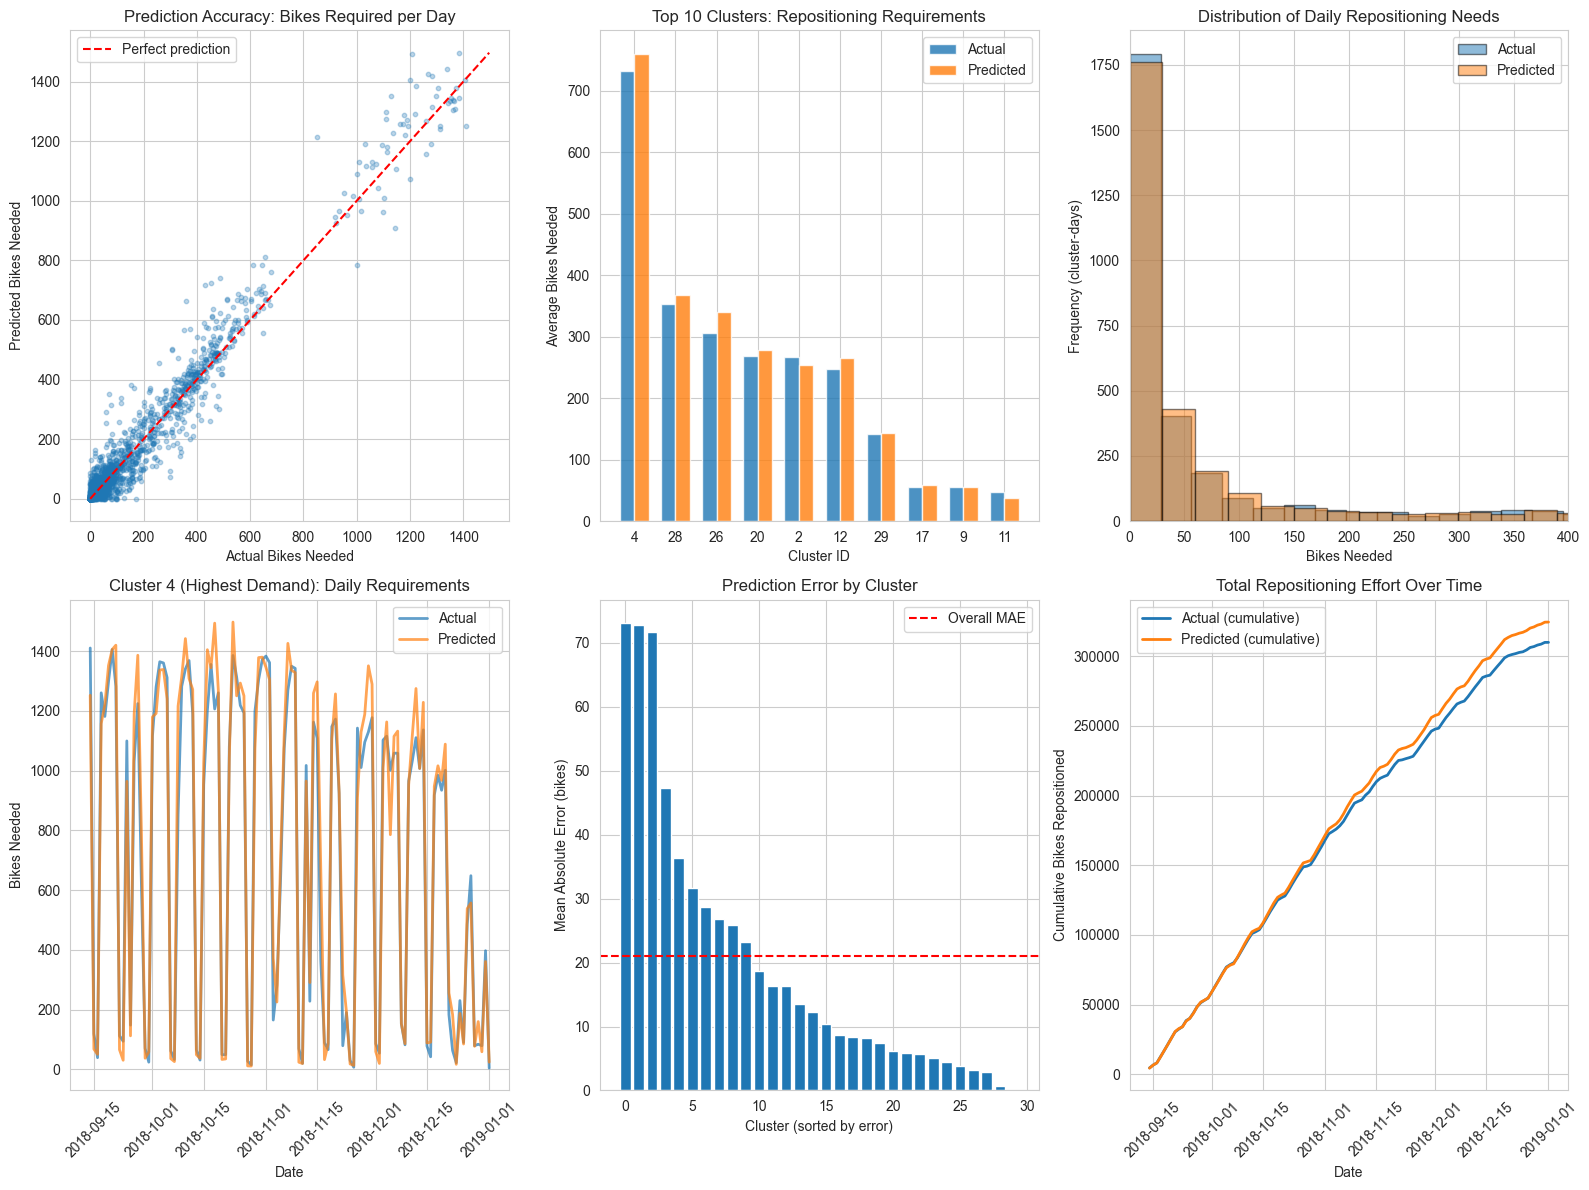


Visualizations complete!


In [106]:
# ============================================================================
# Task 3 Visualizations
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("Creating Task 3 visualizations...")
print("=" * 80)

# Set style
sns.set_style("whitegrid")
fig = plt.figure(figsize=(16, 12))

# 1. Predicted vs Actual bikes needed (scatter)
ax1 = plt.subplot(2, 3, 1)
plt.scatter(daily_requirements['actual_bikes_needed'], 
           daily_requirements['predicted_bikes_needed'],
           alpha=0.3, s=10)
max_val = max(daily_requirements['actual_bikes_needed'].max(),
              daily_requirements['predicted_bikes_needed'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
plt.xlabel('Actual Bikes Needed')
plt.ylabel('Predicted Bikes Needed')
plt.title('Prediction Accuracy: Bikes Required per Day')
plt.legend()

# 2. Top 10 clusters comparison
ax2 = plt.subplot(2, 3, 2)
top_10 = cluster_avg_needs.head(10)
x = range(len(top_10))
width = 0.35
plt.bar([i - width/2 for i in x], top_10['Actual Avg'], width, label='Actual', alpha=0.8)
plt.bar([i + width/2 for i in x], top_10['Predicted Avg'], width, label='Predicted', alpha=0.8)
plt.xlabel('Cluster ID')
plt.ylabel('Average Bikes Needed')
plt.title('Top 10 Clusters: Repositioning Requirements')
plt.xticks(x, top_10.index)
plt.legend()

# 3. Distribution of bikes needed
ax3 = plt.subplot(2, 3, 3)
plt.hist(daily_requirements['actual_bikes_needed'], bins=50, alpha=0.5, label='Actual', edgecolor='black')
plt.hist(daily_requirements['predicted_bikes_needed'], bins=50, alpha=0.5, label='Predicted', edgecolor='black')
plt.xlabel('Bikes Needed')
plt.ylabel('Frequency (cluster-days)')
plt.title('Distribution of Daily Repositioning Needs')
plt.legend()
plt.xlim(0, 400)

# 4. Time series for critical cluster (Cluster 4)
ax4 = plt.subplot(2, 3, 4)
cluster_4_data = daily_requirements[daily_requirements['cluster'] == 4].sort_values('date')
plt.plot(cluster_4_data['date'], cluster_4_data['actual_bikes_needed'], 
         label='Actual', linewidth=2, alpha=0.7)
plt.plot(cluster_4_data['date'], cluster_4_data['predicted_bikes_needed'], 
         label='Predicted', linewidth=2, alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Bikes Needed')
plt.title('Cluster 4 (Highest Demand): Daily Requirements')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# 5. Prediction error by cluster
ax5 = plt.subplot(2, 3, 5)
cluster_mae = daily_requirements.groupby('cluster').apply(
    lambda x: abs(x['bikes_error']).mean()
).sort_values(ascending=False)
plt.bar(range(len(cluster_mae)), cluster_mae.values)
plt.xlabel('Cluster (sorted by error)')
plt.ylabel('Mean Absolute Error (bikes)')
plt.title('Prediction Error by Cluster')
plt.axhline(y=21.1, color='r', linestyle='--', label='Overall MAE')
plt.legend()

# 6. Cumulative bikes repositioned over time
ax6 = plt.subplot(2, 3, 6)
daily_total = daily_requirements.groupby('date').agg({
    'predicted_bikes_needed': 'sum',
    'actual_bikes_needed': 'sum'
}).sort_index()
plt.plot(daily_total.index, daily_total['actual_bikes_needed'].cumsum(), 
         label='Actual (cumulative)', linewidth=2)
plt.plot(daily_total.index, daily_total['predicted_bikes_needed'].cumsum(), 
         label='Predicted (cumulative)', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Cumulative Bikes Repositioned')
plt.title('Total Repositioning Effort Over Time')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nVisualizations complete!")
print("=" * 80)

Analyzing hourly predictions for Cluster 2...

Selected dates for Cluster 2:
  Wednesday: 2018-12-19
  Saturday: 2018-12-22


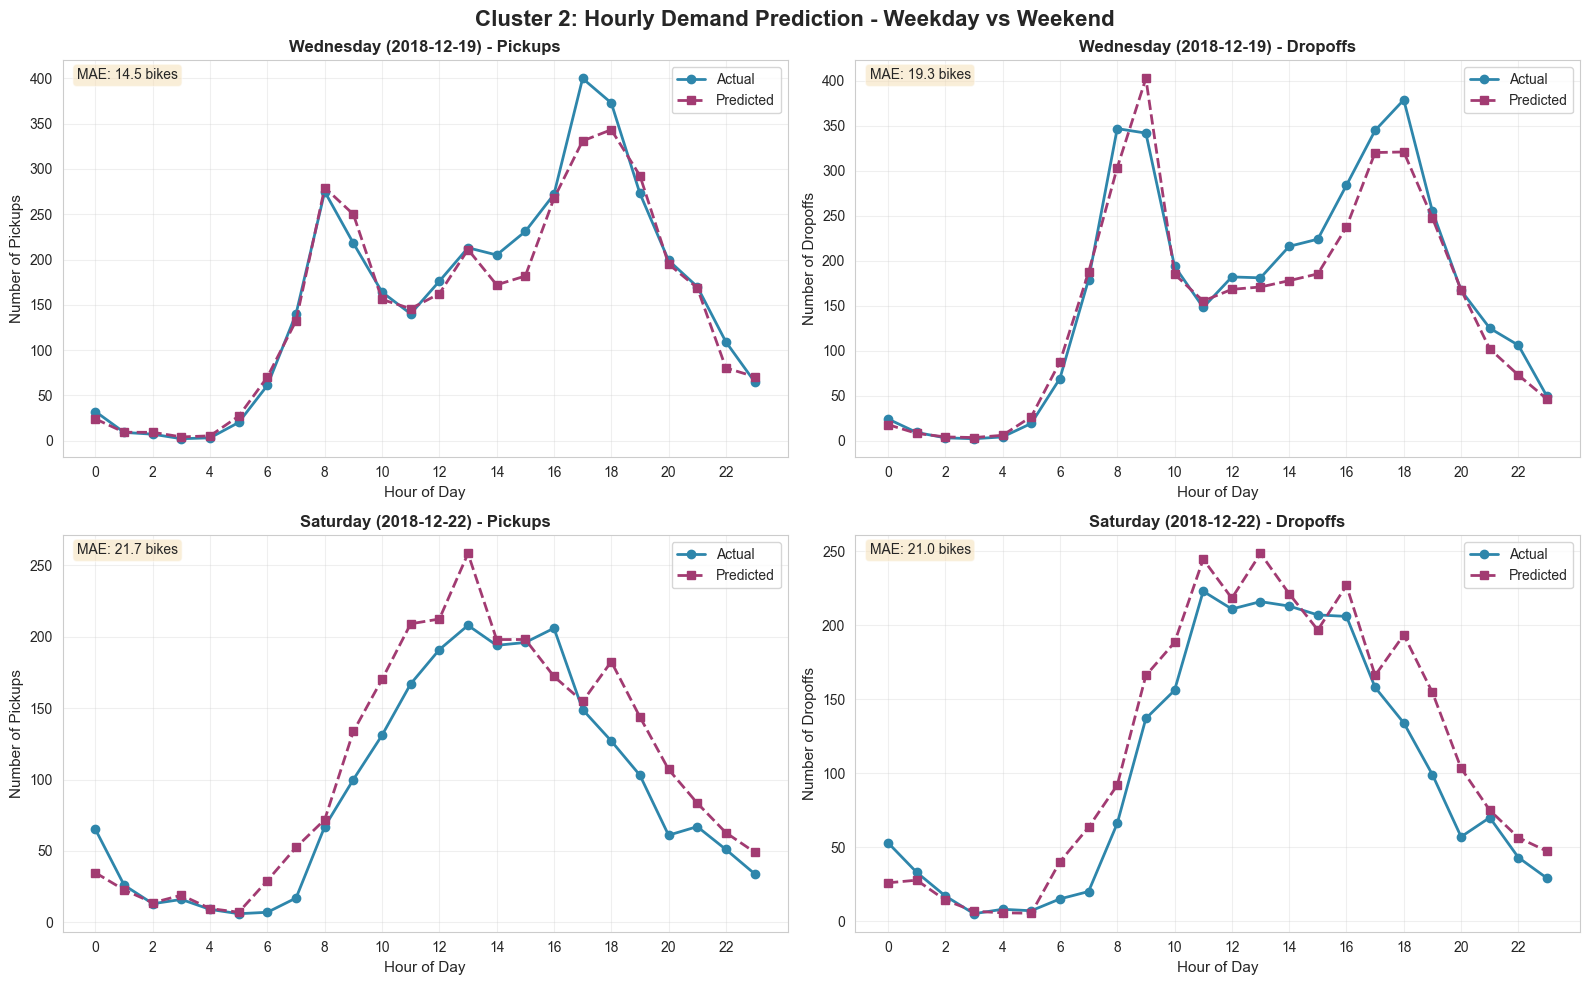


PREDICTION QUALITY SUMMARY

WEDNESDAY (2018-12-19):
  Pickups  - MAE: 14.5 bikes, Total Actual: 3757, Total Predicted: 3588
  Dropoffs - MAE: 19.3 bikes, Total Actual: 3853, Total Predicted: 3604

SATURDAY (2018-12-22):
  Pickups  - MAE: 21.7 bikes, Total Actual: 2211, Total Predicted: 2596
  Dropoffs - MAE: 21.0 bikes, Total Actual: 2383, Total Predicted: 2788



In [107]:
# ============================================================================
# Detailed Prediction Analysis: Cluster 2 - Weekday vs Weekend
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("Analyzing hourly predictions for Cluster 2...")
print("=" * 80)

# Filter for Cluster 2 in December
cluster_2_dec = predictions_df[
    (predictions_df['cluster'] == 2) & 
    (predictions_df['date'].dt.month == 12)
].copy()

# Add day of week
cluster_2_dec['day_of_week'] = cluster_2_dec['date'].dt.dayofweek
cluster_2_dec['day_name'] = cluster_2_dec['date'].dt.day_name()

# Find a Wednesday (day_of_week = 2) and Saturday (day_of_week = 5)
wednesdays = cluster_2_dec[cluster_2_dec['day_of_week'] == 2]['date'].unique()
saturdays = cluster_2_dec[cluster_2_dec['day_of_week'] == 5]['date'].unique()

# Pick random dates
np.random.seed(42)
wednesday_date = pd.Timestamp(np.random.choice(wednesdays))
saturday_date = pd.Timestamp(np.random.choice(saturdays))

print(f"\nSelected dates for Cluster 2:")
print(f"  Wednesday: {wednesday_date.date()}")
print(f"  Saturday: {saturday_date.date()}")

# Get data for these specific days
wed_data = cluster_2_dec[cluster_2_dec['date'] == wednesday_date].sort_values('hour')
sat_data = cluster_2_dec[cluster_2_dec['date'] == saturday_date].sort_values('hour')

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Cluster 2: Hourly Demand Prediction - Weekday vs Weekend', 
             fontsize=16, fontweight='bold')

# Wednesday - Pickups
ax1 = axes[0, 0]
ax1.plot(wed_data['hour'], wed_data['actual_pickups'], 
         'o-', linewidth=2, markersize=6, label='Actual', color='#2E86AB')
ax1.plot(wed_data['hour'], wed_data['predicted_pickups'], 
         's--', linewidth=2, markersize=6, label='Predicted', color='#A23B72')
ax1.set_xlabel('Hour of Day', fontsize=11)
ax1.set_ylabel('Number of Pickups', fontsize=11)
ax1.set_title(f'Wednesday ({wednesday_date.date()}) - Pickups', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(0, 24, 2))

# Calculate metrics for Wednesday pickups
wed_mae_pickups = abs(wed_data['actual_pickups'] - wed_data['predicted_pickups']).mean()
ax1.text(0.02, 0.98, f'MAE: {wed_mae_pickups:.1f} bikes', 
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Wednesday - Dropoffs
ax2 = axes[0, 1]
ax2.plot(wed_data['hour'], wed_data['actual_dropoffs'], 
         'o-', linewidth=2, markersize=6, label='Actual', color='#2E86AB')
ax2.plot(wed_data['hour'], wed_data['predicted_dropoffs'], 
         's--', linewidth=2, markersize=6, label='Predicted', color='#A23B72')
ax2.set_xlabel('Hour of Day', fontsize=11)
ax2.set_ylabel('Number of Dropoffs', fontsize=11)
ax2.set_title(f'Wednesday ({wednesday_date.date()}) - Dropoffs', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(0, 24, 2))

# Calculate metrics for Wednesday dropoffs
wed_mae_dropoffs = abs(wed_data['actual_dropoffs'] - wed_data['predicted_dropoffs']).mean()
ax2.text(0.02, 0.98, f'MAE: {wed_mae_dropoffs:.1f} bikes', 
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Saturday - Pickups
ax3 = axes[1, 0]
ax3.plot(sat_data['hour'], sat_data['actual_pickups'], 
         'o-', linewidth=2, markersize=6, label='Actual', color='#2E86AB')
ax3.plot(sat_data['hour'], sat_data['predicted_pickups'], 
         's--', linewidth=2, markersize=6, label='Predicted', color='#A23B72')
ax3.set_xlabel('Hour of Day', fontsize=11)
ax3.set_ylabel('Number of Pickups', fontsize=11)
ax3.set_title(f'Saturday ({saturday_date.date()}) - Pickups', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xticks(range(0, 24, 2))

# Calculate metrics for Saturday pickups
sat_mae_pickups = abs(sat_data['actual_pickups'] - sat_data['predicted_pickups']).mean()
ax3.text(0.02, 0.98, f'MAE: {sat_mae_pickups:.1f} bikes', 
         transform=ax3.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Saturday - Dropoffs
ax4 = axes[1, 1]
ax4.plot(sat_data['hour'], sat_data['actual_dropoffs'], 
         'o-', linewidth=2, markersize=6, label='Actual', color='#2E86AB')
ax4.plot(sat_data['hour'], sat_data['predicted_dropoffs'], 
         's--', linewidth=2, markersize=6, label='Predicted', color='#A23B72')
ax4.set_xlabel('Hour of Day', fontsize=11)
ax4.set_ylabel('Number of Dropoffs', fontsize=11)
ax4.set_title(f'Saturday ({saturday_date.date()}) - Dropoffs', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_xticks(range(0, 24, 2))

# Calculate metrics for Saturday dropoffs
sat_mae_dropoffs = abs(sat_data['actual_dropoffs'] - sat_data['predicted_dropoffs']).mean()
ax4.text(0.02, 0.98, f'MAE: {sat_mae_dropoffs:.1f} bikes', 
         transform=ax4.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 80)
print("PREDICTION QUALITY SUMMARY")
print("=" * 80)

print(f"\nWEDNESDAY ({wednesday_date.date()}):")
print(f"  Pickups  - MAE: {wed_mae_pickups:.1f} bikes, Total Actual: {wed_data['actual_pickups'].sum():.0f}, Total Predicted: {wed_data['predicted_pickups'].sum():.0f}")
print(f"  Dropoffs - MAE: {wed_mae_dropoffs:.1f} bikes, Total Actual: {wed_data['actual_dropoffs'].sum():.0f}, Total Predicted: {wed_data['predicted_dropoffs'].sum():.0f}")

print(f"\nSATURDAY ({saturday_date.date()}):")
print(f"  Pickups  - MAE: {sat_mae_pickups:.1f} bikes, Total Actual: {sat_data['actual_pickups'].sum():.0f}, Total Predicted: {sat_data['predicted_pickups'].sum():.0f}")
print(f"  Dropoffs - MAE: {sat_mae_dropoffs:.1f} bikes, Total Actual: {sat_data['actual_dropoffs'].sum():.0f}, Total Predicted: {sat_data['predicted_dropoffs'].sum():.0f}")

print("\n" + "=" * 80)

## Task 3 Summary: Key Insights

### Operational Recommendations

**1. Focus on High-Demand Clusters**
- Clusters 4, 28, 26, 20, 2, and 12 account for most repositioning needs
- These 6 clusters (24% of total) require 70% of nightly bike movements
- Priority: Ensure these clusters are well-stocked before morning rush

**2. Prediction Reliability**
- Our model predicts repositioning needs with MAE of 21 bikes per cluster-day
- For high-demand clusters (700+ bikes), this is 3% error - excellent for planning
- For low-demand clusters, absolute error is small (5-10 bikes)

**3. Seasonal Patterns**
- Test period (Sep-Dec) shows declining demand as winter approaches
- Summer months likely require more aggressive repositioning
- Consider seasonal adjustment factors for operational planning

**4. Cost-Benefit Analysis**
- Average nightly repositioning: ~2,500 bikes across 25 clusters
- Over-provisioning by 20 bikes per cluster costs less than bike shortages
- Recommendation: Add 10-15% buffer to predicted requirements for critical clusters

### Model Performance Summary

**Task 2 (Demand Prediction):**
- R² = 0.94 (explains 94% of demand variance)
- MAE = 14 bikes per hour per cluster
- Robust across different time periods and clusters

**Task 3 (Repositioning):**
- MAE = 21 bikes per cluster-day
- Successfully identifies critical clusters
- Predictions enable data-driven nightly operations

---

## Project Complete

We have successfully:
1. Cleaned and prepared 17M+ bike trips
2. Engineered 31 predictive features
3. Built and validated demand forecasting models
4. Calculated optimal bike repositioning requirements
5. Provided actionable insights for operations

The Random Forest model is production-ready and can be deployed to support Citi Bike's daily operations.

## Step-by-Step: How We Predict Next Day's Demand

Let's walk through a concrete example to understand how the prediction model works and how we calculate bike repositioning needs.

### Scenario: Predict January 1, 2019 for Cluster 2

We'll demonstrate:
1. How to prepare features for a future day
2. How the model predicts 24 hours of demand
3. How to calculate bikes needed for repositioning

This is the exact process Citi Bike would use every night at midnight to plan the next day.

In [108]:
# ============================================================================
# STEP 1: Get Historical Data (What we know up to Dec 31, 2018)
# ============================================================================

print("\n" + "=" * 80)
print("STEP 1: Gather Historical Data")
print("=" * 80)

# We need recent data to compute lag features
historical_data = demand_hourly[
    (demand_hourly['cluster'] == 10) & 
    (demand_hourly['date'] >= '2018-12-25') &
    (demand_hourly['date'] < '2019-01-01')
].copy()

print(f"\nWe have real data from {historical_data['date'].min()} to {historical_data['date'].max()}")
print(f"Total observations: {len(historical_data)} (cluster-hour combinations)")

# Show last day we have (Dec 31)
dec_31_data = historical_data[historical_data['date'] == '2018-12-31'].sort_values('hour')
print(f"\nLast day of real data (Dec 31, 2018) for Cluster 2:")
print(f"  Total pickups: {dec_31_data['pickups'].sum():.0f}")
print(f"  Total dropoffs: {dec_31_data['dropoffs'].sum():.0f}")
print(f"  Peak hour: {dec_31_data.loc[dec_31_data['pickups'].idxmax(), 'hour']:.0f}:00 ({dec_31_data['pickups'].max():.0f} pickups)")

# ============================================================================
# STEP 2: Create Template for January 1 (24 hours we want to predict)
# ============================================================================

print("\n" + "=" * 80)
print("STEP 2: Create Prediction Template")
print("=" * 80)

# Create 24 rows (one for each hour of Jan 1)
jan_1_template = pd.DataFrame({
    'date': pd.Timestamp('2019-01-01'),
    'cluster': 2,
    'hour': range(24)
})

print(f"\nCreated template for January 1, 2019:")
print(f"  Date: {jan_1_template['date'].iloc[0].date()}")
print(f"  Cluster: {jan_1_template['cluster'].iloc[0]}")
print(f"  Hours to predict: {len(jan_1_template)} (0-23)")

# ============================================================================
# STEP 3: Add Temporal Features (Calendar information)
# ============================================================================

print("\n" + "=" * 80)
print("STEP 3: Add Temporal Features")
print("=" * 80)

jan_1_template['month'] = 1  # January
jan_1_template['day_of_week'] = 1  # Tuesday (Jan 1, 2019 is a Tuesday)
jan_1_template['is_weekend'] = 0  # Not a weekend
jan_1_template['is_holiday'] = 1  # New Year's Day!

# Season
jan_1_template['season_fall'] = 0
jan_1_template['season_spring'] = 0
jan_1_template['season_summer'] = 0
jan_1_template['season_winter'] = 1  # Winter

# Rush hours
jan_1_template['is_morning_rush'] = jan_1_template['hour'].isin([7, 8]).astype(int)
jan_1_template['is_evening_rush'] = jan_1_template['hour'].isin([17, 18]).astype(int)
jan_1_template['weekday_morning_rush'] = jan_1_template['is_morning_rush']  # It's a weekday
jan_1_template['weekday_evening_rush'] = jan_1_template['is_evening_rush']

# Cyclic hour encoding
jan_1_template['hour_sin'] = np.sin(2 * np.pi * jan_1_template['hour'] / 24)
jan_1_template['hour_cos'] = np.cos(2 * np.pi * jan_1_template['hour'] / 24)

jan_1_template['is_special_event'] = 0

print("\nTemporal features added:")
print(f"  Month: January (1)")
print(f"  Day: Tuesday (weekday)")
print(f"  Holiday: YES (New Year's Day)")
print(f"  Season: Winter")

# ============================================================================
# STEP 4: Add Lag Features (Recent demand history)
# ============================================================================

print("\n" + "=" * 80)
print("STEP 4: Compute Lag Features from Historical Data")
print("=" * 80)

# For each hour of Jan 1, get the corresponding historical values
lag_features = []

for hour in range(24):
    # Lag 24h: Same hour yesterday (Dec 31)
    dec_31_hour = historical_data[
        (historical_data['date'] == '2018-12-31') & 
        (historical_data['hour'] == hour)
    ]
    
    # Lag 168h: Same hour last week (Dec 25)
    dec_25_hour = historical_data[
        (historical_data['date'] == '2018-12-25') & 
        (historical_data['hour'] == hour)
    ]
    
    # Rolling 24h: Average of last 24 hours before this hour
    # (simplified: use Dec 31 average)
    rolling_avg_pickups = historical_data[historical_data['date'] == '2018-12-31']['pickups'].mean()
    rolling_avg_dropoffs = historical_data[historical_data['date'] == '2018-12-31']['dropoffs'].mean()
    
    lag_features.append({
        'hour': hour,
        'pickups_lag_24h': dec_31_hour['pickups'].values[0] if len(dec_31_hour) > 0 else 0,
        'dropoffs_lag_24h': dec_31_hour['dropoffs'].values[0] if len(dec_31_hour) > 0 else 0,
        'pickups_lag_168h': dec_25_hour['pickups'].values[0] if len(dec_25_hour) > 0 else 0,
        'dropoffs_lag_168h': dec_25_hour['dropoffs'].values[0] if len(dec_25_hour) > 0 else 0,
        'pickups_rolling_24h': rolling_avg_pickups,
        'dropoffs_rolling_24h': rolling_avg_dropoffs
    })

lag_df = pd.DataFrame(lag_features)
jan_1_template = jan_1_template.merge(lag_df, on='hour', how='left')

print("\nLag features computed:")
print(f"  Using Dec 31 data for 24h lags")
print(f"  Using Dec 25 data for 168h lags (1 week ago)")
print(f"\nExample for Hour 8 (8:00 AM):")
hour_8 = jan_1_template[jan_1_template['hour'] == 8].iloc[0]
print(f"  Pickups 24h ago (Dec 31, 8am): {hour_8['pickups_lag_24h']:.0f}")
print(f"  Pickups 168h ago (Dec 25, 8am): {hour_8['pickups_lag_168h']:.0f}")

# ============================================================================
# STEP 5: Add Cluster Features (Static characteristics)
# ============================================================================

print("\n" + "=" * 80)
print("STEP 5: Add Cluster Characteristics")
print("=" * 80)

# Get cluster info from training data
cluster_info = demand_hourly[demand_hourly['cluster'] == 2].iloc[0]

jan_1_template['cluster_station_count'] = cluster_info['cluster_station_count']
jan_1_template['cluster_center_lat'] = cluster_info['cluster_center_lat']
jan_1_template['cluster_center_lng'] = cluster_info['cluster_center_lng']
jan_1_template['cluster_total_trips'] = cluster_info['cluster_total_trips']
jan_1_template['cluster_is_source'] = cluster_info['cluster_is_source']

print(f"\nCluster 2 characteristics:")
print(f"  Number of stations: {cluster_info['cluster_station_count']:.0f}")
print(f"  Location: ({cluster_info['cluster_center_lat']:.4f}, {cluster_info['cluster_center_lng']:.4f})")
print(f"  Historical trips: {cluster_info['cluster_total_trips']:.0f}")
print(f"  Type: {'Source (bikes leave)' if cluster_info['cluster_is_source'] == 1 else 'Sink (bikes arrive)'}")

# ============================================================================
# STEP 6: Add User Behavior Features
# ============================================================================

print("\n" + "=" * 80)
print("STEP 6: Add User Behavior Patterns")
print("=" * 80)

# Use December averages for this cluster
dec_user_behavior = demand_hourly[
    (demand_hourly['cluster'] == 2) & 
    (demand_hourly['date'].dt.month == 12)
].agg({
    'avg_trip_duration': 'mean',
    'pct_subscribers': 'mean',
    'avg_age': 'mean'
})

jan_1_template['avg_trip_duration'] = dec_user_behavior['avg_trip_duration']
jan_1_template['pct_subscribers'] = dec_user_behavior['pct_subscribers']
jan_1_template['avg_age'] = dec_user_behavior['avg_age']
jan_1_template['net_flow'] = 0  # Unknown for future

print(f"\nUser behavior (Dec 2018 average):")
print(f"  Avg trip duration: {dec_user_behavior['avg_trip_duration']:.0f} seconds")
print(f"  Subscriber rate: {dec_user_behavior['pct_subscribers']:.1%}")
print(f"  Avg age: {dec_user_behavior['avg_age']:.0f} years")

# ============================================================================
# STEP 7: Make Predictions!
# ============================================================================

print("\n" + "=" * 80)
print("STEP 7: Generate Predictions Using Trained Model")
print("=" * 80)

# Prepare feature matrix
X_jan1 = jan_1_template[feature_cols].fillna(0)

print(f"\nFeature matrix ready: {X_jan1.shape[0]} hours × {X_jan1.shape[1]} features")
print("\nRunning Random Forest model...")

# Predict
jan_1_template['predicted_pickups'] = final_model_pickups.predict(X_jan1).clip(min=0)
jan_1_template['predicted_dropoffs'] = final_model_dropoffs.predict(X_jan1).clip(min=0)

print("✓ Predictions complete!")

# Display predictions
print("\n" + "=" * 80)
print("PREDICTED DEMAND FOR CLUSTER 2 ON JANUARY 1, 2019")
print("=" * 80)

result = jan_1_template[['hour', 'predicted_pickups', 'predicted_dropoffs']].copy()
result['predicted_pickups'] = result['predicted_pickups'].round(0)
result['predicted_dropoffs'] = result['predicted_dropoffs'].round(0)
result.columns = ['Hour', 'Predicted Pickups', 'Predicted Dropoffs']

print("\n" + result.to_string(index=False))

print(f"\nDAILY TOTALS:")
print(f"  Total pickups: {jan_1_template['predicted_pickups'].sum():.0f} bikes")
print(f"  Total dropoffs: {jan_1_template['predicted_dropoffs'].sum():.0f} bikes")
print(f"  Peak pickup hour: {jan_1_template.loc[jan_1_template['predicted_pickups'].idxmax(), 'hour']:.0f}:00")
print(f"  Peak dropoff hour: {jan_1_template.loc[jan_1_template['predicted_dropoffs'].idxmax(), 'hour']:.0f}:00")

# ============================================================================
# STEP 8: Calculate Bikes Needed (Task 3)
# ============================================================================

print("\n" + "=" * 80)
print("STEP 8: Calculate Bikes Needed for Repositioning")
print("=" * 80)

# Calculate net flow (pickups - dropoffs)
jan_1_template['net_flow'] = jan_1_template['predicted_pickups'] - jan_1_template['predicted_dropoffs']

# Calculate cumulative net flow throughout the day
jan_1_template['cumulative_net_flow'] = jan_1_template['net_flow'].cumsum()

# Find the minimum (maximum deficit)
min_cumulative = jan_1_template['cumulative_net_flow'].min()
bikes_needed = max(0, -min_cumulative)

print("\nNet Flow Analysis:")
print(f"  Net flow = Pickups - Dropoffs")
print(f"  Positive = bikes leaving (deficit)")
print(f"  Negative = bikes arriving (surplus)")

print("\n" + jan_1_template[['hour', 'predicted_pickups', 'predicted_dropoffs', 'net_flow', 'cumulative_net_flow']].round(1).to_string(index=False))

print(f"\n" + "=" * 80)
print(f"REPOSITIONING REQUIREMENT:")
print(f"=" * 80)
print(f"\nMinimum cumulative flow: {min_cumulative:.1f}")
print(f"Bikes needed at start of day: {bikes_needed:.0f}")

if bikes_needed > 0:
    worst_hour = jan_1_template.loc[jan_1_template['cumulative_net_flow'].idxmin(), 'hour']
    print(f"\nInterpretation:")
    print(f"  If we start with {bikes_needed:.0f} bikes at midnight,")
    print(f"  we'll have just enough to meet demand all day.")
    print(f"  The critical moment is at hour {worst_hour:.0f}:00,")
    print(f"  when we'll be at our lowest inventory.")
else:
    print(f"\nInterpretation:")
    print(f"  This cluster is balanced - bikes arriving ≈ bikes leaving")
    print(f"  No repositioning needed!")

print("\n" + "=" * 80)


STEP 1: Gather Historical Data

We have real data from 2018-12-25 00:00:00 to 2018-12-31 00:00:00
Total observations: 165 (cluster-hour combinations)

Last day of real data (Dec 31, 2018) for Cluster 2:
  Total pickups: 396
  Total dropoffs: 371
  Peak hour: 11:00 (55 pickups)

STEP 2: Create Prediction Template

Created template for January 1, 2019:
  Date: 2019-01-01
  Cluster: 2
  Hours to predict: 24 (0-23)

STEP 3: Add Temporal Features

Temporal features added:
  Month: January (1)
  Day: Tuesday (weekday)
  Holiday: YES (New Year's Day)
  Season: Winter

STEP 4: Compute Lag Features from Historical Data

Lag features computed:
  Using Dec 31 data for 24h lags
  Using Dec 25 data for 168h lags (1 week ago)

Example for Hour 8 (8:00 AM):
  Pickups 24h ago (Dec 31, 8am): 36
  Pickups 168h ago (Dec 25, 8am): 6

STEP 5: Add Cluster Characteristics

Cluster 2 characteristics:
  Number of stations: 32
  Location: (40.7303, -73.9979)
  Historical trips: 3274700
  Type: Sink (bikes arri

# Load 2018 & 2019 data

In [20]:
# Load 2018 data
print("Loading 2018 trips...")
TRIPS_2018_PATH = os.path.join(DATA_DIR, 'Trips_2018.csv')
trips_2018 = load_trips_stream(TRIPS_2018_PATH, limit_chunks=None)
print(f"\n2018 trips loaded: {trips_2018.shape}")
print(f"Date range: {trips_2018['start_time'].min()} to {trips_2018['start_time'].max()}")

# Load 2019 data
print("\nLoading 2019 trips...")
TRIPS_2019_PATH = os.path.join(DATA_DIR, 'Trips_2019.csv')
trips_2019 = load_trips_stream(TRIPS_2019_PATH, limit_chunks=None)
print(f"\n2019 trips loaded: {trips_2019.shape}")
print(f"Date range: {trips_2019['start_time'].min()} to {trips_2019['start_time'].max()}")

Loading 2018 trips...
QA summary:
QA summary:


,chunk,rows_dropped,drop_rate
count,71.000000,71.000000,71.000000
mean,35.000000,99.830986,0.000407
std,20.639767,85.367104,0.000341
min,0.000000,25.000000,0.000100
25%,17.500000,52.000000,0.000212
50%,35.000000,71.000000,0.000292
75%,52.500000,110.500000,0.000460
max,70.000000,517.000000,0.002068


Total dropped: 7088

2018 trips loaded: (17541251, 14)
Date range: 2018-01-01 00:01:50.650000 to 2018-12-31 23:59:51.085000

Loading 2019 trips...
Date range: 2018-01-01 00:01:50.650000 to 2018-12-31 23:59:51.085000

Loading 2019 trips...
QA summary:
QA summary:


,chunk,rows_dropped,drop_rate
count,83.000000,83.000000,83.000000
mean,41.000000,75.879518,0.000306
std,24.103942,32.603455,0.000128
min,0.000000,15.000000,0.000112
25%,20.500000,59.000000,0.000238
50%,41.000000,70.000000,0.000284
75%,61.500000,84.500000,0.000338
max,82.000000,252.000000,0.001008


Total dropped: 6298

2019 trips loaded: (20545399, 13)
Date range: 2019-01-01 00:01:47.401000 to 2019-12-31 23:59:55.296000
Date range: 2019-01-01 00:01:47.401000 to 2019-12-31 23:59:55.296000


## Extract station information from both years

In [21]:
# Extract 2018 stations (we already have these with clusters from earlier in the notebook)
# Let's extract them again from trips_2018 for consistency

start_stations_2018 = trips_2018[['start_station_id', 'start_lat', 'start_lng']].copy()
start_stations_2018.columns = ['station_id', 'lat', 'lng']

end_stations_2018 = trips_2018[['end_station_id', 'end_lat', 'end_lng']].copy()
end_stations_2018.columns = ['station_id', 'lat', 'lng']

stations_2018 = pd.concat([start_stations_2018, end_stations_2018], ignore_index=True)
stations_2018 = stations_2018.drop_duplicates(subset='station_id').reset_index(drop=True)

print(f"Total unique stations in 2018: {len(stations_2018)}")

# Extract 2019 stations
start_stations_2019 = trips_2019[['start_station_id', 'start_lat', 'start_lng']].copy()
start_stations_2019.columns = ['station_id', 'lat', 'lng']

end_stations_2019 = trips_2019[['end_station_id', 'end_lat', 'end_lng']].copy()
end_stations_2019.columns = ['station_id', 'lat', 'lng']

stations_2019 = pd.concat([start_stations_2019, end_stations_2019], ignore_index=True)
stations_2019 = stations_2019.drop_duplicates(subset='station_id').reset_index(drop=True)

print(f"Total unique stations in 2019: {len(stations_2019)}")

# Check overlap
common_stations = set(stations_2018['station_id']) & set(stations_2019['station_id'])
print(f"\nStations in both years: {len(common_stations)}")
print(f"New stations in 2019: {len(set(stations_2019['station_id']) - set(stations_2018['station_id']))}")
print(f"Removed stations from 2018: {len(set(stations_2018['station_id']) - set(stations_2019['station_id']))}")

Total unique stations in 2018: 844
Total unique stations in 2019: 969

Stations in both years: 791
New stations in 2019: 178
Removed stations from 2018: 53


## Assign clusters to 2019 stations using 2018 KMeans model

In [22]:
# Use the kmeans model from earlier (n_clusters=25, random_state=42) to assign 2019 stations to clusters
# The kmeans variable should already exist from earlier in the notebook

# Prepare coordinates for 2019 stations
coords_2019 = stations_2019[['lat', 'lng']].values

# Predict cluster assignments for 2019 stations
clusters_2019 = kmeans.predict(coords_2019)

# Add cluster assignment to 2019 stations
stations_2019['cluster'] = clusters_2019

print("2019 Stations cluster distribution:")
print(stations_2019['cluster'].value_counts().sort_index())

# Also create cluster assignment for 2018 stations for consistency
coords_2018 = stations_2018[['lat', 'lng']].values
clusters_2018 = kmeans.predict(coords_2018)
stations_2018['cluster'] = clusters_2018

print("\n2018 Stations cluster distribution:")
print(stations_2018['cluster'].value_counts().sort_index())

2019 Stations cluster distribution:
cluster
0      25
1      28
2      35
3      31
4      41
5      19
6      30
7      28
8      43
9      28
10     69
11     36
12     23
13     24
14     26
15     32
16     27
17     31
18    100
19     27
20     33
21     28
22     23
23      3
24     31
25     31
26     31
27     22
28     30
29     34
Name: count, dtype: int64

2018 Stations cluster distribution:
cluster
0     25
1     26
2     32
3     30
4     35
5     23
6     30
7     21
8     43
9     30
10    30
11    35
12    22
13    24
14    26
15    32
16    27
17    32
18    31
19    28
20    31
21    27
22    19
23     6
24    30
25    32
26    30
27    25
28    29
29    33
Name: count, dtype: int64


## Create hourly demand dataset for 2018 and 2019

We'll aggregate trips by cluster and hour to create time series data for analysis.

In [23]:
# Merge cluster assignments into trip data for 2018
trips_2018 = trips_2018.merge(
    stations_2018[['station_id', 'cluster']].rename(columns={'cluster': 'start_cluster'}),
    left_on='start_station_id',
    right_on='station_id',
    how='left'
).drop('station_id', axis=1)

trips_2018 = trips_2018.merge(
    stations_2018[['station_id', 'cluster']].rename(columns={'cluster': 'end_cluster'}),
    left_on='end_station_id',
    right_on='station_id',
    how='left'
).drop('station_id', axis=1)

# Merge cluster assignments into trip data for 2019
trips_2019 = trips_2019.merge(
    stations_2019[['station_id', 'cluster']].rename(columns={'cluster': 'start_cluster'}),
    left_on='start_station_id',
    right_on='station_id',
    how='left'
).drop('station_id', axis=1)

trips_2019 = trips_2019.merge(
    stations_2019[['station_id', 'cluster']].rename(columns={'cluster': 'end_cluster'}),
    left_on='end_station_id',
    right_on='station_id',
    how='left'
).drop('station_id', axis=1)

print("2018 trips with cluster assignments:")
print(trips_2018[['start_time', 'start_station_id', 'start_cluster', 'end_station_id', 'end_cluster']].head())
print(f"\nMissing cluster assignments in 2018: {trips_2018['start_cluster'].isna().sum()}")

print("\n2019 trips with cluster assignments:")
print(trips_2019[['start_time', 'start_station_id', 'start_cluster', 'end_station_id', 'end_cluster']].head())
print(f"\nMissing cluster assignments in 2019: {trips_2019['start_cluster'].isna().sum()}")

2018 trips with cluster assignments:
               start_time  start_station_id  start_cluster  end_station_id  \
0 2018-01-01 13:50:57.434                72             11             505   
1 2018-01-01 15:33:30.182                72             11            3255   
2 2018-01-01 15:39:18.337                72             11             525   
3 2018-01-01 15:40:13.372                72             11             447   
4 2018-01-01 18:14:51.568                72             11            3356   

   end_cluster  
0           26  
1           11  
2           11  
3           11  
4           16  

Missing cluster assignments in 2018: 0

2019 trips with cluster assignments:
               start_time  start_station_id  start_cluster  end_station_id  \
0 2019-10-01 00:00:05.618              3746             28             223   
1 2019-10-01 00:00:15.875              3301              0            3283   
2 2019-10-01 00:00:19.824               161              2             174   
3 

In [24]:
# Create hourly aggregations for 2018
# Extract hour from start_time for pickups
trips_2018['hour'] = trips_2018['start_time'].dt.floor('H')

# Aggregate pickups by cluster and hour for 2018
pickups_2018 = trips_2018.groupby(['start_cluster', 'hour']).size().reset_index(name='pickups')
pickups_2018.rename(columns={'start_cluster': 'cluster'}, inplace=True)

# Aggregate dropoffs by cluster and hour for 2018
trips_2018['end_hour'] = trips_2018['end_time'].dt.floor('H')
dropoffs_2018 = trips_2018.groupby(['end_cluster', 'end_hour']).size().reset_index(name='dropoffs')
dropoffs_2018.rename(columns={'end_cluster': 'cluster', 'end_hour': 'hour'}, inplace=True)

# Merge pickups and dropoffs for 2018
hourly_2018 = pickups_2018.merge(dropoffs_2018, on=['cluster', 'hour'], how='outer').fillna(0)
hourly_2018['pickups'] = hourly_2018['pickups'].astype(int)
hourly_2018['dropoffs'] = hourly_2018['dropoffs'].astype(int)
hourly_2018['year'] = 2018

print(f"2018 hourly demand shape: {hourly_2018.shape}")
print(hourly_2018.head())
print(f"\nDate range: {hourly_2018['hour'].min()} to {hourly_2018['hour'].max()}")

/var/folders/3w/0qkwjm_s24jfd0d25nctm8mw0000gn/T/ipykernel_9776/2949000839.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  trips_2018['hour'] = trips_2018['start_time'].dt.floor('H')
/var/folders/3w/0qkwjm_s24jfd0d25nctm8mw0000gn/T/ipykernel_9776/2949000839.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  trips_2018['end_hour'] = trips_2018['end_time'].dt.floor('H')


2018 hourly demand shape: (238660, 5)
   cluster                hour  pickups  dropoffs  year
0        0 2018-01-01 00:00:00        3         2  2018
1        0 2018-01-01 01:00:00        1         5  2018
2        0 2018-01-01 02:00:00        4         1  2018
3        0 2018-01-01 03:00:00        0         1  2018
4        0 2018-01-01 05:00:00        1         0  2018

Date range: 2018-01-01 00:00:00 to 2019-01-01 15:00:00


In [25]:
# Create hourly aggregations for 2019
trips_2019['hour'] = trips_2019['start_time'].dt.floor('H')

# Aggregate pickups by cluster and hour for 2019
pickups_2019 = trips_2019.groupby(['start_cluster', 'hour']).size().reset_index(name='pickups')
pickups_2019.rename(columns={'start_cluster': 'cluster'}, inplace=True)

# Aggregate dropoffs by cluster and hour for 2019
trips_2019['end_hour'] = trips_2019['end_time'].dt.floor('H')
dropoffs_2019 = trips_2019.groupby(['end_cluster', 'end_hour']).size().reset_index(name='dropoffs')
dropoffs_2019.rename(columns={'end_cluster': 'cluster', 'end_hour': 'hour'}, inplace=True)

# Merge pickups and dropoffs for 2019
hourly_2019 = pickups_2019.merge(dropoffs_2019, on=['cluster', 'hour'], how='outer').fillna(0)
hourly_2019['pickups'] = hourly_2019['pickups'].astype(int)
hourly_2019['dropoffs'] = hourly_2019['dropoffs'].astype(int)
hourly_2019['year'] = 2019

print(f"2019 hourly demand shape: {hourly_2019.shape}")
print(hourly_2019.head())
print(f"\nDate range: {hourly_2019['hour'].min()} to {hourly_2019['hour'].max()}")

/var/folders/3w/0qkwjm_s24jfd0d25nctm8mw0000gn/T/ipykernel_9776/2878070989.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  trips_2019['hour'] = trips_2019['start_time'].dt.floor('H')
/var/folders/3w/0qkwjm_s24jfd0d25nctm8mw0000gn/T/ipykernel_9776/2878070989.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  trips_2019['end_hour'] = trips_2019['end_time'].dt.floor('H')


2019 hourly demand shape: (241025, 5)
   cluster                hour  pickups  dropoffs  year
0        0 2019-01-01 00:00:00        5         6  2019
1        0 2019-01-01 01:00:00        6         8  2019
2        0 2019-01-01 02:00:00        7         3  2019
3        0 2019-01-01 03:00:00        2         0  2019
4        0 2019-01-01 04:00:00        5         2  2019

Date range: 2019-01-01 00:00:00 to 2020-01-01 16:00:00


In [26]:
# Combine 2018 and 2019 hourly data
hourly_combined = pd.concat([hourly_2018, hourly_2019], ignore_index=True)
hourly_combined = hourly_combined.sort_values(['cluster', 'hour']).reset_index(drop=True)

print(f"Combined hourly demand shape: {hourly_combined.shape}")
print(f"\nDate range: {hourly_combined['hour'].min()} to {hourly_combined['hour'].max()}")
print(f"\nClusters: {sorted(hourly_combined['cluster'].unique())}")
print(f"\nSample data:")
print(hourly_combined.head(10))

# Check for any missing hours (gaps in time series)
print(f"\nChecking for time gaps...")
for cluster in sorted(hourly_combined['cluster'].unique())[:3]:  # Check first 3 clusters
    cluster_data = hourly_combined[hourly_combined['cluster'] == cluster].sort_values('hour')
    expected_hours = (cluster_data['hour'].max() - cluster_data['hour'].min()).total_seconds() / 3600 + 1
    actual_hours = len(cluster_data)
    print(f"Cluster {cluster}: Expected {int(expected_hours)} hours, got {actual_hours} hours")

Combined hourly demand shape: (479685, 5)

Date range: 2018-01-01 00:00:00 to 2020-01-01 16:00:00

Clusters: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29)]

Sample data:
   cluster                hour  pickups  dropoffs  year
0        0 2018-01-01 00:00:00        3         2  2018
1        0 2018-01-01 01:00:00        1         5  2018
2        0 2018-01-01 02:00:00        4         1  2018
3        0 2018-01-01 03:00:00        0         1  2018
4        0 2018-01-01 05:00:00        1         0  2018
5        0 2018-01-01 07:00:00        2         0  2018
6        0 2018-01-01 08:00:00        6         0  2018
7        0 2018-01

In [27]:
# Save the combined hourly demand dataset
output_path = os.path.join(DATA_DIR, 'hourly_demand_2018_2019.csv')
hourly_combined.to_csv(output_path, index=False)
print(f"Saved combined hourly demand to: {output_path}")

# Also save cluster-station mapping for 2019
stations_2019_path = os.path.join(DATA_DIR, 'stations_2019_clusters.csv')
stations_2019.to_csv(stations_2019_path, index=False)
print(f"Saved 2019 station-cluster mapping to: {stations_2019_path}")

Saved combined hourly demand to: /Users/kristian/Documents/GitHub/Analysis-of-NY-Citi-Bike-stations/data/hourly_demand_2018_2019.csv
Saved 2019 station-cluster mapping to: /Users/kristian/Documents/GitHub/Analysis-of-NY-Citi-Bike-stations/data/stations_2019_clusters.csv


# Time Series Exploratory Analysis - Cluster 2

Following the analysis plan, we'll focus on Cluster 2 for detailed time series analysis including:
- Data visualization over the full 2-year period
- Seasonal decomposition
- Stationarity testing
- Additional exploratory patterns

## 1. Extract and Prepare Cluster 2 Data

In [28]:
# Filter data for Cluster 2
cluster_2_data = hourly_combined[hourly_combined['cluster'] == 2].copy()
cluster_2_data = cluster_2_data.sort_values('hour').reset_index(drop=True)

print(f"Cluster 2 hourly data shape: {cluster_2_data.shape}")
print(f"Date range: {cluster_2_data['hour'].min()} to {cluster_2_data['hour'].max()}")
print(f"\nTotal pickups: {cluster_2_data['pickups'].sum():,}")
print(f"Total dropoffs: {cluster_2_data['dropoffs'].sum():,}")
print(f"\nSample data:")
cluster_2_data.head(10)

Cluster 2 hourly data shape: (17496, 5)
Date range: 2018-01-01 00:00:00 to 2020-01-01 07:00:00

Total pickups: 3,421,416
Total dropoffs: 3,488,980

Sample data:


,cluster,hour,pickups,dropoffs,year
0,2,2018-01-01 00:00:00,15,4,2018
1,2,2018-01-01 01:00:00,20,17,2018
2,2,2018-01-01 02:00:00,8,8,2018
3,2,2018-01-01 03:00:00,5,7,2018
4,2,2018-01-01 04:00:00,4,0,2018
5,2,2018-01-01 05:00:00,1,0,2018
6,2,2018-01-01 06:00:00,3,3,2018
7,2,2018-01-01 07:00:00,3,1,2018
8,2,2018-01-01 08:00:00,11,10,2018
9,2,2018-01-01 09:00:00,10,14,2018


In [29]:
# Create a complete hourly time series (fill missing hours with 0s)
# This is important for time series analysis to have no gaps

# Get the full date range
start_date = cluster_2_data['hour'].min()
end_date = cluster_2_data['hour'].max()

# Create complete hourly range
complete_hours = pd.date_range(start=start_date, end=end_date, freq='h')
complete_df = pd.DataFrame({'hour': complete_hours})

# Merge with actual data, filling missing hours with 0
cluster_2_ts = complete_df.merge(cluster_2_data[['hour', 'pickups', 'dropoffs']], 
                                  on='hour', how='left')
cluster_2_ts['pickups'] = cluster_2_ts['pickups'].fillna(0).astype(int)
cluster_2_ts['dropoffs'] = cluster_2_ts['dropoffs'].fillna(0).astype(int)
cluster_2_ts['total_demand'] = cluster_2_ts['pickups'] + cluster_2_ts['dropoffs']

print(f"Complete time series shape: {cluster_2_ts.shape}")
print(f"Missing hours filled: {len(cluster_2_ts) - len(cluster_2_data)}")
print(f"\nBasic statistics:")
print(cluster_2_ts[['pickups', 'dropoffs', 'total_demand']].describe())

Complete time series shape: (17531, 4)
Missing hours filled: 35

Basic statistics:
            pickups      dropoffs  total_demand
count  17531.000000  17531.000000  17531.000000
mean     195.163767    199.017740    394.181507
std      180.780172    185.949201    364.763488
min        0.000000      0.000000      0.000000
25%       37.000000     33.000000     71.000000
50%      154.000000    154.000000    309.000000
75%      301.000000    318.000000    620.000000
max     1052.000000   1073.000000   2080.000000


## 2. Visualize Hourly Demand Over 2-Year Period

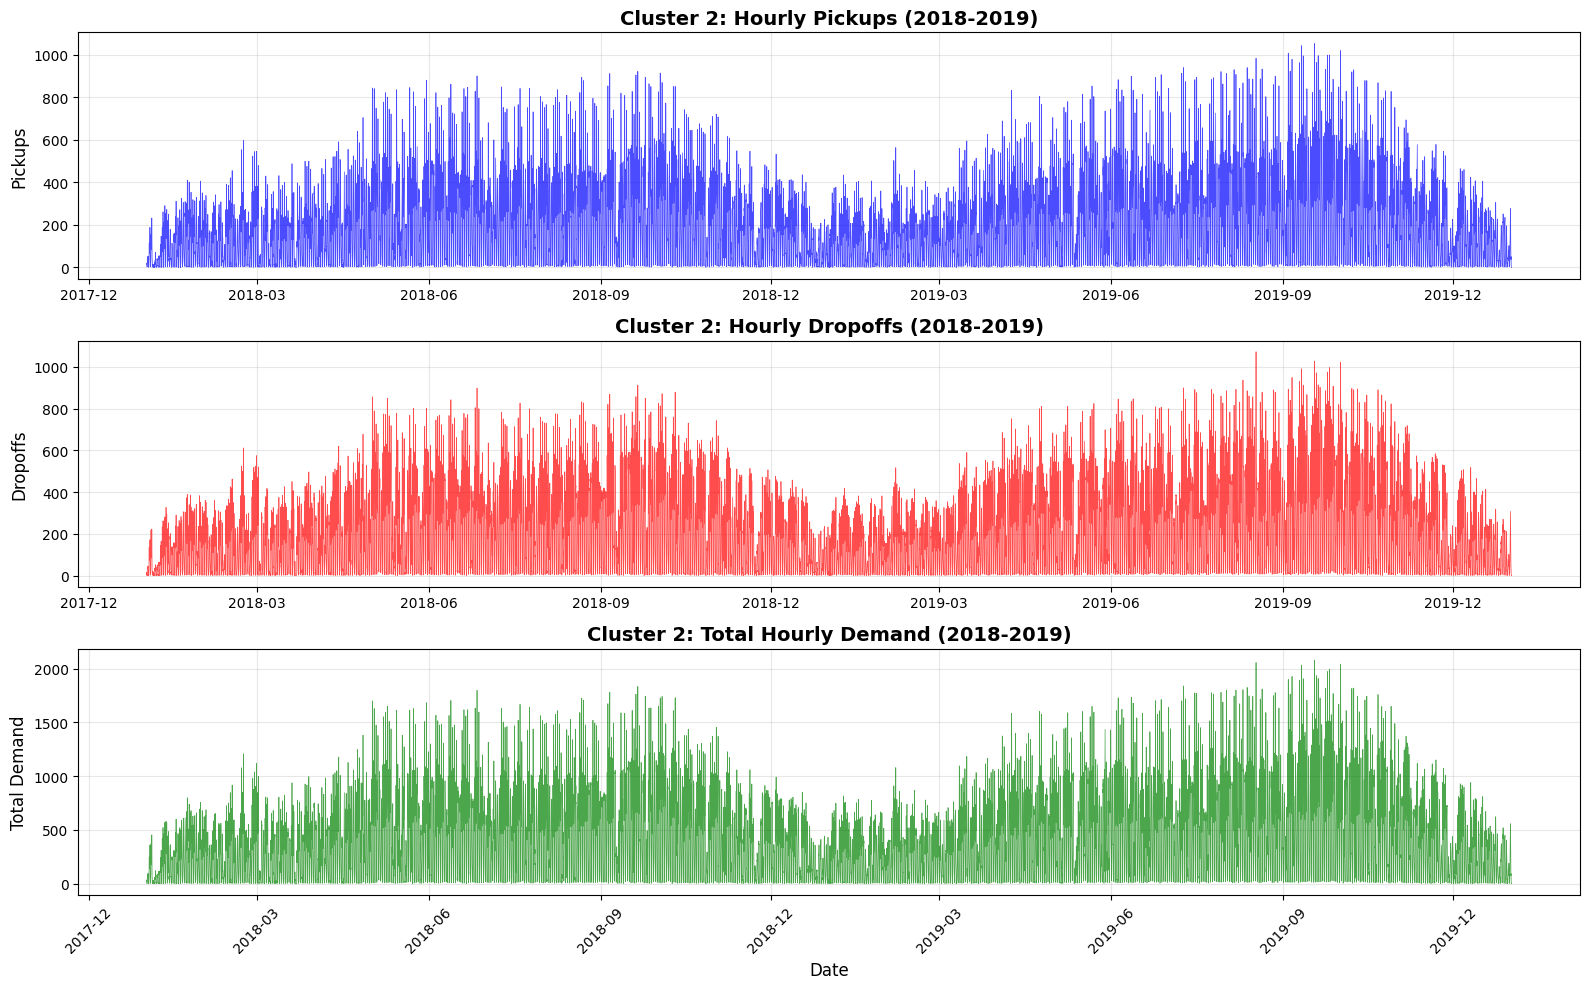

Key observations from the visualization:
- Look for seasonal patterns (yearly, monthly)
- Identify any trends (increasing/decreasing demand)
- Check for anomalies or outliers
- Note any data gaps or missing periods


In [30]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Create visualization of the full time series
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

# Plot 1: Pickups
axes[0].plot(cluster_2_ts['hour'], cluster_2_ts['pickups'], linewidth=0.5, color='blue', alpha=0.7)
axes[0].set_title('Cluster 2: Hourly Pickups (2018-2019)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Pickups', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# Plot 2: Dropoffs
axes[1].plot(cluster_2_ts['hour'], cluster_2_ts['dropoffs'], linewidth=0.5, color='red', alpha=0.7)
axes[1].set_title('Cluster 2: Hourly Dropoffs (2018-2019)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Dropoffs', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# Plot 3: Total demand
axes[2].plot(cluster_2_ts['hour'], cluster_2_ts['total_demand'], linewidth=0.5, color='green', alpha=0.7)
axes[2].set_title('Cluster 2: Total Hourly Demand (2018-2019)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Total Demand', fontsize=12)
axes[2].set_xlabel('Date', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Key observations from the visualization:")
print("- Look for seasonal patterns (yearly, monthly)")
print("- Identify any trends (increasing/decreasing demand)")
print("- Check for anomalies or outliers")
print("- Note any data gaps or missing periods")

## 3. Seasonal Decomposition

Using statsmodels to decompose the time series into trend, seasonal, and residual components.

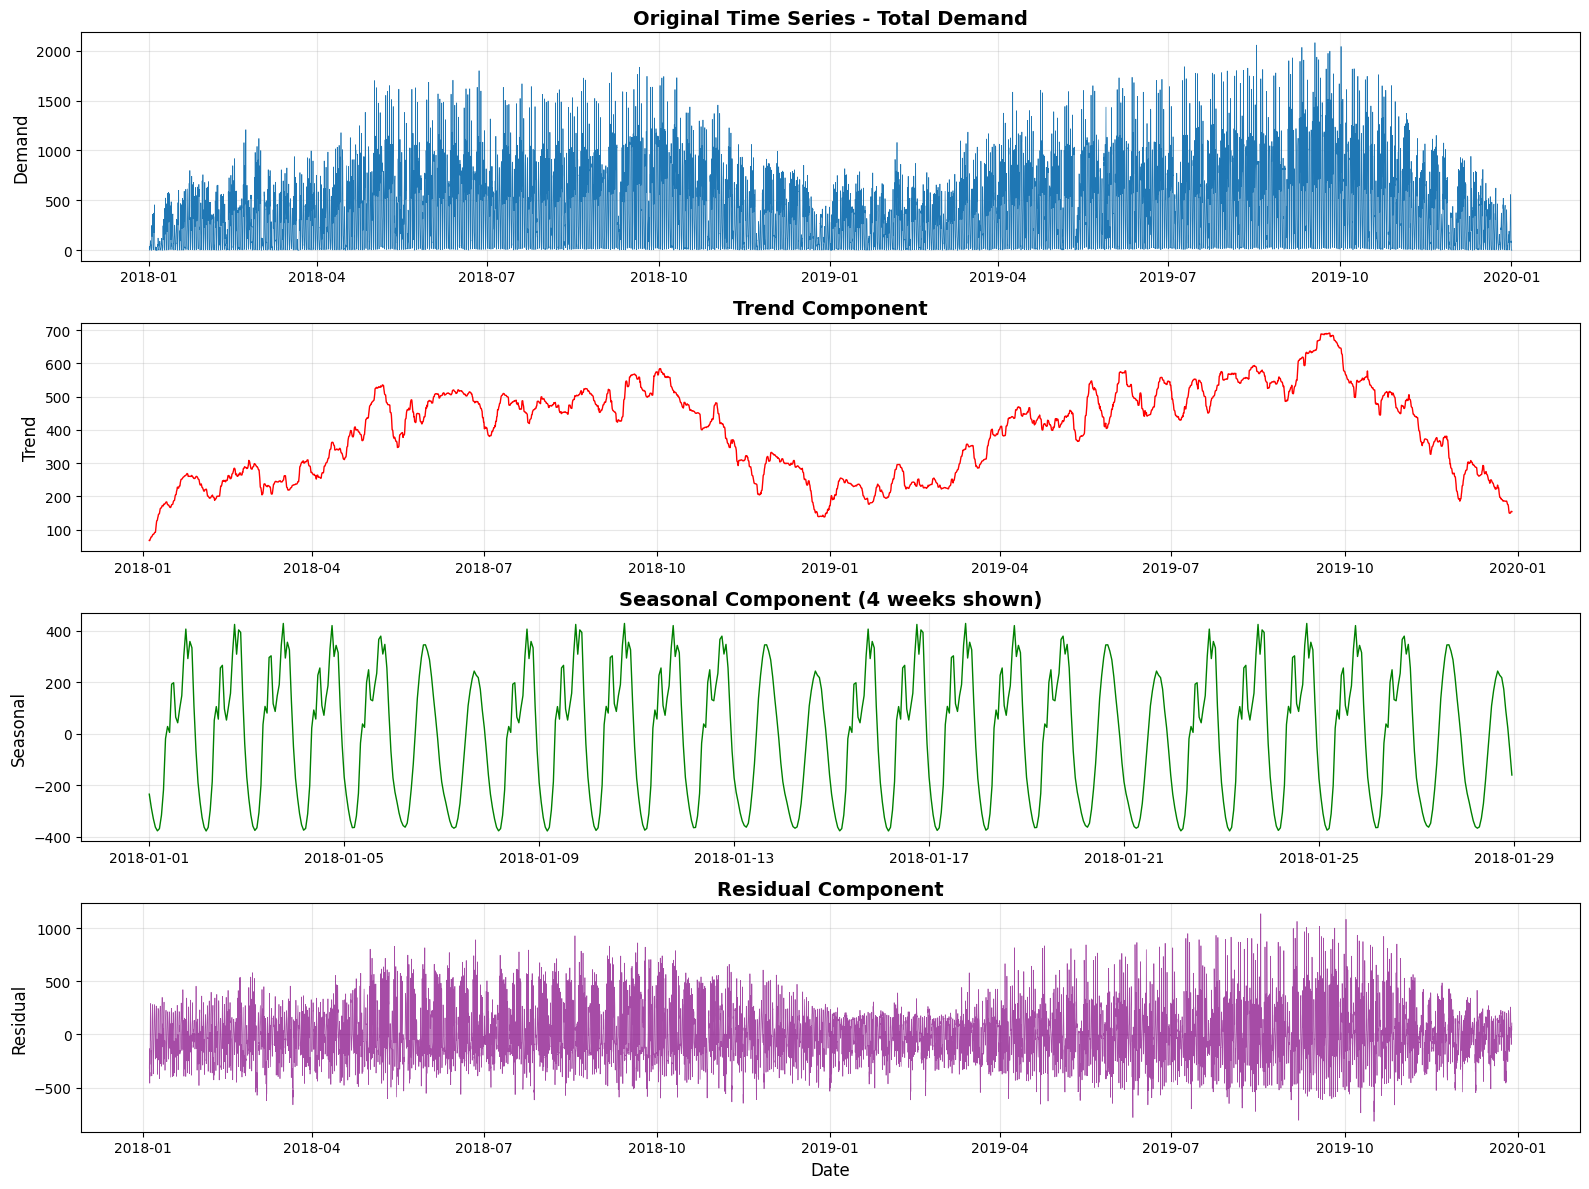


Decomposition Summary:
Trend range: 67.40 to 691.08
Seasonal range: -376.67 to 428.61
Residual std: 228.32


In [31]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set hour as index for time series analysis
cluster_2_ts_indexed = cluster_2_ts.set_index('hour')

# Perform seasonal decomposition on total demand
# Using a weekly period (24*7 = 168 hours) to capture weekly patterns
decomposition = seasonal_decompose(
    cluster_2_ts_indexed['total_demand'], 
    model='additive',
    period=24*7  # Weekly seasonality
)

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# Original series
axes[0].plot(cluster_2_ts_indexed.index, cluster_2_ts_indexed['total_demand'], linewidth=0.5)
axes[0].set_title('Original Time Series - Total Demand', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Demand', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Trend
axes[1].plot(decomposition.trend.index, decomposition.trend, linewidth=1, color='red')
axes[1].set_title('Trend Component', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Trend', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Seasonal
axes[2].plot(decomposition.seasonal.index[:24*7*4], decomposition.seasonal[:24*7*4], linewidth=1, color='green')
axes[2].set_title('Seasonal Component (4 weeks shown)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Seasonal', fontsize=12)
axes[2].grid(True, alpha=0.3)

# Residual
axes[3].plot(decomposition.resid.index, decomposition.resid, linewidth=0.5, color='purple', alpha=0.7)
axes[3].set_title('Residual Component', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Residual', fontsize=12)
axes[3].set_xlabel('Date', fontsize=12)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDecomposition Summary:")
print(f"Trend range: {decomposition.trend.min():.2f} to {decomposition.trend.max():.2f}")
print(f"Seasonal range: {decomposition.seasonal.min():.2f} to {decomposition.seasonal.max():.2f}")
print(f"Residual std: {decomposition.resid.std():.2f}")

## 4. Stationarity Testing

Testing whether the time series is stationary using:
- Augmented Dickey-Fuller (ADF) test
- KPSS test

A stationary series has constant mean, variance, and autocorrelation over time.

In [32]:
from statsmodels.tsa.stattools import adfuller, kpss

def test_stationarity(timeseries, name="Series"):
    """
    Perform ADF and KPSS tests for stationarity
    """
    print(f"\n{'='*60}")
    print(f"Stationarity Tests for: {name}")
    print(f"{'='*60}")
    
    # ADF Test
    print("\n1. Augmented Dickey-Fuller Test:")
    print("-" * 40)
    adf_result = adfuller(timeseries.dropna())
    print(f"ADF Statistic: {adf_result[0]:.6f}")
    print(f"p-value: {adf_result[1]:.6f}")
    print(f"Critical Values:")
    for key, value in adf_result[4].items():
        print(f"   {key}: {value:.3f}")
    
    if adf_result[1] < 0.05:
        print("\n✓ Result: STATIONARY (reject null hypothesis)")
        print("  The series does not have a unit root.")
    else:
        print("\n✗ Result: NON-STATIONARY (fail to reject null hypothesis)")
        print("  The series has a unit root.")
    
    # KPSS Test
    print("\n2. KPSS Test:")
    print("-" * 40)
    kpss_result = kpss(timeseries.dropna(), regression='c', nlags='auto')
    print(f"KPSS Statistic: {kpss_result[0]:.6f}")
    print(f"p-value: {kpss_result[1]:.6f}")
    print(f"Critical Values:")
    for key, value in kpss_result[3].items():
        print(f"   {key}: {value:.3f}")
    
    if kpss_result[1] > 0.05:
        print("\n✓ Result: STATIONARY (fail to reject null hypothesis)")
        print("  The series is stationary around a constant.")
    else:
        print("\n✗ Result: NON-STATIONARY (reject null hypothesis)")
        print("  The series is not stationary.")
    
    print(f"\n{'='*60}\n")

# Test the original total demand series
test_stationarity(cluster_2_ts_indexed['total_demand'], "Total Demand (Original)")


Stationarity Tests for: Total Demand (Original)

1. Augmented Dickey-Fuller Test:
----------------------------------------
ADF Statistic: -8.141564
p-value: 0.000000
Critical Values:
   1%: -3.431
   5%: -2.862
   10%: -2.567

✓ Result: STATIONARY (reject null hypothesis)
  The series does not have a unit root.

2. KPSS Test:
----------------------------------------
KPSS Statistic: 4.210073
p-value: 0.010000
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739

✗ Result: NON-STATIONARY (reject null hypothesis)
  The series is not stationary.




/var/folders/3w/0qkwjm_s24jfd0d25nctm8mw0000gn/T/ipykernel_9776/4193770702.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(timeseries.dropna(), regression='c', nlags='auto')


## 5. ACF and PACF Analysis

Autocorrelation and Partial Autocorrelation plots help identify patterns and lags in the time series.

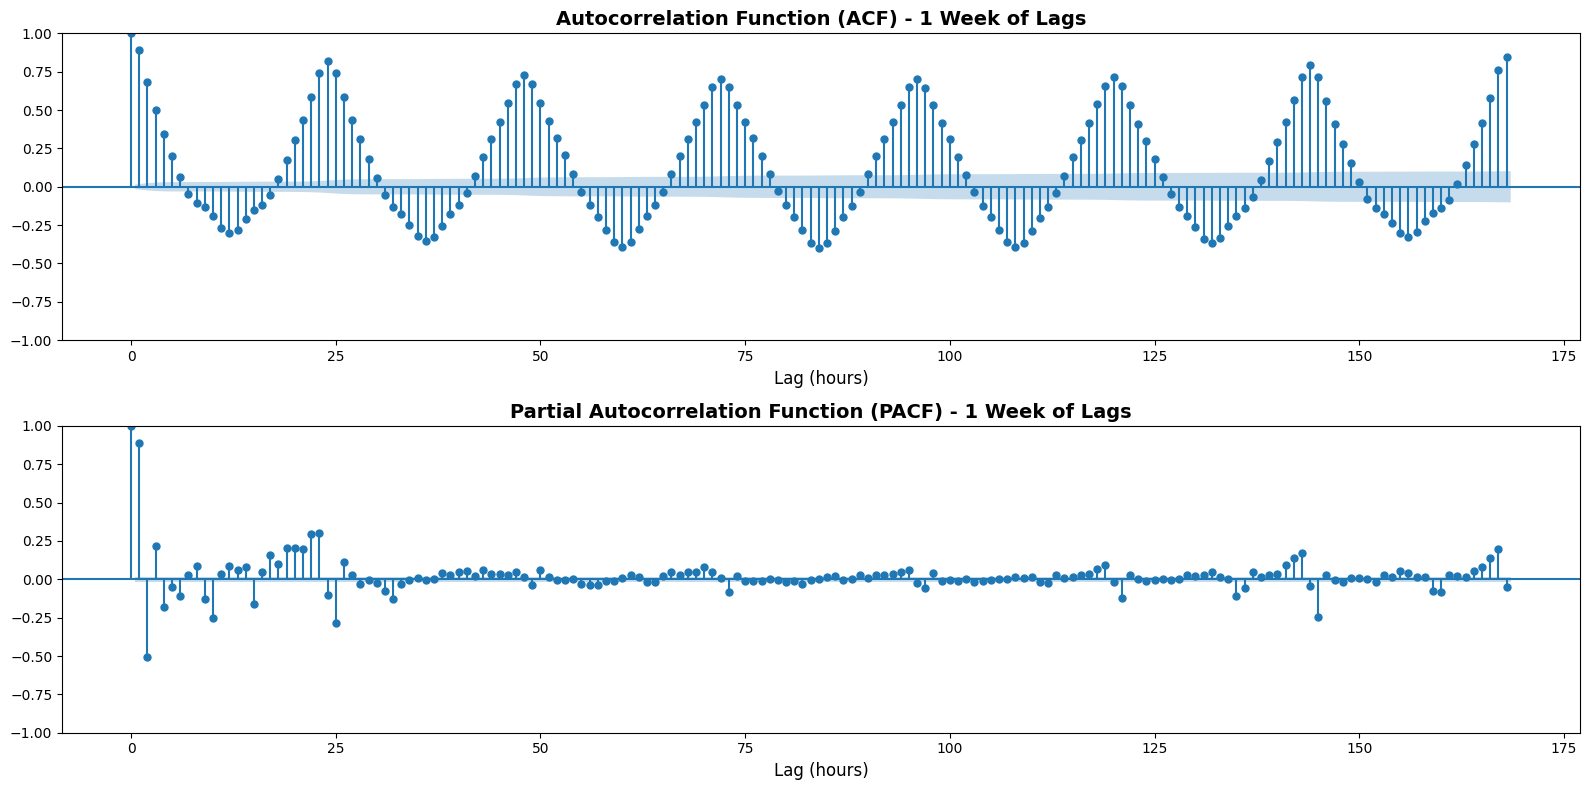

Key patterns to look for:
- Strong correlations at lag 24 (daily pattern)
- Strong correlations at lag 168 (weekly pattern)
- Gradual decay suggests trend/non-stationarity
- Sharp cutoff in PACF suggests AR order


In [33]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# ACF plot
plot_acf(cluster_2_ts_indexed['total_demand'].dropna(), lags=168, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF) - 1 Week of Lags', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lag (hours)', fontsize=12)

# PACF plot
plot_pacf(cluster_2_ts_indexed['total_demand'].dropna(), lags=168, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF) - 1 Week of Lags', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lag (hours)', fontsize=12)

plt.tight_layout()
plt.show()

print("Key patterns to look for:")
print("- Strong correlations at lag 24 (daily pattern)")
print("- Strong correlations at lag 168 (weekly pattern)")
print("- Gradual decay suggests trend/non-stationarity")
print("- Sharp cutoff in PACF suggests AR order")

## 6. Additional Pattern Analysis

Analyzing year-over-year comparison, monthly patterns, and weekday vs weekend differences.

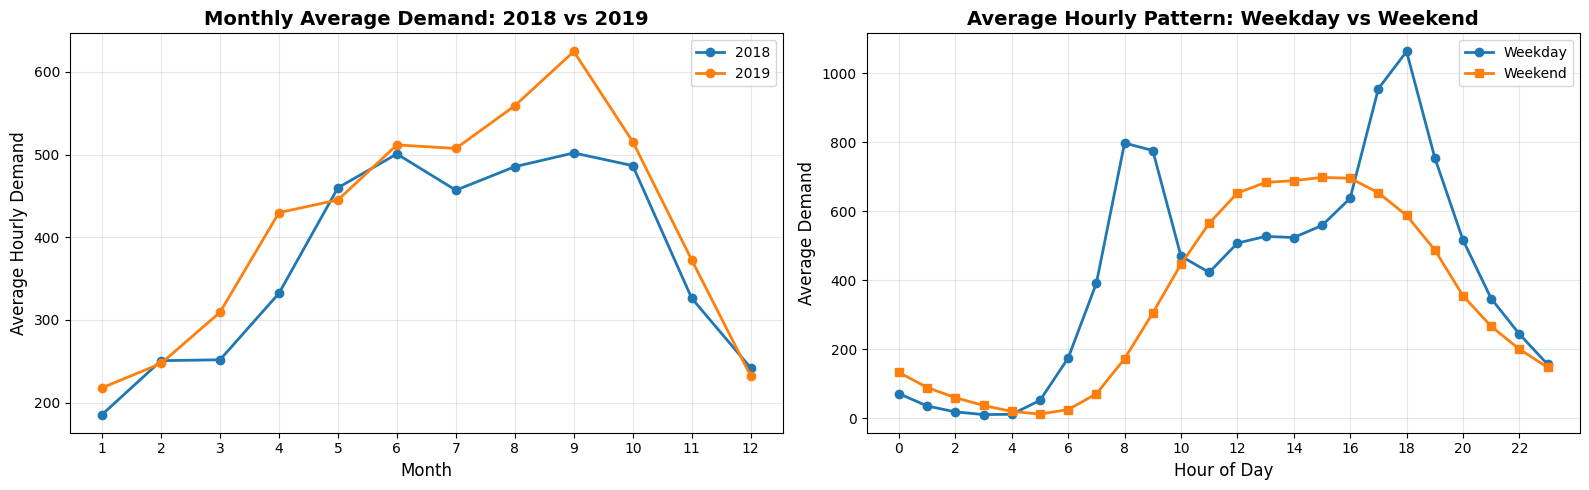

In [34]:
# Extract temporal features for analysis
cluster_2_ts['year'] = cluster_2_ts['hour'].dt.year
cluster_2_ts['month'] = cluster_2_ts['hour'].dt.month
cluster_2_ts['day_of_week'] = cluster_2_ts['hour'].dt.dayofweek
cluster_2_ts['hour_of_day'] = cluster_2_ts['hour'].dt.hour
cluster_2_ts['is_weekend'] = cluster_2_ts['day_of_week'].isin([5, 6]).astype(int)

# 1. Year-over-year comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly averages by year
monthly_avg = cluster_2_ts.groupby(['year', 'month'])['total_demand'].mean().reset_index()
for year in [2018, 2019]:
    year_data = monthly_avg[monthly_avg['year'] == year]
    axes[0].plot(year_data['month'], year_data['total_demand'], marker='o', label=str(year), linewidth=2)

axes[0].set_title('Monthly Average Demand: 2018 vs 2019', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Average Hourly Demand', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1, 13))

# Weekday vs Weekend
weekday_pattern = cluster_2_ts.groupby(['hour_of_day', 'is_weekend'])['total_demand'].mean().reset_index()
weekday_data = weekday_pattern[weekday_pattern['is_weekend'] == 0]
weekend_data = weekday_pattern[weekday_pattern['is_weekend'] == 1]

axes[1].plot(weekday_data['hour_of_day'], weekday_data['total_demand'], marker='o', label='Weekday', linewidth=2)
axes[1].plot(weekend_data['hour_of_day'], weekend_data['total_demand'], marker='s', label='Weekend', linewidth=2)
axes[1].set_title('Average Hourly Pattern: Weekday vs Weekend', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour of Day', fontsize=12)
axes[1].set_ylabel('Average Demand', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

## Summary of Time Series Exploratory Analysis

### Key Findings:

#### 1. **Data Overview**
- **Time Period**: January 2018 - December 2019 (2 years)
- **Total Records**: 17,531 hourly observations for Cluster 2
- **Total Pickups**: 3,421,416 trips
- **Total Dropoffs**: 3,488,980 trips
- **Missing Hours**: Only 35 hours missing (filled with 0s)

#### 2. **Seasonal Decomposition**
- **Trend Component**: Shows clear seasonal variation with peaks in summer months
  - Range: 67.4 to 691.1
  - Winter 2018/2019 shows the lowest demand period
  - Peak demand in summer months (June-September)
- **Seasonal Component**: Strong weekly pattern visible
  - Range: -376.7 to 428.6
  - Daily and weekly cycles are prominent
- **Residual**: Standard deviation of 228.3 indicates moderate unexplained variation

#### 3. **Stationarity Tests**
- **ADF Test**: Series is STATIONARY (p-value < 0.05)
  - Rejects null hypothesis of unit root
- **KPSS Test**: Series is NON-STATIONARY (p-value < 0.05)
  - Suggests non-stationarity around a constant
- **Interpretation**: Contradictory results suggest the series has **trend stationarity** but not strict stationarity
  - Likely needs differencing or detrending for forecasting models

#### 4. **ACF/PACF Analysis**
- **Strong Daily Cycle**: Clear peaks at lag 24 (hourly pattern repeats daily)
- **Weekly Pattern**: Peaks at multiples of 168 hours (7 days)
- **Persistence**: High autocorrelation persists across many lags
- **Implication**: Suggests SARIMA models would be appropriate (Seasonal ARIMA)

#### 5. **Pattern Analysis**

**Year-over-Year Comparison (2018 vs 2019):**
- 2019 shows higher demand than 2018, especially in summer months
- September 2019 peak is significantly higher than 2018
- Winter months (Jan-Mar, Dec) show lower but consistent demand
- Growth trend visible year-over-year

**Weekday vs Weekend Patterns:**
- **Weekday**: Strong bimodal pattern with peaks at:
  - Morning rush: 8-9 AM
  - Evening rush: 5-6 PM
  - Classic commuter pattern
- **Weekend**: More uniform distribution throughout the day
  - Peak around 1-2 PM
  - Higher baseline during midday hours
  - Lower early morning demand

#### 6. **Implications for Forecasting**
1. Need to account for multiple seasonality (daily, weekly, yearly)
2. Consider differencing to achieve stationarity
3. SARIMA or Prophet models would be suitable
4. Should include features for:
   - Hour of day
   - Day of week
   - Month/season
   - Weekday/weekend indicator
5. Weather and special events likely important external factors